In [108]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad

def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 1000**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/251000/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)  / 0.99072616 # 0.99072616为权重修正 角度smooth 补偿
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df


def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_GSF(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_GSF"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    pr_df['GSF_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['GSF_weight']=pr_df['GSF_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['GSF_weight'].sum()} ======")
    return pr_df


def parse_sim_log(txt_filepath):
    import re
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
       
    
    sim_bins = parse_sim_log(log_filepath)
    print(sim_bins)
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260, 480.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 40.5
    R_MIN, R_MAX = 260, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df



def calculate_weights_gsf(df, log_filepath, root_filepath, dlogE=0.01):
    """
    参照 C++ 逻辑：
    在二维网格中，使用 GSF 数据驱动模型计算 EventTrue 并相除得到权重
    """
    
    # ==========================================
    # 1. 预加载 GSF 数据表 (仅执行一次)
    # ==========================================
    gsf_table_path = "/data/home/zzh/data/Dataset_Filted/Simulation/gsf_data_table.txt"
    try:
        # loadtxt 会直接生成一个 29 x 1000 的 numpy 2D 数组
        gsf_data = np.loadtxt(gsf_table_path).T
    except Exception as e:
        raise RuntimeError(f"[ERROR] 无法读取 GSF 数据表 {gsf_table_path}: {e}")

    def gsf_flux_interp(E_TeV, z=0):
        """
        GSF 模型流强插值函数
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        energy_nodes = gsf_data[0] # 第 0 行是能量网格
        
        # 能量超限保护
        if energy_GeV < energy_nodes[0] or energy_GeV > energy_nodes[-1]:
            return 0.0
            
        # 根据 Z 提取对应的流量行 (与 C++ 逻辑严格对齐)
        if z == 0:
            y_nodes = gsf_data[1]
        elif z == 1:
            y_nodes = gsf_data[2]
        elif z == 2:   # CNO
            y_nodes = gsf_data[6] + gsf_data[7] + gsf_data[8]
        elif z == 3:   # MgAlSi
            y_nodes = gsf_data[12] + gsf_data[13] + gsf_data[14]
        elif z == 4:   # Fe
            y_nodes = gsf_data[26]
        else:
            return 0.0
            
        # 核心：使用 numpy 原生的一维线性插值，速度极快
        flux_GeV = np.interp(energy_GeV, energy_nodes, y_nodes)
        
        # 将 GeV^-1 转为 TeV^-1 以适配外层的定积分
        return flux_GeV * 1000.0
       
    # ==========================================
    # 2. 准备常规的日志与 ROOT 解析
    # ==========================================
    sim_bins = parse_sim_log(log_filepath)
    # print(sim_bins)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260.0, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
   
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180.0 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    # ==========================================
    # 3. 2D 网格权重核心计算
    # ==========================================
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用 quad 函数对 GSF 插值谱进行数值积分，默认计算质子(z=0)
            flux_integral_true = quad(gsf_flux_interp, E_low, E_up, args=(0,))[0]
            
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['GSF_weight'] = weights_rate
    return df




from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")



r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=1.6
log10TeV_low=1.8
log10TeV_high=2.3
# rec_theta [0, 70*pi/180], Eage [0.8, 1.6], rho40 [0, 150], pincness [0.6, 1], compactness [0, 1]
rho40_low=0
rho40_high=150
pincness_low=0.6
pincness_high=1.0
compactness_low=0
compactness_high=1.0

def load_allweight_model():
    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3","weightGaisser","weightHorandol","weightGSF"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            del df
            return df_cut
        
    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        del df
        return df_new




    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    proton_df_QF = energy_correction(proton_df_QF)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()

   

    return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF

QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF = load_allweight_model()

def filter_dataset_optimized(npz_file, mc=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    # param_names=["label","gaisser_weight",
    #                 "R_ue", "R_mean", "Eage",
    #                 "recE", "rec_x", "rec_y", "rec_theta", "rec_phi", 
    #                 "trueE", "NuW2", "NpE3", "NuM1", "core_x","core_y","theta"]
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    else:
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        params_df = pd.DataFrame(data["params"], columns=data["param_names"])
        del data
        
    else:
        params_df = pd.read_csv(npz_file)
        
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    rho40 = np.asarray(params_df["rho40"].values, dtype=float)
    pincness = np.asarray(params_df["pincness"].values, dtype=float)
    compactness = np.asarray(params_df["compactness"].values, dtype=float)
    
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 4. 筛选 rho40 (rho40_low < rho40 < rho40_high)
    rho40_mask = (rho40 > rho40_low) & (rho40 < rho40_high)
    n_last = current_mask.sum()
    current_mask = current_mask & rho40_mask
    n_after = current_mask.sum()
    # print(f"    4. Cut rho40: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 5. 筛选 pincness (pincness_low < pincness < pincness_high)
    pincness_mask = (pincness > pincness_low) & (pincness < pincness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & pincness_mask
    n_after = current_mask.sum()
    # print(f"    5. Cut pincness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 6. 筛选 compactness (compactness_low < compactness < compactness_high)
    compactness_mask = (compactness > compactness_low) & (compactness < compactness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & compactness_mask
    n_after = current_mask.sum()
    # print(f"    6. Cut compactness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")


    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
   
    return params_df[current_mask].copy()


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/filted_Monopole_1e10_merged_1000_70_dataset_muon_smooth.npz"
mn_df= filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df)

mn_df_large= filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("\nProton Data Processing...")
pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e10_V04/Proton_combined_filted_1e10_V04_dataset_fastcode.npz"
pr_df= filter_dataset_optimized(pr_npz_file, mc=True)
pr_df = give_bkg_mc_weights_gaisser(pr_df)
pr_df = give_bkg_mc_weights_horandel(pr_df)
pr_df = give_bkg_mc_weights_GSF(pr_df)

pr_df_large = filter_dataset_optimized(pr_npz_file, mc=True, radius_cut=False)
pr_df_large = give_bkg_mc_weights_gaisser(pr_df_large)
pr_df_large = give_bkg_mc_weights_horandel(pr_df_large)
pr_df_large = give_bkg_mc_weights_GSF(pr_df_large)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# EPOS_FLUKA pr
print("\nEPOS_FLUKA Proton Data Processing...")
ef_log_file = "/data/home/zzh/Filt_Event/UpperLimit/1e10/log/Diff_model_EPOS_1e10.sh.out.75810394.0"
pr_ef_npz_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e10_V04/filted_EF_Proton_2.5e13_1.0e15_dataset_fastcode.npz"
pr_ef_df = filter_dataset_optimized(pr_ef_npz_file, mc=True)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# QGSJETII_FLUKA pr
print("\nQGSJETII_FLUKA Proton Data Processing...")
qf_log_file = ef_log_file
pr_qf_npz_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e10_V04/filted_QF_Proton_2.5e13_1.0e15_dataset_fastcode.npz"
pr_qf_df= filter_dataset_optimized(pr_qf_npz_file, mc=True)

exposure_root_file = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
pr_ef_df = calculate_weights(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_horandel(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_gsf(pr_ef_df, ef_log_file, exposure_root_file)

pr_qf_df = calculate_weights(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_horandel(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_gsf(pr_qf_df, qf_log_file, exposure_root_file)

for df in [pr_ef_df, pr_qf_df]:
    df['gaisser_weight'] = df['gaisser_weight'] * proton_df_QF['weightGaisser'].sum() / df['gaisser_weight'].sum()
    df['horandel_weight'] = df['horandel_weight'] * proton_df_QF['weightHorandol'].sum() / df['horandel_weight'].sum()
    df['GSF_weight'] = df['GSF_weight'] * proton_df_QF['weightGSF'].sum() / df['GSF_weight'].sum()

# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data (2024 361days) Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/1e10_V04_2023_ALL_MERGED.npz"
exp_muon_Rue_df = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=True)

exp_muon_Rue_df_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Proton Gaisser={pr_df['gaisser_weight'].sum()}, Horandel={pr_df['horandel_weight'].sum()}, GSF={pr_df['GSF_weight'].sum()}")
print(f"Proton EPOS_FLUKA Gaisser={pr_ef_df['gaisser_weight'].sum()}, Horandel={pr_ef_df['horandel_weight'].sum()}, GSF={pr_ef_df['GSF_weight'].sum()}")
print(f"Proton QGSJETII_FLUKA Gaisser={pr_qf_df['gaisser_weight'].sum()}, Horandel={pr_qf_df['horandel_weight'].sum()}, GSF={pr_qf_df['GSF_weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Proton Gaisser={pr_df_large['gaisser_weight'].sum()}, Horandel={pr_df_large['horandel_weight'].sum()}, GSF={pr_df_large['GSF_weight'].sum()}")
print(f"Experimental Rue2_2 ={exp_muon_Rue_df_large['weight'].sum()}, one year={exp_muon_Rue_df_large['weight'].sum()}")


/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root
     Entries: 14217778
     Total weights Gaisser: 189.58057618423743
     Total weights Horandel: 161.1763523137651
     Entries after cut: 6035234
 cut weight Gaisser sum: 6.171747062512108
 cut weight Horandel sum: 4.973250159755293
Monopole Data Processing...
--------------------------------------------------
--- 原始数据量: 103839 ---
    1. Cut r: 27930 / 103839 (Left Ratio: 26.90%)
    2. Cut theta: 10304 / 27930 (Left Ratio: 36.89%)
    0. Cut log10TeV: 10240 / 10304 (Left Ratio: 99.38%)
    3. Cut Eage: 10231 / 10240 (Left Ratio: 99.91%)
    --- 筛选结果 ---
    原始数据量: 103839
    筛选后数据量: 10231
    总通过比例: 9.85%
--------------------------------------------------
--- 原始数据量: 103839 ---
    1. Cut dr: 85248 / 103839 (Left Ratio: 82.10%)
    2. Cut theta: 85114 / 85248 (Left Ratio: 99.84%)
    0. Cut log10TeV: 82614 / 85114 (Left Ratio: 97.06%)
    3. Cut Eage: 82310 / 82614 (Left Ratio: 99.63%)
    --

In [76]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    # "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    # "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    # "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 300, 450
theta_cut_low, theta_cut_high = np.deg2rad([0, 35])
log10TeV_low=1.3; log10TeV_high=1.8

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]

# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge","NpE1","NpE2", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 


Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=1698410
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=1166415
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=891738
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=736239
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=813815


--- PROTON ---
Fit Range: (-1.7, -1.3)
Slope: 4.9878
Extrapolated Sum (Range (-8, -2.85)): 3.4727e-04 Hz
--- HE ---
Fit Range: (-1.45, -1.25)
Slope: 8.9874
Extrapolated Sum (Range (-8, -2.85)): 3.5654e-08 Hz

====== FINAL RESULT ======
Proton / Helium Ratio (in (-8, -2.85)): 9740.2572


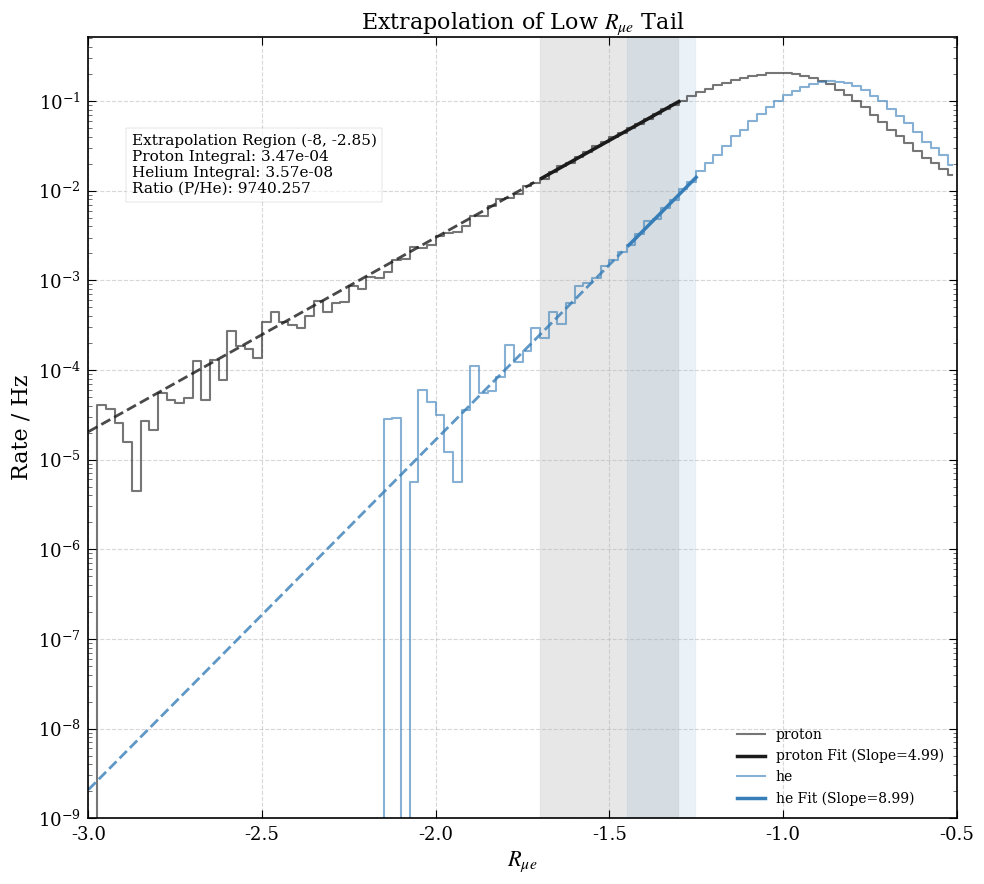

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plot_range = (-3, -0.5)
target_range = (-8, -2.85) # 我们要积分的目标区域
def analyze_and_plot_extrapolation(dfs, bins=100):
    # --- 1. 基础设置与绘图准备 (保持你的风格) ---

    
    fig, ax = plt.subplots()
    
    # 定义参数
    var_name = "R_ue"
    
    
    # 拟合配置: (成分名, 拟合区间, 颜色)
    fit_configs = {
        "proton": {"fit_range": (-1.7, -1.3), "color": "#1B1B1B"},
        "he":     {"fit_range": (-1.45, -1.25), "color": "#377eb8"}
    }
    
    results = {}

    # --- 2. 循环处理 Proton 和 He ---
    for name, config in fit_configs.items():
        if name not in dfs: continue
        
        df = dfs[name]
        # df=df[df['rec_Eage']<1.15]
        vals = pd.to_numeric(df[var_name], errors='coerce').values
        weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
        
        # 2.1 获取直方图数据 (与画图保持一致)
        # 注意：这里 range 必须和画图时完全一致，保证 bin_width 相同
        counts, bin_edges = np.histogram(vals, bins=bins, range=plot_range, weights=weights)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]
        
        # 2.2 筛选拟合区间的数据
        fit_min, fit_max = config['fit_range']
        # 筛选条件：在拟合区间内 且 计数大于0 (log不接受0)
        mask = (bin_centers >= fit_min) & (bin_centers <= fit_max) & (counts > 0)
        
        x_fit = bin_centers[mask]
        y_fit = counts[mask] # 这里是 Rate
        
        if len(x_fit) < 2:
            print(f"Warning: Not enough points to fit {name}")
            continue

        # 2.3 线性拟合: ln(y) = slope * x + intercept
        # 对应物理模型: y = exp(intercept) * exp(slope * x)
        slope, intercept = np.polyfit(x_fit, np.log(y_fit), 1)
        
        # 定义拟合函数 (用于绘图和计算)
        def fitted_func(x):
            return np.exp(slope * x + intercept)
        
        # 2.4 积分计算目标区间 (-3, -2) 的总 Rate
        # 积分公式: Integral(e^(mx+c)) = (1/m) * [e^(mx+c)] | upper_lower
        # 重要：因为直方图是离散的 bin，拟合函数得到的是 "每个bin的计数"。
        # 该区间内的总数 ≈ 积分 / bin_width
        
        t_min, t_max = target_range
        integral_val = (fitted_func(t_max) - fitted_func(t_min)) / slope
        total_rate_extrapolated = integral_val / bin_width
        
        results[name] = {
            "total_rate": total_rate_extrapolated,
            "slope": slope,
            "intercept": intercept,
            "func": fitted_func
        }
        
        print(f"--- {name.upper()} ---")
        print(f"Fit Range: {config['fit_range']}")
        print(f"Slope: {slope:.4f}")
        print(f"Extrapolated Sum (Range {target_range}): {total_rate_extrapolated:.4e} Hz")

        # --- 3. 绘图部分 ---
        # 3.1 画原始阶梯图
        ax.step(bin_centers, counts, where='mid', label=f"{name}", 
                color=config['color'], alpha=0.6, linewidth=1.5)
        
        # 3.2 画拟合线 (延伸到左侧边界)
        x_plot = np.linspace(plot_range[0], fit_max, 100)
        y_plot = fitted_func(x_plot)
        
        # 实线表示拟合区间，虚线表示外推区间
        # 画外推段
        ax.plot(x_plot[x_plot < fit_min], y_plot[x_plot < fit_min], 
                linestyle="--", color=config['color'], alpha=0.8, linewidth=2)
        # 画拟合段 (加粗显示拟合依据)
        ax.plot(x_plot[(x_plot >= fit_min)], y_plot[(x_plot >= fit_min)], 
                linestyle="-", color=config['color'], linewidth=2.5, 
                label=f"{name} Fit (Slope={slope:.2f})")
        
        # 标记拟合区间区域
        ax.axvspan(fit_min, fit_max, color=config['color'], alpha=0.1)

    # --- 4. 计算并展示最终比值 ---
    if "proton" in results and "he" in results:
        ratio = results["proton"]["total_rate"] / results["he"]["total_rate"]
        print(f"\n====== FINAL RESULT ======")
        print(f"Proton / Helium Ratio (in {target_range}): {ratio:.4f}")
        
        # 在图上标注结果
        ax.text(0.05, 0.8, 
                f"Extrapolation Region {target_range}\n" + 
                f"Proton Integral: {results['proton']['total_rate']:.2e}\n" +
                f"Helium Integral: {results['he']['total_rate']:.2e}\n" +
                f"Ratio (P/He): {ratio:.3f}", 
                transform=ax.transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

    # 美化设置
    ax.set_yscale('log')
    ax.set_xlabel(r"$R_{\mu e}$")
    ax.set_ylabel("Rate / Hz")
    ax.set_title(r"Extrapolation of Low $R_{\mu e}$ Tail")
    ax.set_xlim(plot_range)
    # 自动调整ylim以显示外推线
    ax.set_ylim(bottom=1e-9) 
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, which="major", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Rue_Extrapolation_Proton_He.pdf", bbox_inches='tight')
    plt.show()

# --- 执行 ---
# 假设 dfs 已经在内存中 (如你代码块所示)
analyze_and_plot_extrapolation(dfs)


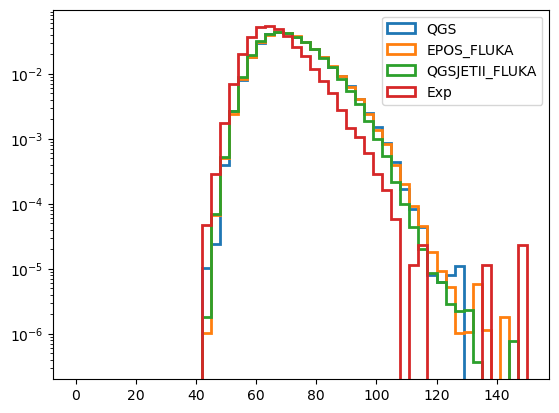

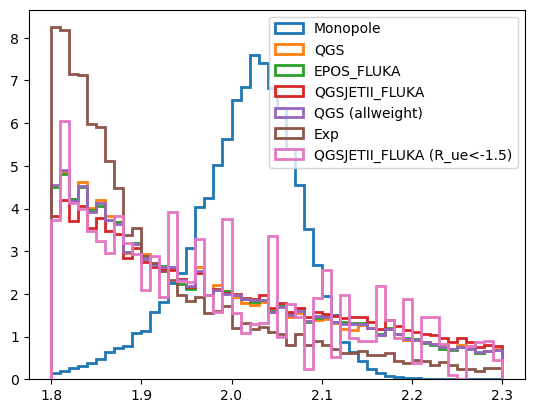

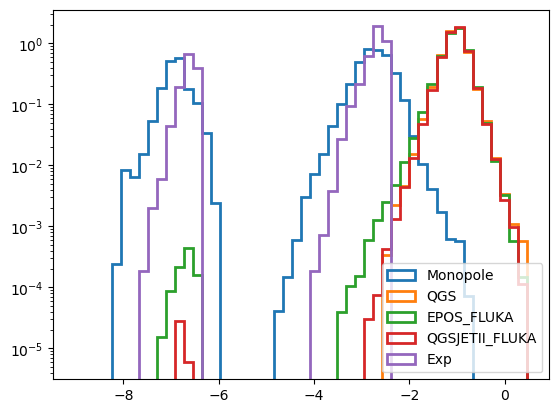

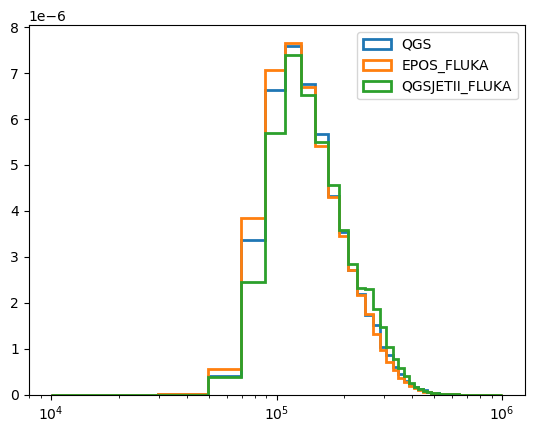

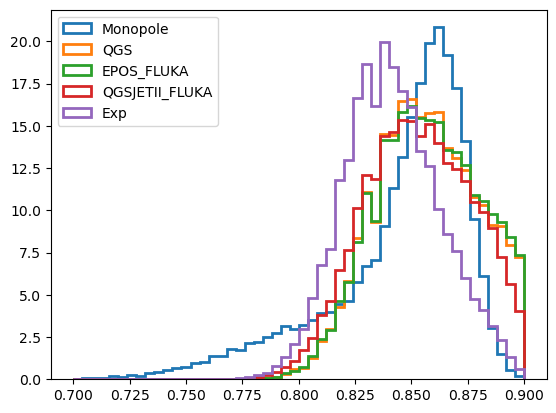

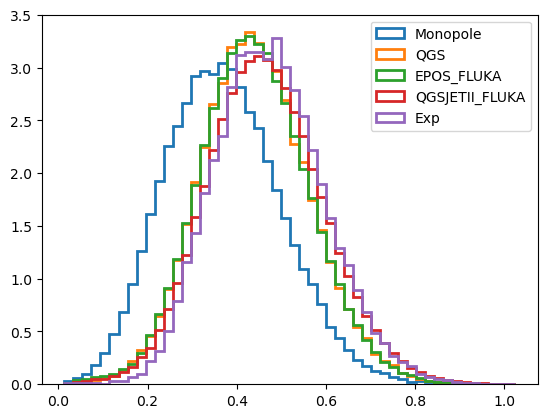

In [6]:

# rho40
plt.hist(pr_df['rho40'], bins=50, range=(0, 150), weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['rho40'], bins=50, range=(0, 150), weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['rho40'], bins=50, range=(0, 150), weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.hist(exp_muon_Rue_df['rho40'], bins=50, range=(0, 150), weights=exp_muon_Rue_df['weight'], histtype='step', lw=2, density=True, label='Exp')
plt.yscale('log')
plt.legend()
plt.show()

pr_qf_df_new= pr_qf_df[pr_qf_df['R_ue'] < -2]
# recE
plt.hist(mn_df_large['recE'], bins=50, range=(1.8, 2.3), weights=mn_df_large['weight'], histtype='step', lw=2, density=True, label='Monopole')
plt.hist(pr_df['recE'], bins=50, range=(1.8, 2.3), weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['recE'], bins=50, range=(1.8, 2.3), weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['recE'], bins=50, range=(1.8, 2.3), weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.hist(proton_df_QF['recE'], bins=50, range=(1.8, 2.3), weights=proton_df_QF['weightGaisser'], histtype='step', lw=2, density=True, label='QGS (allweight)')
plt.hist(exp_muon_Rue_df['recE'], bins=50, range=(1.8, 2.3), weights=exp_muon_Rue_df['weight'], histtype='step', lw=2, density=True, label='Exp')
plt.hist(pr_qf_df_new['recE'], bins=50, range=(1.8, 2.3), weights=pr_qf_df_new['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA (R_ue<-1.5)')
plt.legend()
plt.show()

# R_ue
range_Rue=(-9, pr_df['R_ue'].max())
bins=50
plt.hist(mn_df_large['R_ue'], bins=bins, range=range_Rue, weights=mn_df_large['weight'], histtype='step', lw=2, density=True, label='Monopole')
plt.hist(pr_df['R_ue'], bins=bins, range=range_Rue, weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['R_ue'], bins=bins, range=range_Rue, weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['R_ue'], bins=bins, range=range_Rue, weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.hist(exp_muon_Rue_df['R_ue'], bins=bins, range=range_Rue, weights=exp_muon_Rue_df['weight'], histtype='step', lw=2, density=True, label='Exp')
plt.yscale('log')
plt.legend()
plt.show()

# trueE
range_trueE=(1e4, 1e6)
# plt.hist(mn_df_large['trueE'], bins=bins, range=range_trueE, weights=mn_df_large['weight'], histtype='step', lw=2, density=True, label='Monopole')
plt.hist(pr_df['trueE'], bins=bins, range=range_trueE, weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['trueE'], bins=bins, range=range_trueE, weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['trueE'], bins=bins, range=range_trueE, weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.xscale('log')
plt.legend()
plt.show()

# pincness
range_pincness=(0.7, 0.9)
plt.hist(mn_df_large['pincness'], bins=bins, range=range_pincness, weights=mn_df_large['weight'], histtype='step', lw=2, density=True, label='Monopole')
plt.hist(pr_df['pincness'], bins=bins, range=range_pincness, weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['pincness'], bins=bins, range=range_pincness, weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['pincness'], bins=bins, range=range_pincness, weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.hist(exp_muon_Rue_df['pincness'], bins=bins, range=range_pincness, weights=exp_muon_Rue_df['weight'], histtype='step', lw=2, density=True, label='Exp')

plt.legend()
plt.show()

# compactness
range_compactness=(pr_ef_df['compactness'].min(), pr_ef_df['compactness'].max())
plt.hist(mn_df_large['compactness'], bins=bins, range=range_compactness, weights=mn_df_large['weight'], histtype='step', lw=2, density=True, label='Monopole')  
plt.hist(pr_df['compactness'], bins=bins, range=range_compactness, weights=pr_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGS')
plt.hist(pr_ef_df['compactness'], bins=bins, range=range_compactness, weights=pr_ef_df['gaisser_weight'], histtype='step', lw=2, density=True, label='EPOS_FLUKA')
plt.hist(pr_qf_df['compactness'], bins=bins, range=range_compactness, weights=pr_qf_df['gaisser_weight'], histtype='step', lw=2, density=True, label='QGSJETII_FLUKA')
plt.hist(exp_muon_Rue_df['compactness'], bins=bins, range=range_compactness, weights=exp_muon_Rue_df['weight'], histtype='step', lw=2, density=True, label='Exp')
plt.legend()
plt.show()

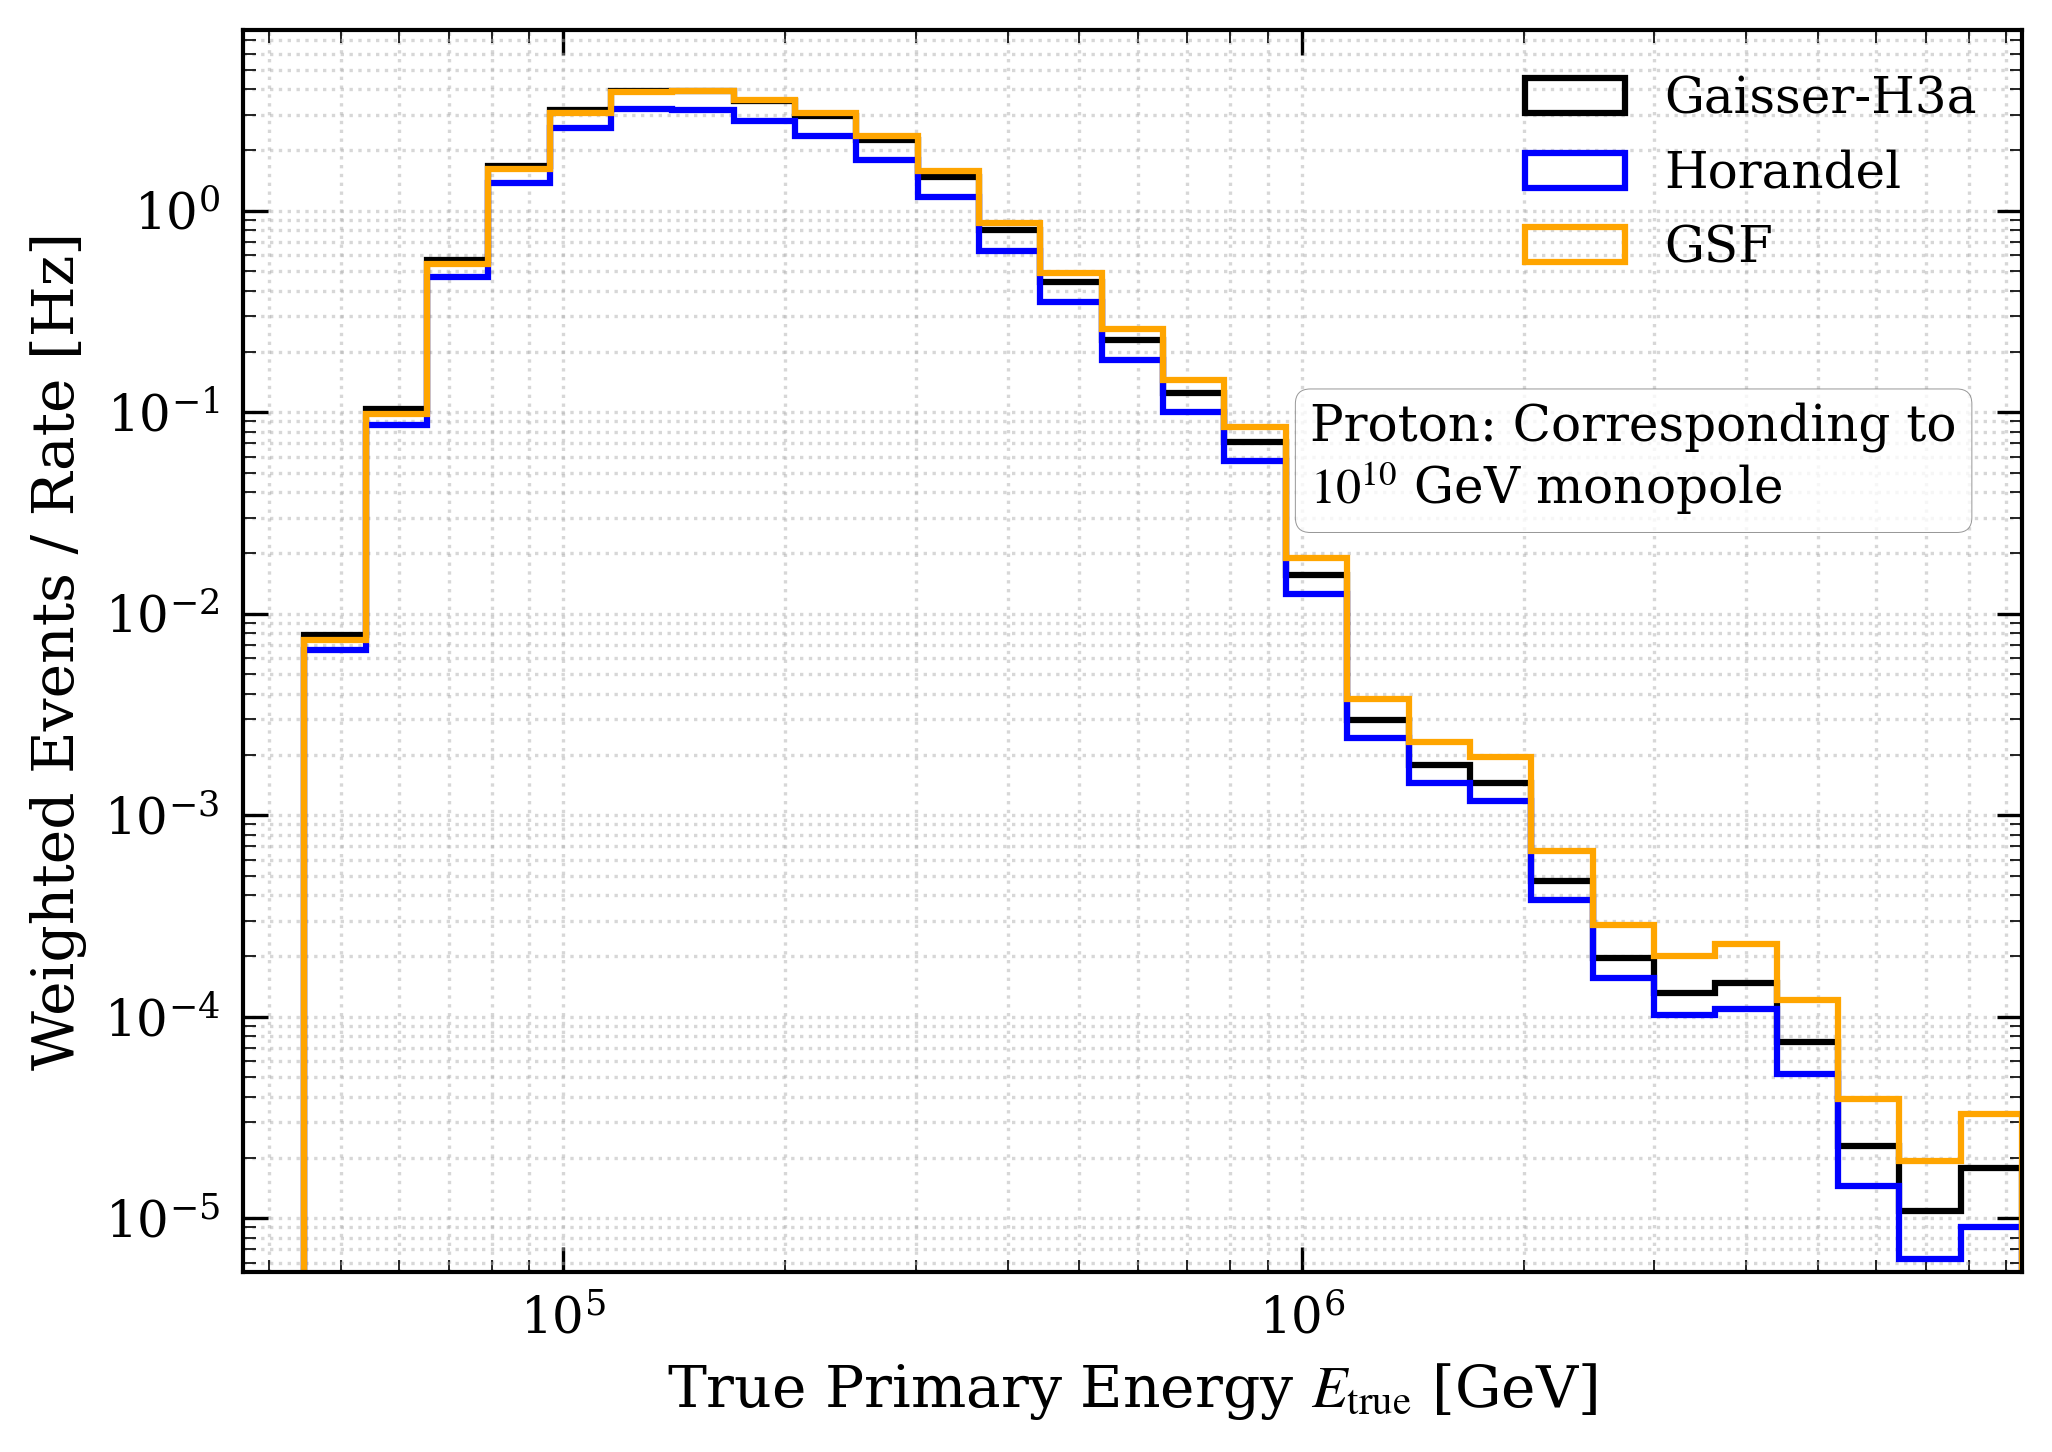

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. 学术风格设置 ---

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "stix"
})

def plot_background_spectrum(df):
    # --- 2. 数据准备 ---
    # 提取真能量和权重
    true_e = df['trueE'].values
    weights = df['gaisser_weight'].values
    weights_horandel = df['horandel_weight'].values
    weights_gsf = df['GSF_weight'].values
    
    # --- 关键步骤：设置对数 Binning ---
    # 宇宙线能谱通常跨越多个数量级，线性 Bin (bins=100) 会导致低能堆积，高能看不见
    # 我们根据数据的最大最小值生成对数均匀的 Bin
    min_e = np.min(true_e[true_e > 0]) # 防止 log(0)
    max_e = np.max(true_e)
    # 生成 60 个对数均匀的 bin
    log_bins = np.logspace(np.log10(min_e), np.log10(max_e), 30)
    
    # --- 3. 绘图 ---
    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    
    # 绘制加权直方图
    # 使用 'step' 风格，颜色使用标准的深灰色或黑色，符合学术习惯
    counts, edges, _ = ax.hist(true_e, bins=log_bins, weights=weights,
                               histtype='step', color='black', lw=1.5, label='Gaisser-H3a')
    ax.hist(true_e, bins=log_bins, weights=weights_horandel,
                histtype='step', color='blue', lw=1.5, label='Horandel')
    ax.hist(true_e, bins=log_bins, weights=weights_gsf,
            histtype='step', color='orange', lw=1.5, label='GSF')
    
    # 填充颜色 (可选，增加美观度)
#     ax.hist(true_e, bins=log_bins, weights=weights_gsf,
#             histtype='step', color='orange', alpha=1, label='GSF')

#     ax.hist(true_e, bins=log_bins, weights=weights,
#             histtype='step', color='gray', alpha=1, label='Gaisser-H3a')
#     ax.hist(true_e, bins=log_bins, weights=weights_horandel,
#             histtype='step', color='blue', alpha=1, label='Horandel')
    
    # --- 4. 坐标轴设置 ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # 标签 (假设单位是 GeV，如果不是请修改)
    ax.set_xlabel(r"True Primary Energy $E_{\mathrm{true}}$ [GeV]", fontsize=14)
    ax.set_ylabel("Weighted Events / Rate [Hz]", fontsize=14)
    
    # 范围微调
    ax.set_xlim(min_e, max_e)
    # y轴下限设为非零的最小值，防止 log 轴显示问题
    if np.max(counts) > 0:
        ax.set_ylim(bottom=np.min(counts[counts > 0]) * 0.5, top=np.max(counts) * 2)

    # 图例与网格
    ax.legend(frameon=False, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    
    # 添加说明文本 (可选)
    ax.text(0.6, 0.70, "Proton: Corresponding to\n$10^{10}$ GeV monopole", 
            transform=ax.transAxes, va='top', fontsize=12,
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_MC_Proton_Spectrum.pdf", bbox_inches='tight')
    plt.show()

# 执行绘图
plot_background_spectrum(pr_df_large)

# (pr_df_large[pr_df_large['trueE']<9e6]['gaisser_weight'].sum())/(pr_df_large['gaisser_weight'].sum())


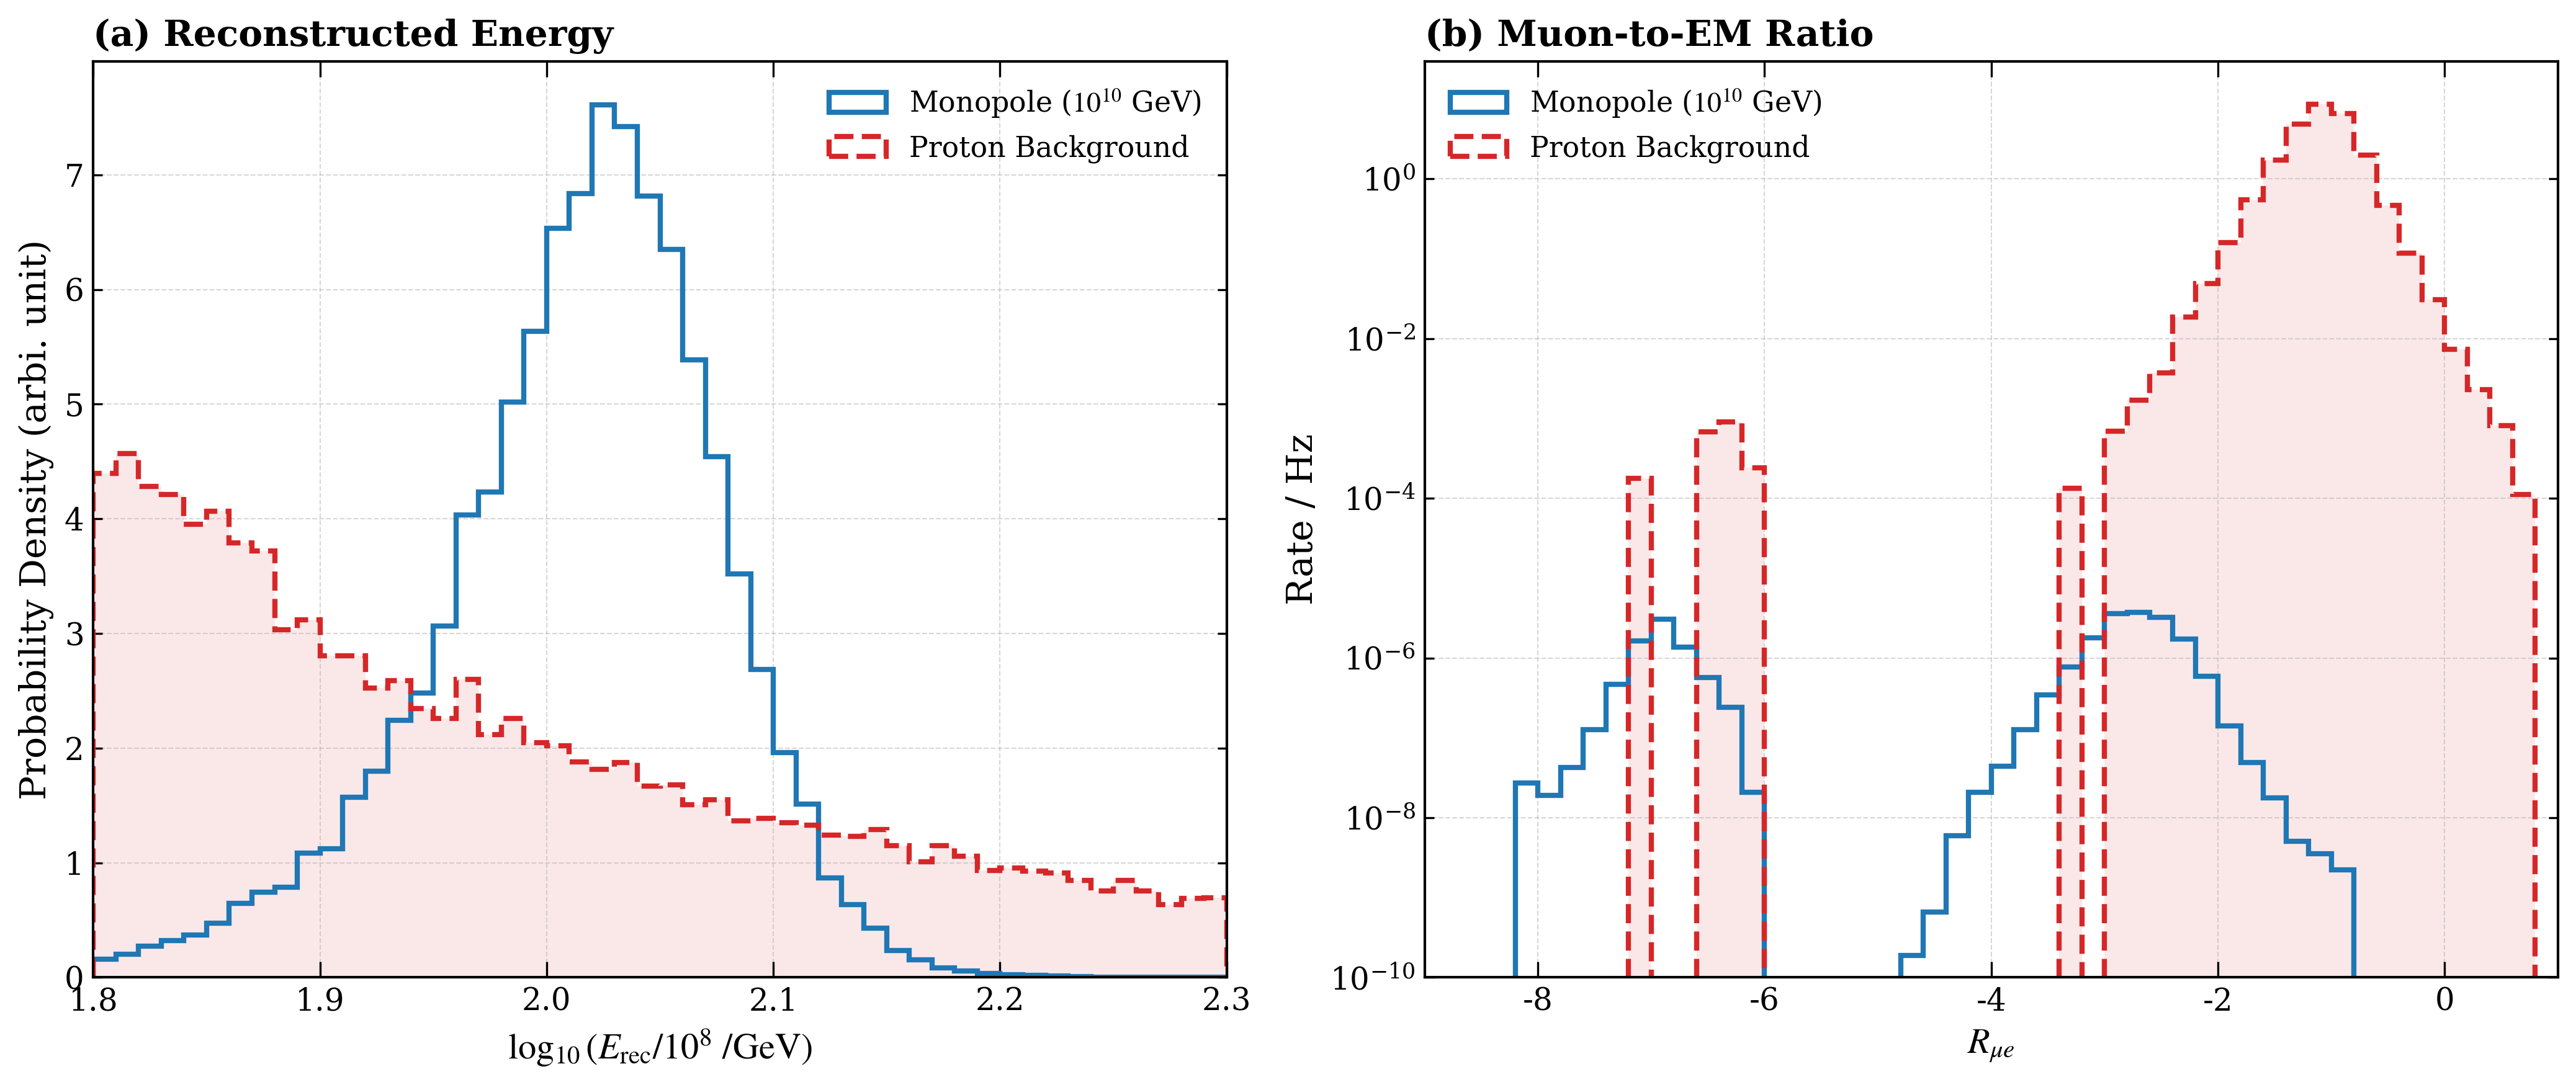

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_formal_recE_Rue(df_list: dict, bins=60, figsize=(14, 6)):
    """
    专门绘制 recE 和 R_ue 的正式对比图，支持权重。
    包含数据类型强制转换和鲁棒的字体设置。
    """
    # 1. 设置学术风格 (兼容 Linux 环境)
    # 如果找不到 Times New Roman，Matplotlib 会回退到 DejaVu Serif，这同样是符合学术标准的衬线体
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.unicode_minus": False,
        "axes.linewidth": 1.0,
        "xtick.major.size": 6,
        "xtick.minor.size": 3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)
    
    # 定义配色方案
    colors = ['#1f77b4', '#d62728', 'black', '#2ca02c'] 
    linestyles = ['-', '--', '-.', ':']

    # --- 绘图核心函数 ---
    def plot_variable(ax, param_name, x_range, log_y=False, x_label="", y_label=""):
        for idx, (label, df) in enumerate(df_list.items()):
            # 检查列是否存在
            if param_name not in df.columns:
                print(f"Warning: '{param_name}' not found in dataset '{label}'")
                continue
                
            # --- [修复核心] 强制转换为数值类型 ---
            # errors='coerce' 会将无法转换的字符串变成 NaN，避免 TypeError
            data_series = pd.to_numeric(df[param_name], errors='coerce')
            data = data_series.values
            
            # --- 权重处理 ---
            if 'gaisser_weight' in df.columns:
                w_series = pd.to_numeric(df['gaisser_weight'], errors='coerce')
                weights = w_series.values
            elif 'weight' in df.columns:
                w_series = pd.to_numeric(df['weight'], errors='coerce')
                weights = w_series.values
            else:
                weights = np.ones_like(data)

            # --- 数据清洗 (去 NaN) ---
            # 现在的 data 和 weights 都是 float 类型，np.isnan 可以正常工作了
            mask = ~np.isnan(data) & ~np.isnan(weights)
            
            # 额外过滤：只保留在 x_range 范围内的数据（可选，但推荐，防止极值破坏密度计算）
            if x_range:
                mask &= (data >= x_range[0]) & (data <= x_range[1])

            clean_data = data[mask]
            clean_weights = weights[mask]

            # 防止空数据报错
            if len(clean_data) == 0:
                print(f"Warning: No valid data for '{label}' in range {x_range}")
                continue

            # 计算加权直方图
            if param_name == "recE":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights, density=True
                )
            elif param_name == "R_ue":
                counts, bin_edges = np.histogram(
                    clean_data, bins=bins, range=x_range, weights=clean_weights,
                )
            
            # 构造阶梯图数据
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            c = colors[idx % len(colors)]
            ls = linestyles[idx % len(linestyles)]
            
            # 绘制 Step 线
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                    label=label, color=c, linewidth=2, linestyle=ls)
            
            # 填充效果
            if 'exp' in label.lower() or 'background' in label.lower():
                 ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='stepfilled',
                    color=c, alpha=0.1)

        # 轴修饰
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel(y_label, fontsize=14)
        
        if x_range:
            ax.set_xlim(x_range)
        
        if log_y:
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-10) 
            
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.legend(frameon=False, fontsize=11, loc='best')

    # --- 2. 绘制 recE (重建能量) ---
    plot_variable(
        ax1, 
        param_name="recE", 
        x_range=(1.8, 2.3), 
        log_y=False, 
        x_label=r"$\log_{10}(E_{\mathrm{rec}}{/10^{8}} ~/ \mathrm{GeV})$",
        y_label="Probability Density (arbi. unit)"
    )
    ax1.set_title("(a) Reconstructed Energy", loc='left', fontweight='bold', fontsize=14)

    # --- 3. 绘制 R_ue (μ/e 比率) ---
    plot_variable(
        ax2, 
        param_name="R_ue", 
        x_range=(-9, 1), 
        log_y=True, 
        x_label=r"$R_{\mu e}$",
        y_label="Rate / Hz"
    )
    ax2.set_title("(b) Muon-to-EM Ratio", loc='left', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_energy_rue_KeyParams_cut.pdf", bbox_inches='tight')
    plt.show()

# 这里的 df_list 需要你传入你的变量
# plot_formal_recE_Rue(df_list, bins=50)

# --- 使用示例 ---
# 假设你的 DataFrame 已经准备好
# exp_full_rue_df = pd.concat([exp_muon_Rue_df_large, exp_no_muon_cut_df[exp_no_muon_cut_df['R_ue'] > -1.9]], ignore_index=True)

df_list = {
    "Monopole ($10^{10}$ GeV)": mn_df_large,
    "Proton Background": pr_df_large,
    # "Experimental Data": exp_full_rue_df,
}

plot_formal_recE_Rue(df_list, bins=50)


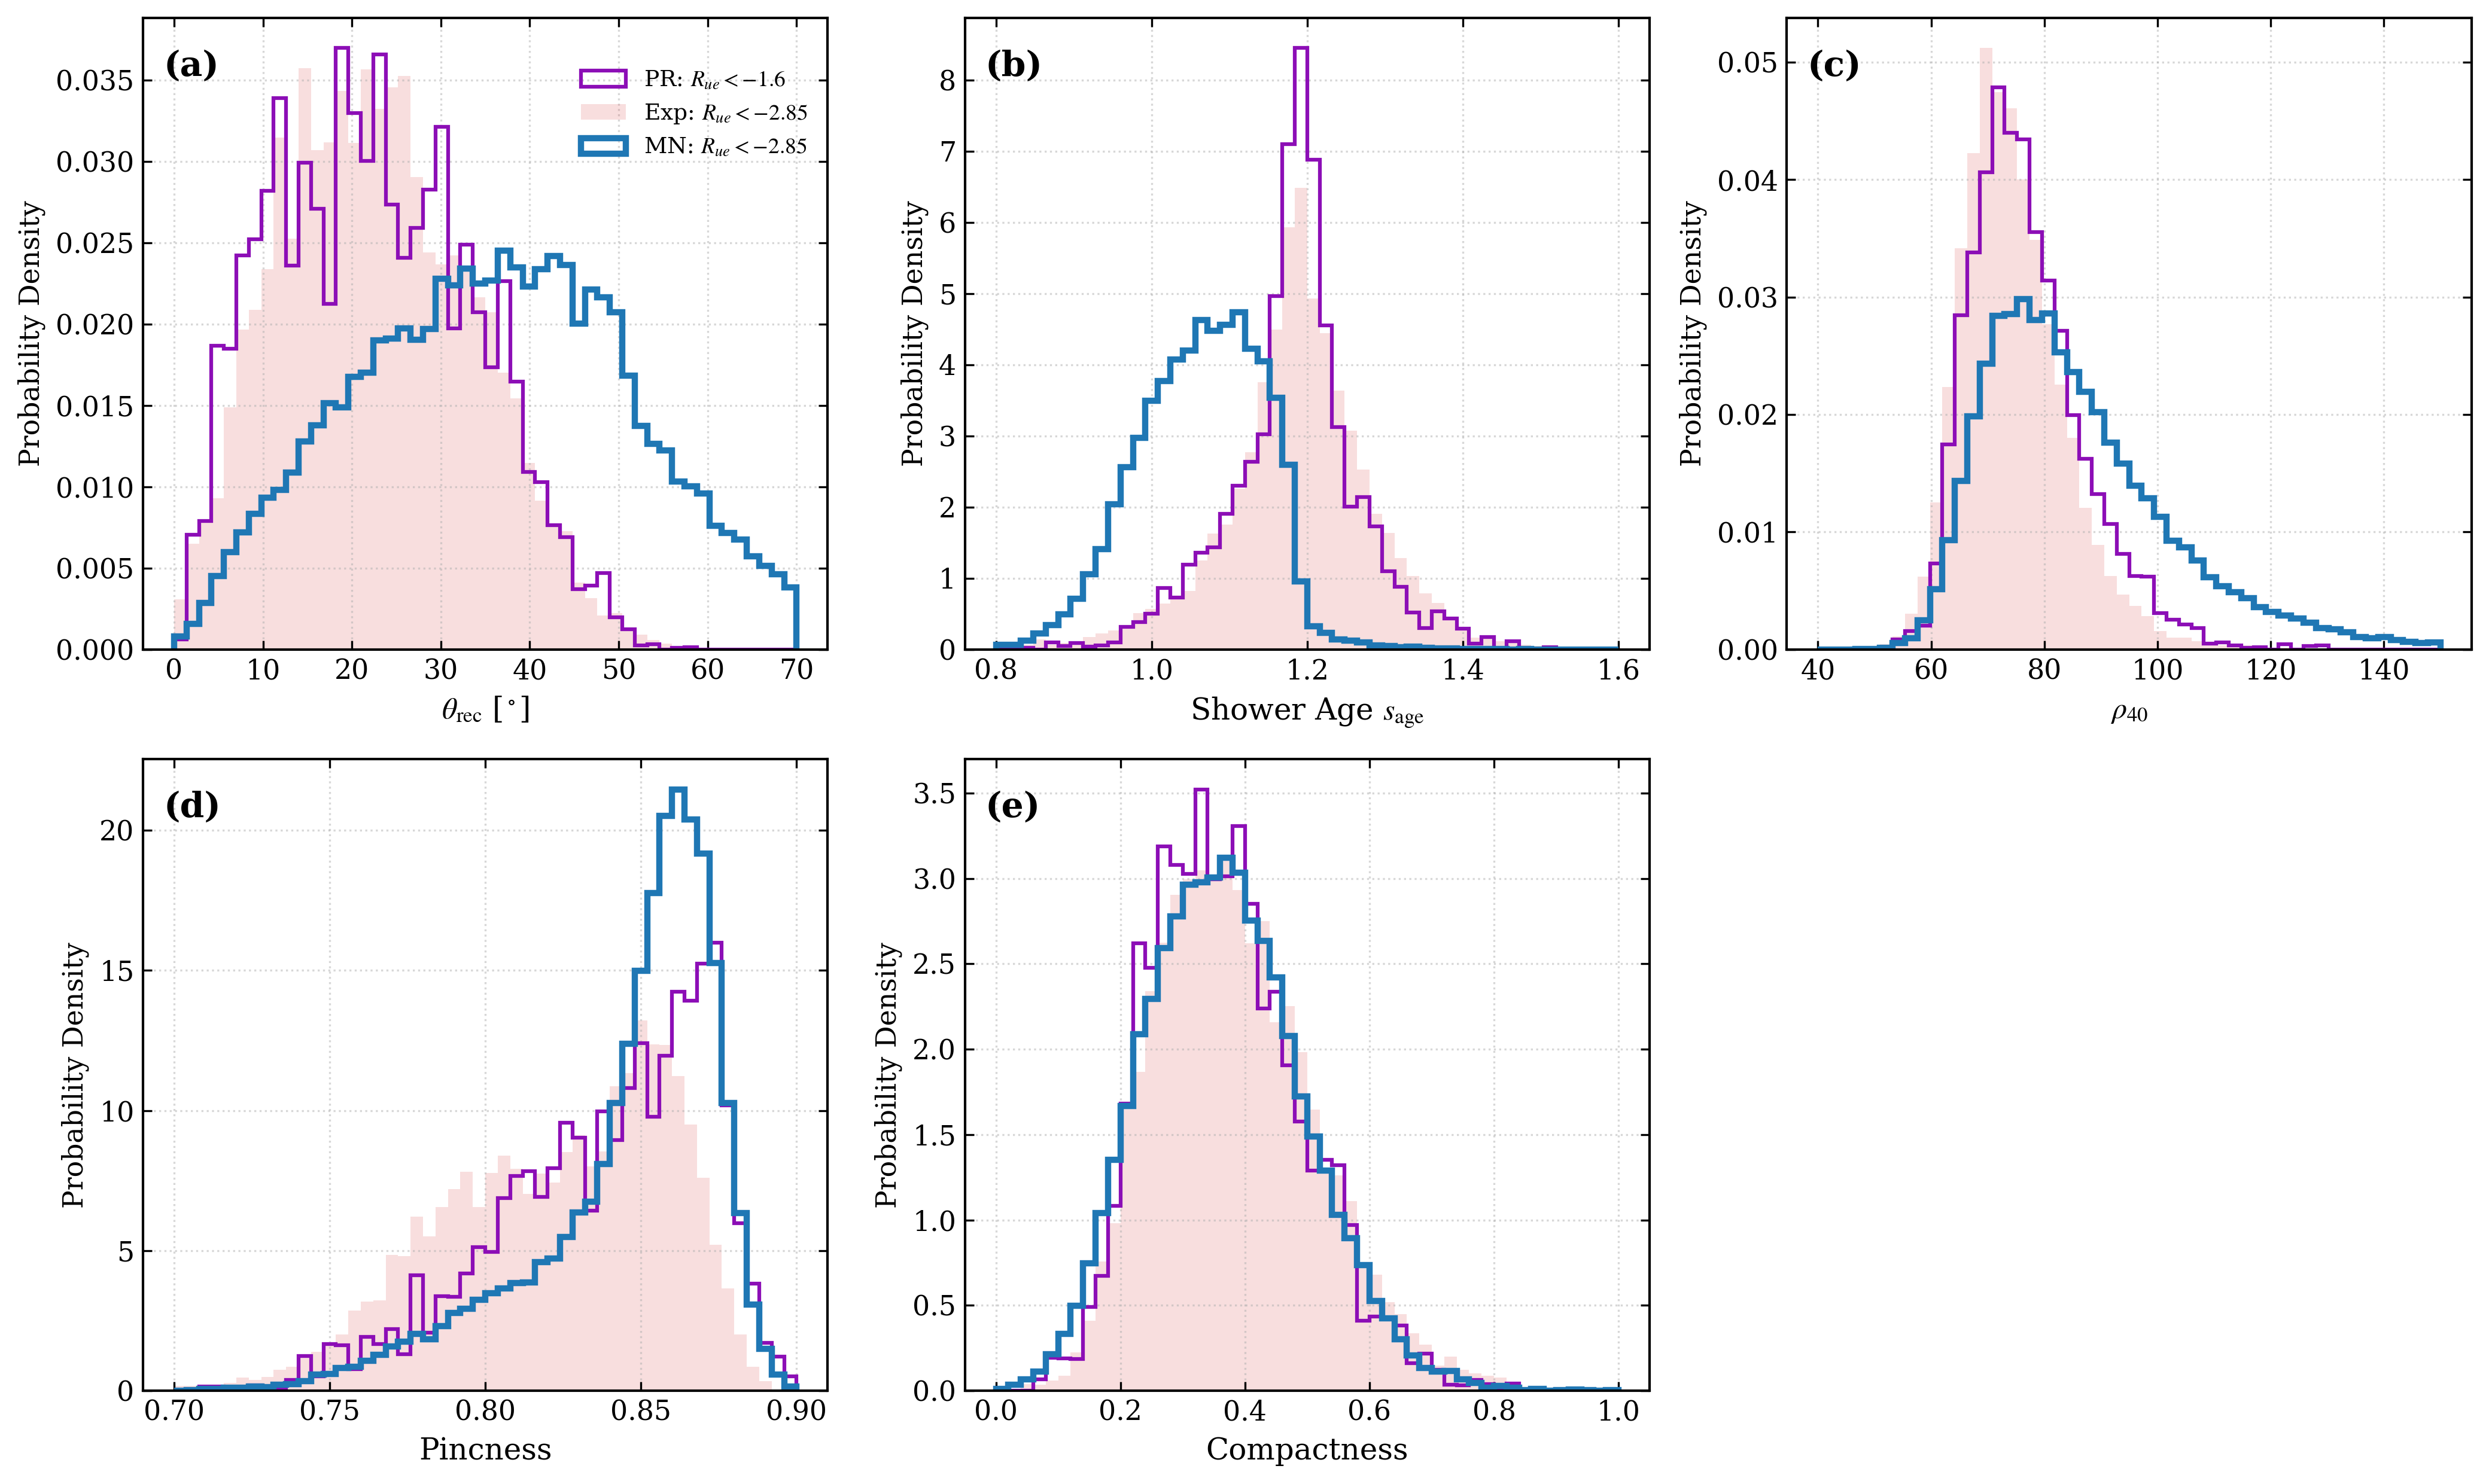

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
def generate_bin_labels(bins):
    """根据 bins 列表自动生成数学表达式标签"""
    labels = []
    for i in range(len(bins) - 1):
        low, high = bins[i], bins[i+1]
        if low == -np.inf and high == np.inf:
            labels.append("All")
        elif low == -np.inf:
            labels.append(f'$R_{{ue}} < {high}$')
        elif high == np.inf:
            labels.append(f'$R_{{ue}} > {low}$')
        else:
            labels.append(f'${low} < R_{{ue}} < {high}$')
    return labels
def plot_rue_slices(df_pr, df_exp, df_mn=None):
    # 1. 设置正式发表的学术风格
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.linewidth": 1.0,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True
    })

    # 物理参数配置
    param_configs = {
        'rec_theta': {'range': (0, 70),    'label': r'$\theta_{\mathrm{rec}}$ [$^\circ$]'},
        'Eage':      {'range': (0.8, 1.6), 'label': r'Shower Age $s_{\mathrm{age}}$'},
        'rho40':     {'range': (40, 150),  'label': r'$\rho_{40}$'},
        'pincness':  {'range': (0.7, 0.9), 'label': 'Pincness'},
        'compactness':{'range': (0.0, 1), 'label': 'Compactness'},
    }

    # 2. 预处理数据 (包含 recE 筛选)
    def preprocess_df(df):
        if df is None: return None
        # 确保数据为数值型
        df['recE'] = pd.to_numeric(df['recE'], errors='coerce')
        mask_e = (df['recE'] > 1.96) & (df['recE'] < 2.1)
        # print(len(df), "->", mask_e.sum(), "after recE cut (2.7 < recE < 3.3)")
        return df[mask_e].copy()

    # 核心配置 
    raw_configs = {
        'PR':  {'df': preprocess_df(df_pr), 'bins': [-np.inf, -1.6], 
                'w': 'gaisser_weight', 'style': {'histtype': 'step', 'lw': 1.5}},
        'Exp': {'df': preprocess_df(df_exp), 'bins': [-np.inf, -2.85], 
                'w': 'weight', 'style': {'histtype': 'stepfilled', 'alpha': 0.15}},
        'MN':  {'df': preprocess_df(df_mn), 'bins': [-np.inf, -2.85], 
                'w': 'weight', 'style': {'histtype': 'step', 'lw': 2.5}}
    }

    data_sources = {k: v for k, v in raw_configs.items() if v['df'] is not None}
    for k in data_sources:
        data_sources[k]['labels'] = generate_bin_labels(data_sources[k]['bins'])

    # 3. 布局
    n_params = len(param_configs)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.2 * n_rows), dpi=300)
    axes_flat = axes.flatten()

    # 4. 绘图循环
    for i, (p_name, p_cfg) in enumerate(param_configs.items()):
        ax = axes_flat[i]
        
        for src_name, s in data_sources.items():
            df_slice = s['df']
            # 使用 pd.cut 确保筛选逻辑正确
            categories = pd.cut(df_slice['R_ue'], bins=s['bins'], labels=False)
            
            for j, bin_label in enumerate(s['labels']):
                mask = (categories == j)
                if not np.any(mask): continue
                
                # 配色逻辑
                if src_name == 'MN': 
                    c = '#1f77b4'  # 信号蓝
                elif src_name == 'Exp': 
                    c = '#d62728'  # 实验红（根据您代码中Exp的颜色）
                else: 
                    pr_colors = ["#8C0EB6", '#FF7F0E'] # 背景颜色
                    c = pr_colors[j % len(pr_colors)]

                # 计算绘图值
                plot_vals = pd.to_numeric(df_slice.loc[mask, p_name], errors='coerce').values
                # print(f"{src_name} - {bin_label}: Plotting {len(plot_vals)} entries for {p_name}")
                if p_name == 'rec_theta' and np.nanmax(plot_vals) < 7:
                    plot_vals = plot_vals * (180/np.pi)

                ax.hist(plot_vals, bins=50, density=True, range=p_cfg['range'],
                        weights=df_slice.loc[mask, s['w']].values, color=c,
                        label=f"{src_name}: {bin_label}", **s['style'])
        
        # --- 核心修改：添加 (a), (b), (c)... 标签 ---
        # transform=ax.transAxes 表示使用子图相对坐标 (0,0)左下, (1,1)右上
        ax.text(0.03, 0.95, f'({string.ascii_lowercase[i]})', 
                transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

        if i == 0: 
            ax.legend(fontsize=9, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.95))
        
        # 子图美化
        ax.set_xlabel(p_cfg['label'], fontsize=12)
        ax.set_ylabel("Probability Density", fontsize=11)
        ax.grid(True, ls=':', alpha=0.5)

    # 5. 隐藏多余子图
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Variables_For_Classification_compare.pdf", 
                bbox_inches='tight', dpi=300)
    plt.show()

# 执行绘图
plot_rue_slices(pr_df_large, exp_muon_Rue_df_large, mn_df_large)


template validation

In [14]:
# recE: 1.8-2.3 R_ue<-2.5
def filter_dataset_temp(file, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    log10TeV_low=1.8
    log10TeV_high=2.3
    

    data = np.load(file, allow_pickle=True)
    params_df = pd.DataFrame(data["params"], columns=data["param_names"])
    del data

        
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
   
    return params_df[current_mask].copy()



exp_temp_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/temp_DataDriven_202301_1wfiles_1e10_V04_dataset_fastcode.npz"
exp_temp_df = filter_dataset_temp(exp_temp_file, radius_cut=False)
exp_temp_df['weight_norm'] = 1 * (74176/10000) * 12 # I scale to one year
SR_Rue_cut=-2.85
exp_temp_df_CR = exp_temp_df[exp_temp_df['R_ue'] > SR_Rue_cut]
exp_temp_df_SR = exp_temp_df[exp_temp_df['R_ue'] < SR_Rue_cut]
print(exp_temp_df.columns)
# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE1',
#        'NpE2', 'NpE3', 'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE',
#        'core_x', 'core_y', 'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd',
#        'tlong', 'tlat', 'log_NuW3'],
#       dtype='object')

# Description:
# features for MLP : rec_theta, Eage, rho40, pincness, compactness
# this dataset' Rue range is about less than -1.5, the Signal Region cut of R_ue is less than -2.85
# what i want to do is to use this dataset to validate an assumption of with the decreasing of R_ue cut threshold
# the distribution of these features will be more and more stable,
# so I can use the distribution of these features in this dataset to represent the distribution of these features in the signal region (R_ue < -2.85) for the background,
# and then use that to train the MLP to distinguish signal and background in the signal region.
# and for systematic uncertainty estimation, I use the variation of R_ue cut to represent, the little difference of features distribution will be use as intput of MLP to 
# quantify the histogram variation.
# what you do is :
# 1. plot the distribution of these features with different R_ue cut threshold, like -1.5, -2.0, -2.5, -2.85, and see how the distribution change with the decreasing of R_ue cut threshold.(In a big figure with reasonable layout)
# 2. in R_ue distribution in log scale, use linear fit to get the total yield in SR (sideband fit), get the value and uncertainty of the extrapolation
# 3. find a reasonable R_ue cut as my template in SR (you first do 1 and 2, this remain to the end, after we confirm the result of 1 and 2)

--------------------------------------------------
--- 原始数据量: 345131 ---
    1. Cut dr: 345131 / 345131 (Left Ratio: 100.00%)
    2. Cut theta: 345131 / 345131 (Left Ratio: 100.00%)
    0. Cut log10TeV: 345131 / 345131 (Left Ratio: 100.00%)
    3. Cut Eage: 344895 / 345131 (Left Ratio: 99.93%)
    --- 筛选结果 ---
    原始数据量: 345131
    筛选后数据量: 344895
    总通过比例: 99.93%
Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
       'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE1',
       'NpE2', 'NpE3', 'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE',
       'core_x', 'core_y', 'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd',
       'tlong', 'tlat', 'log_NuW3', 'weight_norm'],
      dtype='object')


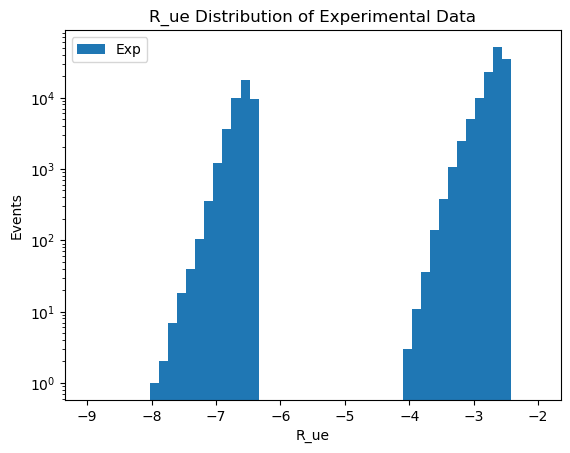

In [87]:
plt.hist(exp_muon_Rue_df_large['R_ue'], bins=50, range=(-9, -2),histtype='stepfilled', lw=2, label='Exp')
plt.yscale('log')
plt.xlabel('R_ue')
plt.ylabel('Events')
plt.title('R_ue Distribution of Experimental Data')
plt.legend()
plt.show()


/tmp/ipykernel_1064185/788002349.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


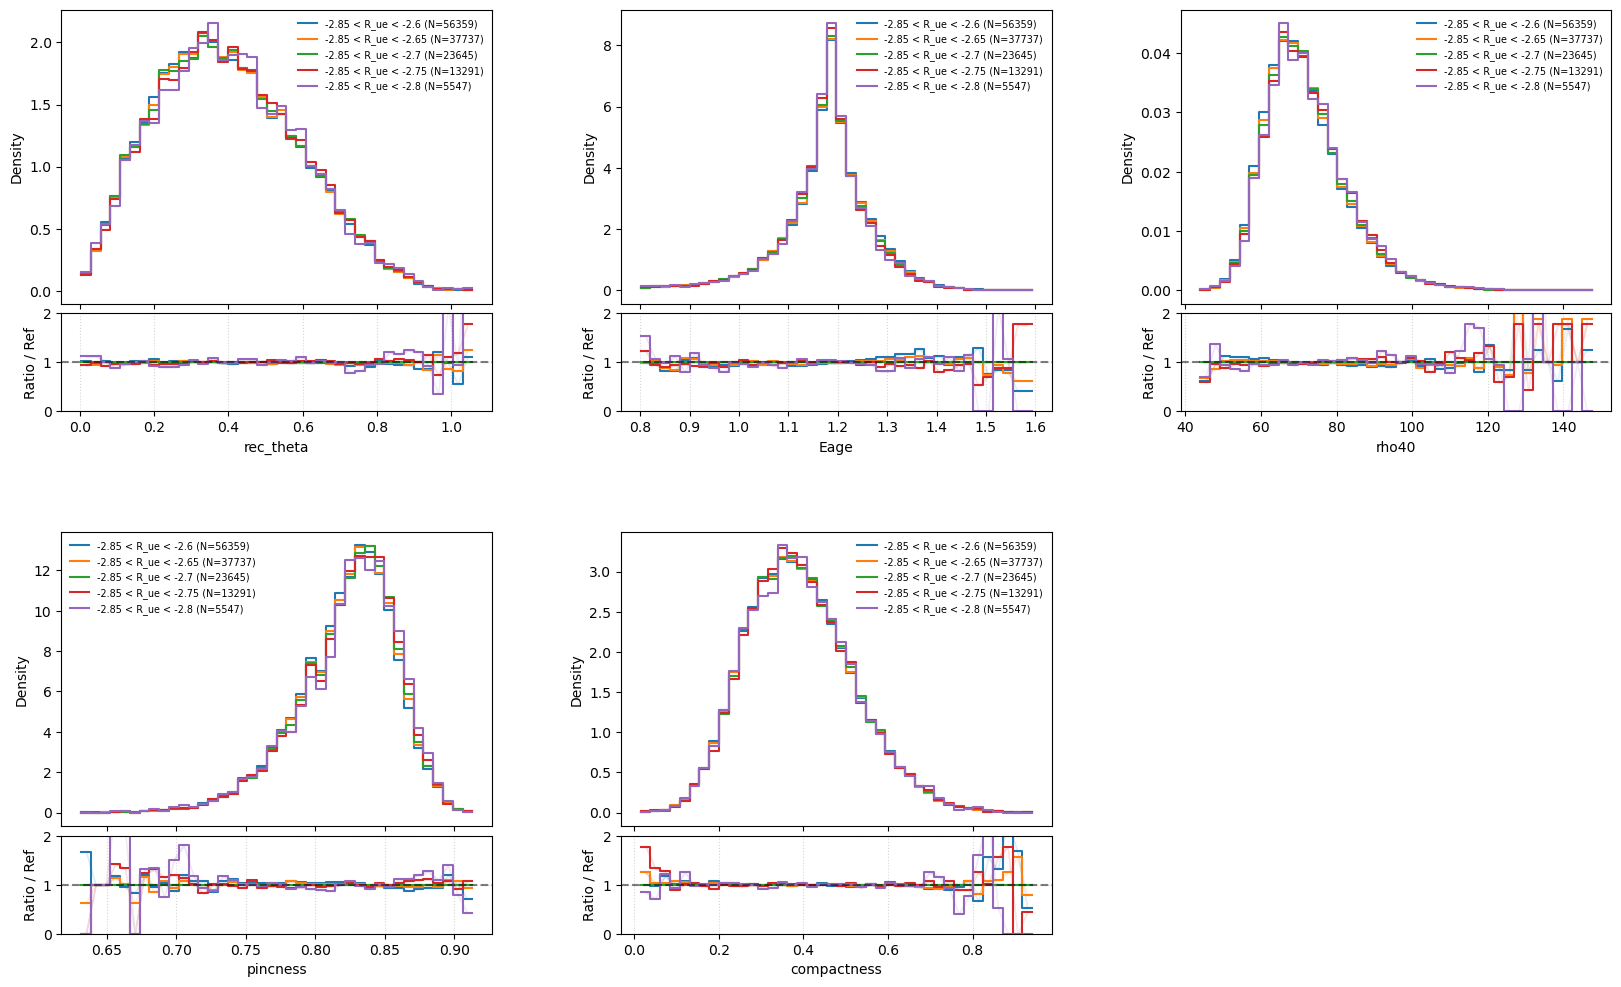

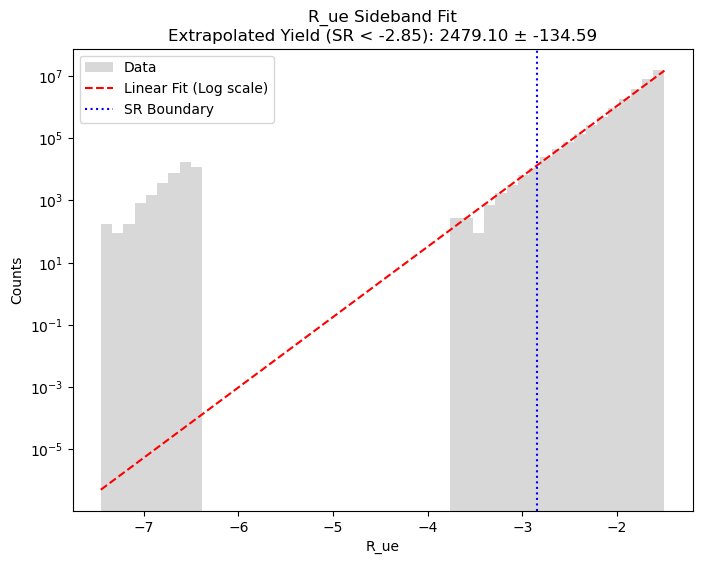

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.gridspec as gridspec

def plot_stability_with_ratio(df, sideband_thresholds=[-2.6, -2.65, -2.7, -2.75, -2.80], 
                              SR_limit=-2.85, reference_thresh=-2.7):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness']
    
    # 创建画布
    fig = plt.figure(figsize=(20, 12))
    # 定义 2行 3列 的大网格
    outer_grid = gridspec.GridSpec(2, 3, fig, wspace=0.3, hspace=0.3)
    
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    # 参考区间的 Mask (Nominal)
    ref_mask = (df['R_ue'] <= reference_thresh) & (df['R_ue'] > SR_limit)
    
    for i, col in enumerate(features):
        # 在每个大网格里切分出上下两个子图，高度比为 3:1
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], 
                                                      height_ratios=[3, 1], hspace=0.05)
        
        ax_main = plt.Subplot(fig, inner_grid[0])
        ax_ratio = plt.Subplot(fig, inner_grid[1], sharex=ax_main)
        fig.add_subplot(ax_main)
        fig.add_subplot(ax_ratio)
        
        # --- 准备基准数据 (Reference) ---
        data_ref = df[ref_mask][col].dropna()
        # 统一使用 40 个 bin
        counts_ref, bin_edges = np.histogram(data_ref, bins=40, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- 循环绘制不同 Threshold ---
        for j, thresh in enumerate(sideband_thresholds):
            mask_sub = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            data_sub = df[mask_sub][col].dropna()
            
            if len(data_sub) < 10: continue
            
            # 计算直方图
            counts_sub, _ = np.histogram(data_sub, bins=bin_edges, density=True)
            
            # 1. 上方主图: Density
            ax_main.step(bin_edges, np.append(counts_sub, counts_sub[-1]), where='post', 
                         color=colors[j], lw=1.5, label=f"{SR_limit} < R_ue < {thresh} (N={len(data_sub)})")
            
            # 2. 下方副图: Ratio
            # 处理除零
            ratio = np.divide(counts_sub, counts_ref, out=np.ones_like(counts_sub), where=counts_ref!=0)
            ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color=colors[j], lw=1.5)
            
            # 统计误差带 (Poisson)
            rel_err = np.sqrt(1/len(data_sub) + 1/len(data_ref)) if (len(data_sub)>0 and len(data_ref)>0) else 0
            ax_ratio.fill_between(bin_centers, ratio*(1-rel_err), ratio*(1+rel_err), color=colors[j], alpha=0.1)

        # --- 图表装饰 ---
        # 主图
        # ax_main.set_title(f"Stability & Ratio: {col}", fontsize=14, fontweight='bold')
        ax_main.set_ylabel("Density")
        ax_main.legend(fontsize='x-small', loc='best', frameon=False)
        plt.setp(ax_main.get_xticklabels(), visible=False) # 隐藏主图 X 轴刻度
        
        # 副图
        ax_ratio.axhline(1.0, color='black', linestyle='--', alpha=0.5)
        ax_ratio.set_ylim(0., 2) # Ratio 范围设定
        ax_ratio.set_ylabel("Ratio / Ref", fontsize=10)
        ax_ratio.set_xlabel(col)
        ax_ratio.grid(True, which='both', linestyle=':', alpha=0.5)

    # 移除最后一个空白子图
    # fig.delaxes(fig.axes[-1])
    # fig.delaxes(fig.axes[-1]) 
    
    plt.tight_layout()
    plt.show()

# 调用
plot_stability_with_ratio(exp_muon_Rue_df_large)

def sideband_extrapolation(df, sr_threshold=-2.85, fit_range=(-2.8, -2.0)):
    # 1. Prepare Histogram Data
    counts, bin_edges = np.histogram(df['R_ue'], bins=50, range=(df['R_ue'].min(), -1.5), weights=df['weight_norm'])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Filter for fit range (sideband)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log10(counts[fit_mask])
    y_err = 1 / (np.sqrt(counts[fit_mask]) * np.log(10)) # Log error propagation
    
    # 2. Linear Fit: log10(y) = a*x + b
    def linear_func(x, a, b):
        return a * x + b
    
    popt, pcov = curve_fit(linear_func, x_fit, y_fit, sigma=y_err)
    a, b = popt
    perr = np.sqrt(np.diag(pcov))
    
    # 3. Extrapolation & Integration
    # The yield Y = 10^(ax+b). Integral from -inf to sr_threshold:
    # Integral = [ 10^(ax+b) / (a * ln(10)) ]
    def get_yield(cutoff, a_val, b_val):
        return (10**(a_val * cutoff + b_val)) / (a_val * np.log(10))
    
    extrapolated_yield = get_yield(sr_threshold, a, b)
    
    # 4. Uncertainty (Simplified via Jacobian or Delta Method)
    # For speed, we estimate by varying parameters within 1-sigma
    yield_up = get_yield(sr_threshold, a + perr[0], b + perr[1])
    yield_down = get_yield(sr_threshold, a - perr[0], b - perr[1])
    uncertainty = (yield_up - yield_down) / 2

    # 5. Plotting
    plt.figure(figsize=(8, 6))
    plt.hist(df['R_ue'], bins=50, range=(df['R_ue'].min(), -1.5), weights=df['weight_norm'],label='Data', color='gray', alpha=0.3)
    
    x_plot = np.linspace(df['R_ue'].min(), -1.5, 100)
    plt.plot(x_plot, 10**linear_func(x_plot, *popt), 'r--', label='Linear Fit (Log scale)')
    plt.axvline(sr_threshold, color='blue', linestyle=':', label='SR Boundary')
    
    plt.yscale('log')
    plt.title(f"R_ue Sideband Fit\nExtrapolated Yield (SR < {sr_threshold}): {extrapolated_yield:.2f} ± {uncertainty:.2f}")
    plt.xlabel("R_ue")
    plt.ylabel("Counts")
    plt.legend()
    plt.show()
    
    return extrapolated_yield, uncertainty


# Run extrapolation
yield_sr, err_sr = sideband_extrapolation(exp_temp_df)

In [ ]:
sideband_thresholds=[-2.6, -2.65, -2.7, -2.75, -2.80]
SR_limit=-2.85
reference_thresh=-2.7
bkg_yields = 2479.10+8649.61
bkg_nominal = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue'] < reference_thresh) & (exp_muon_Rue_df_large['R_ue'] > SR_limit)].copy()
bkg_nominal['weight']  = bkg_nominal['weight'] * (bkg_yields / bkg_nominal['weight'].sum())
bkg_variations = []
for thresh in sideband_thresholds:
    bkg_var = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue'] < thresh) & (exp_muon_Rue_df_large['R_ue'] > SR_limit)].copy()
    bkg_var['weight'] = bkg_var['weight'] * (bkg_yields / bkg_var['weight'].sum())
    bkg_variations.append(bkg_var)

sig_nominal = 

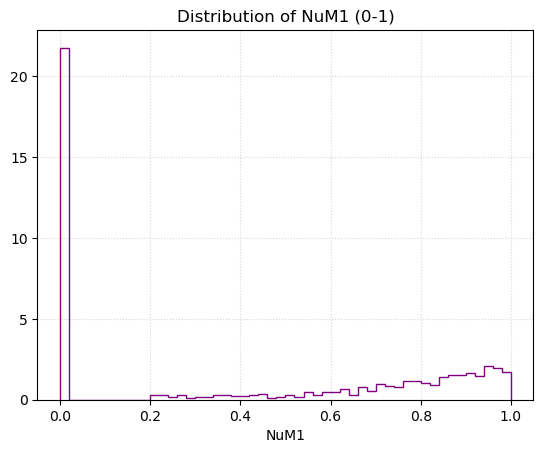

In [30]:
NuM1 = exp_temp_df['NuM1'].values
#得到值在0-1范围内的NuM1
NuM1_0_1 = NuM1[(NuM1 >= 0) & (NuM1 <= 1)]
plt.hist(NuM1_0_1, bins=50, range=(0, 1), density=True, histtype='step', color='purple')
plt.xlabel('NuM1')
plt.title('Distribution of NuM1 (0-1)')
plt.grid(True, ls=':', alpha=0.5)
plt.show()

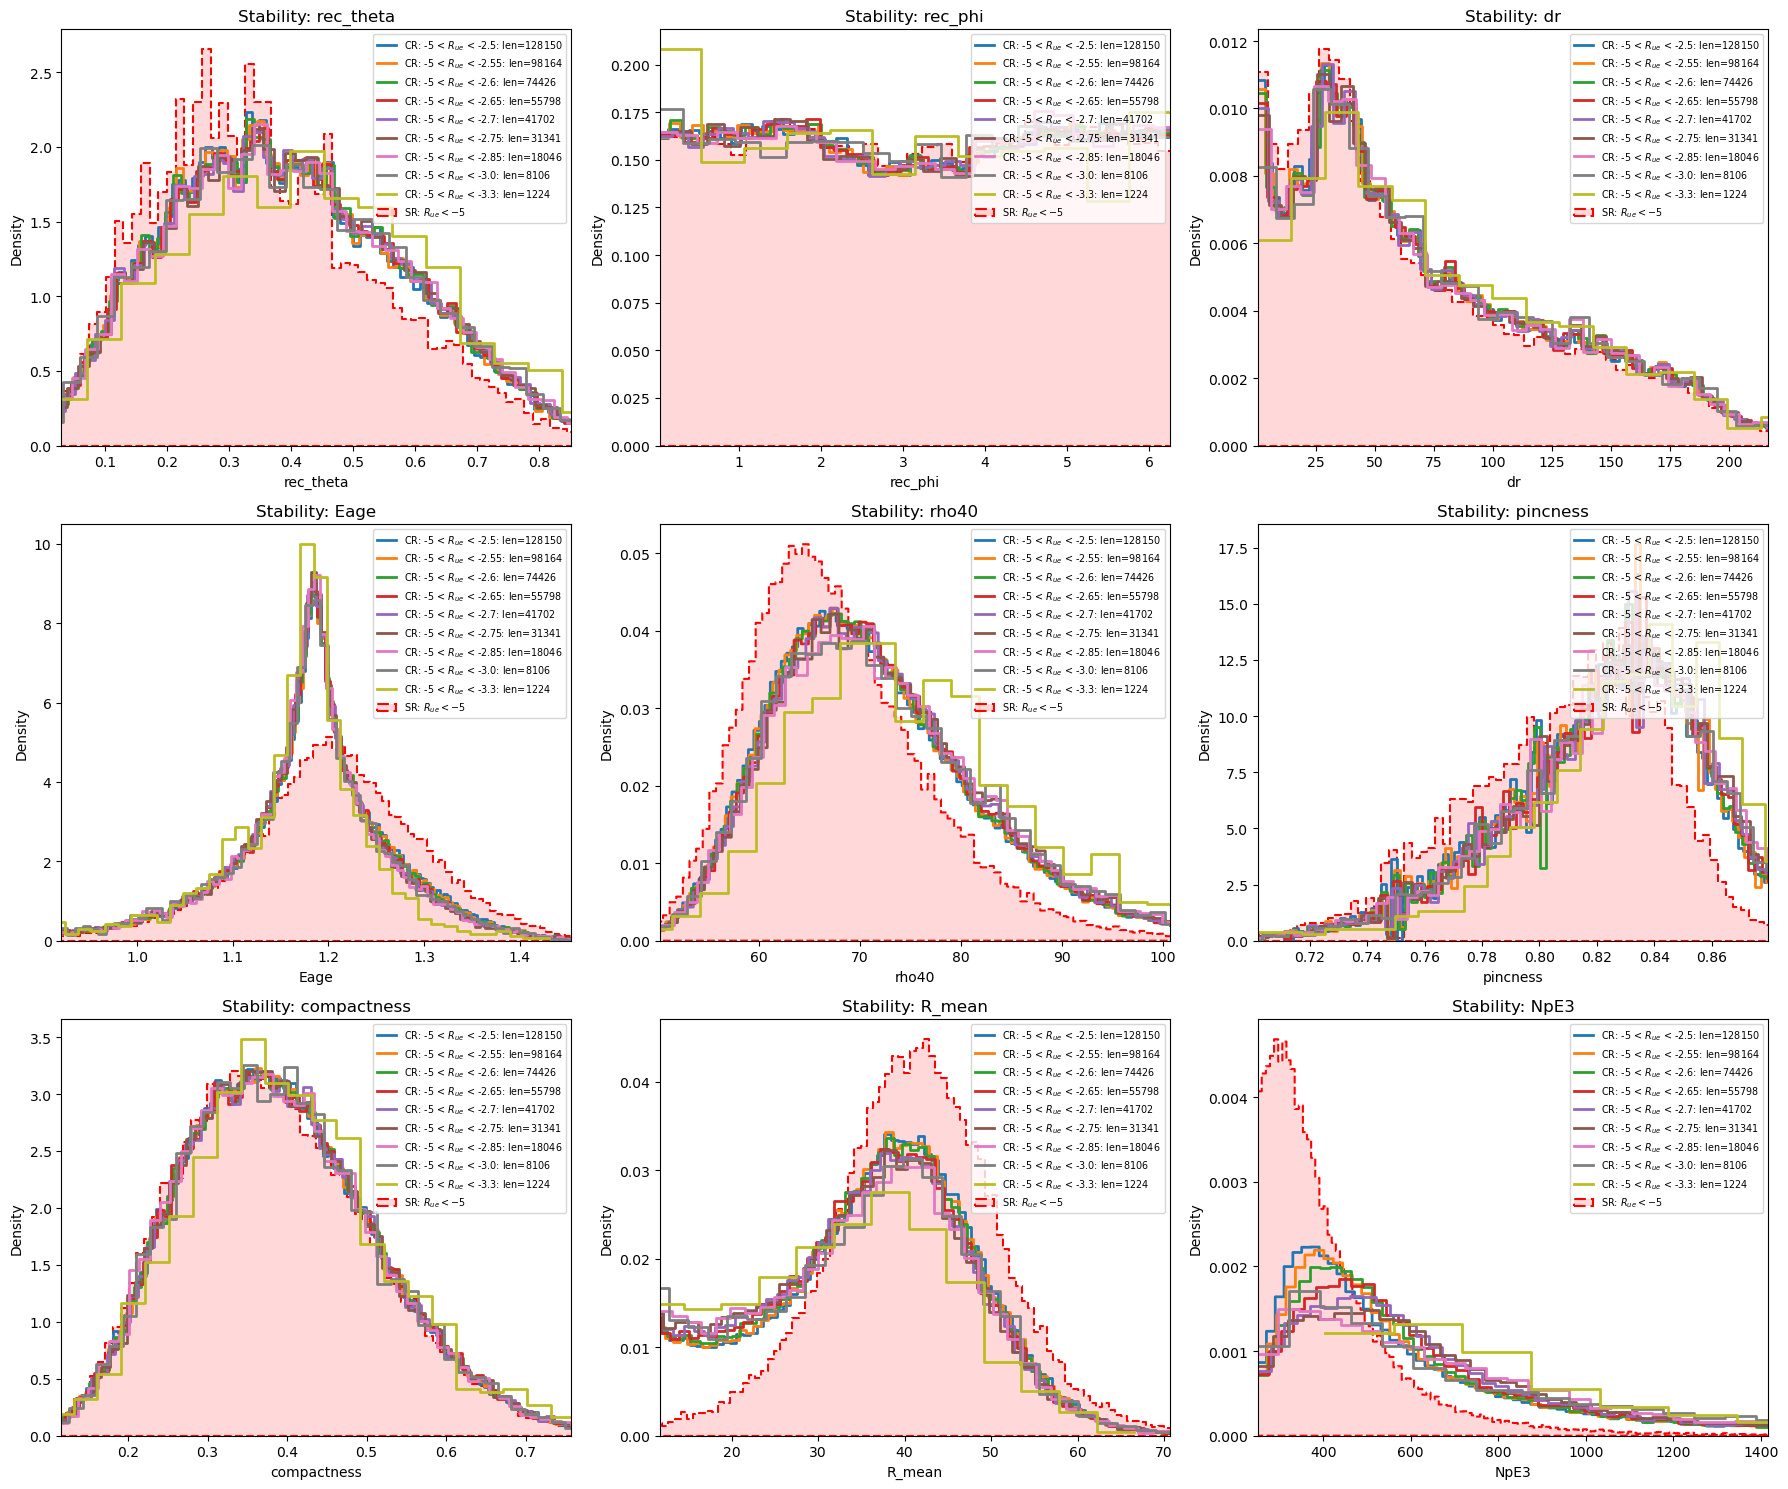

In [96]:
def plot_feature_stability_advanced(df, sideband_thresholds=[-2.5,-2.55, -2.6,-2.65, -2.7, -2.75, -2.85, -3., -3.3], SR_limit=-5, SRexp=False):
    features = ['rec_theta','rec_phi', 'dr', 'Eage', 'rho40', 'pincness', 'compactness', 'R_mean', 'NpE3']
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()
    
    # 为 Sideband 选择渐变色
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # 1. 绘制不同 Sideband 区间的分布 (thresh > R_ue > SR_limit)
        for j, thresh in enumerate(sideband_thresholds):
            # 逻辑：位于阈值和 SR 边界之间
            mask = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            subset = df[mask][col].dropna()
            
            if len(subset) > 5: # 确保有足够数据画图
                sns.histplot(subset, ax=ax, stat="density", element="step", fill=False, 
                             color=colors[j], label=f"CR: {SR_limit} < $R_{{ue}}$ < {thresh}: len={len(subset)}", 
                             linewidth=2)
        
        # 2. 【悄悄加入】真正的 Signal Region 分布 (R_ue <= SR_limit)
        if SRexp is True:
            sr_mask =exp_muon_Rue_df_large['R_ue'] <= SR_limit
            sr_subset = exp_muon_Rue_df_large[sr_mask][col].dropna()
        
            if len(sr_subset) > 0:
                sns.histplot(sr_subset, ax=ax, stat="density", element="step", fill=True, 
                            color="red", alpha=0.15, label=f"SR: $R_{{ue}} < {SR_limit}$", 
                            linewidth=1.5, linestyle='--')

            # 优化坐标轴范围，防止异常值拉长 x 轴
            if not sr_subset.empty:
                lower = np.percentile(sr_subset, 0.5)
                upper = np.percentile(sr_subset, 99.5)
                ax.set_xlim(lower, upper)
            
        ax.set_title(f"Stability: {col}")
        ax.set_xlabel(col)
        # 将图例放在外面或者缩小，避免遮挡
        ax.legend(fontsize='x-small', loc='upper right')
    # axes[-1].axis('off')
    plt.tight_layout()
    # plt.suptitle(f"Feature Comparison: Sidebands vs. True SR ($R_{{ue}}$ < {SR_limit})", y=1.02, fontsize=16)
    plt.show()

# 执行绘图
plot_feature_stability_advanced(exp_muon_Rue_df_large, SRexp=True)

when use R_ue > -2.60 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7064.79 ± 140.51
when use R_ue > -2.61 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7151.44 ± 140.56
when use R_ue > -2.62 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7229.74 ± 143.54
when use R_ue > -2.63 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7348.25 ± 148.59
when use R_ue > -2.64 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7428.81 ± 148.61
when use R_ue > -2.65 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7514.07 ± 150.38
when use R_ue > -2.66 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7601.02 ± 154.87
when use R_ue > -2.67 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7683.43 ± 157.86
when use R_ue > -2.68 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7733.08 ± 152.20
when use R_ue > -2.69 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7783.86 ± 153.02
when use R_ue > -2.70 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7855.42 ± 149.72
when use R_ue > -2.71 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7913.41 ± 156.33
when use R_ue > -2.73 data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: 7959.71 ± 162.32
when use R_ue > -2.74 data, 通过 CR 拟合外推得到的 NuM1=0 预期

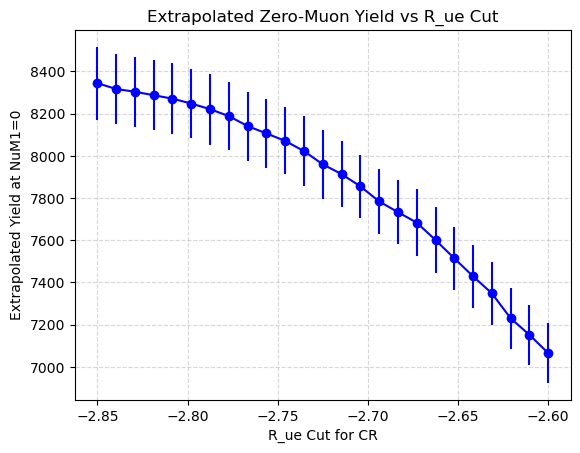

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import moyal
from scipy.optimize import curve_fit
import scipy.integrate as integrate

def extrapolate_zero_muon_yield(df, sr_threshold=-2.85, fit_range=(0.2, 40), bins=30):
    # 1. 严格划定 Control Region，并且只取 NuM1 >= 1 的连续部分进行拟合
    cr_mask = (df['R_ue'] > sr_threshold) & (df['NuM1'] >= fit_range[0]) & (df['NuM1'] <= fit_range[1])
    df_cr = df[cr_mask]
    
    # 2. 提取带权重的直方图数据
    counts, bin_edges = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight_norm'])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 计算误差 (Sum of weights squared)
    counts_sq, _ = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight_norm']**2)
    y_err = np.sqrt(counts_sq)
    
    # 过滤掉 counts 为 0 的 bin 以免拟合权重报错
    valid_mask = counts > 0
    x_fit = bin_centers[valid_mask]
    y_fit = counts[valid_mask]
    y_err = y_err[valid_mask]

    # 3. 定义 Moyal (Landau) 拟合函数
    def landau_pdf(x, amplitude, loc, scale):
        return amplitude * moyal.pdf(x, loc=loc, scale=scale)

    # 初始参数猜测 (p0)
    p0 = [y_fit.max() * 10, np.mean(df_cr['NuM1']), np.std(df_cr['NuM1'])]
    
    # 4. 执行曲线拟合
    popt, pcov = curve_fit(landau_pdf, x_fit, y_fit, p0=p0, sigma=y_err, absolute_sigma=True, maxfev=10000)
    
    # 5. 积分计算 [0, 1] 区间的 Yield
    # 假设 NuM1=0 的物理事件对应的连续分布落在 0 到 1 之间
    yield_0_1, _ = integrate.quad(landau_pdf, 0, 0.2, args=tuple(popt))
    
    # 6. 利用协方差矩阵进行误差传播 (蒙特卡洛采样法)
    # 随机生成 1000 组符合拟合误差分布的参数，分别求积分，取标准差作为系统误差
    samples = np.random.multivariate_normal(popt, pcov, 1000)
    integrals = []
    for samp in samples:
        try:
            val, _ = integrate.quad(landau_pdf, 0, 0.2, args=tuple(samp))
            integrals.append(val)
        except:
            continue
    yield_0_1_err = np.std(integrals)

    # 7. 可视化
    plt.figure(figsize=(10, 6))
    
    # 画原始 Data
    plt.errorbar(x_fit, y_fit, yerr=y_err, fmt='ko', label='CR Data (NuM1 $\geq$ 0.2)', markersize=5)
    
    # 画拟合曲线
    x_plot = np.linspace(0, fit_range[1], 500)
    y_plot = landau_pdf(x_plot, *popt)
    plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Landau (Moyal) Fit')
    
    # 填充外推区域 [0, 0.2]
    x_extrap = np.linspace(0, 0.2, 50)
    y_extrap = landau_pdf(x_extrap, *popt)
    plt.fill_between(x_extrap, 0, y_extrap, color='red', alpha=0.3, label=f'Extrapolated Yield [0, 0.2]: {yield_0_1:.2f} $\pm$ {yield_0_1_err:.2f}')
    
    plt.yscale('log')
    plt.xlim(0, fit_range[1])
    
    # 为了在 log scale 下好看，设置底线
    min_y = min(y_fit.min(), landau_pdf(1, *popt))
    plt.ylim(min_y * 0.1, y_fit.max() * 5)
    
    plt.title("CR NuM1 Landau Fit & Zero-Muon Extrapolation")
    plt.xlabel("NuM1")
    plt.ylabel("Expected Yield (Weighted Counts)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    # plt.show()
    plt.close()

    return yield_0_1, yield_0_1_err

# 运行代码 (确保你的 df 已经包含了 weight_norm)

extrap_yield_list = []
extrap_err_list = []
for Rue_cut in np.linspace(-2.6, -2.85, 25):
    extrap_yield, extrap_err = extrapolate_zero_muon_yield(exp_temp_df, sr_threshold=Rue_cut)
    extrap_yield_list.append(extrap_yield)
    extrap_err_list.append(extrap_err)
    print(f"when use R_ue > {Rue_cut:.2f} data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: {extrap_yield:.2f} ± {extrap_err:.2f}")
    
plt.errorbar(np.linspace(-2.6, -2.85, 25), extrap_yield_list, yerr=extrap_err_list, fmt='o-', color='blue')
plt.xlabel("R_ue Cut for CR")
plt.ylabel("Extrapolated Yield at NuM1=0")
plt.title("Extrapolated Zero-Muon Yield vs R_ue Cut")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

from scipy.optimize import curve_fit

# x 是 R_ue Cut, y 是外推 Yield
def plateau_func(x, A, B, C):
    return A - B * np.exp(C * x) # C 控制收敛速度

# 注意：x 越小（越负），代表包含数据越多。
# A 即为预测的平台高度
popt, _ = curve_fit(plateau_func, np.linspace(-2.6, -2.85, 25), extrap_yield_list, p0=[8500, 100, 2], maxfev=10000)
print(f"预测的最终平台 Yield (A): {popt[0]}")
# plot
x_fit = np.linspace(-2.6, -3.1, 100)
y_fit = plateau_func(x_fit, *popt)
plt.errorbar(np.linspace(-2.6, -2.85, 25), extrap_yield_list, yerr=extrap_err_list, fmt='o', color='blue', label='Extrapolated Yield')
plt.plot(x_fit, y_fit, 'r-', label='Plateau Fit')
plt.xlabel("R_ue Cut for CR")
plt.ylabel("Extrapolated Yield at NuM1=0")
plt.title("Extrapolated Zero-Muon Yield vs R_ue Cut with Plateau Fit")
plt.text(x_fit[-1], popt[0]*0.9, f"Predicted Plateau Yield: {popt[0]:.2f}", fontsize=12, color='red')
plt.grid(True, ls="--", alpha=0.5)
# plt.yscale('log')
plt.legend()
plt.show()

预测的最终平台 Yield (A): 8649.610086553193


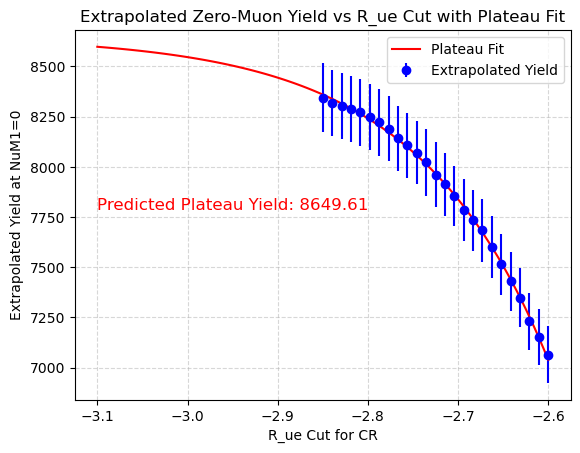


>>> Step 1: Applying Template Cut (Rue < -1.6)...
Events after cut:
  Large Base (QGS): 237806 -> 5888
  Small Base (QGS): 54702 -> 806
  Small Target (EPOS): 285007 -> 7202

>>> Step 2: Learning Model Systematics (Robust)...
Morphing: QGSJET -> EPOS
   [Eage] SHIFT: +0.0002 (Base: 1.18 -> Target: 1.18)
   [rec_theta] SHIFT: +0.0080 (Base: 0.35 -> Target: 0.36)
   [rho40] SHIFT: -0.1240 (Base: 73.00 -> Target: 72.88)
   [pincness] SHIFT: -0.0005 (Base: 0.85 -> Target: 0.85)
   [compactness] SHIFT: -0.0081 (Base: 0.45 -> Target: 0.44)
   [R_ue] SHIFT: -0.0361 (Base: -1.76 -> Target: -1.79)

Morphing: QGSJET -> QGSJETII
   [Eage] SHIFT: +0.0025 (Base: 1.18 -> Target: 1.18)
   [rec_theta] SHIFT: +0.0091 (Base: 0.35 -> Target: 0.36)
   [rho40] SHIFT: -0.0190 (Base: 73.00 -> Target: 72.99)
   [pincness] SHIFT: -0.0017 (Base: 0.85 -> Target: 0.85)
   [compactness] SHIFT: +0.0088 (Base: 0.45 -> Target: 0.46)
   [R_ue] SHIFT: +0.0045 (Base: -1.76 -> Target: -1.75)

>>> Step 3: Generating Pseu

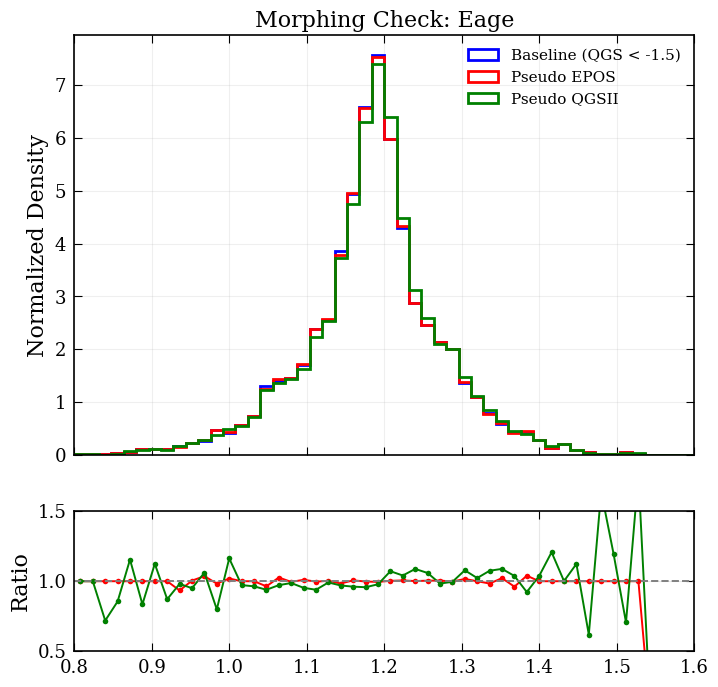

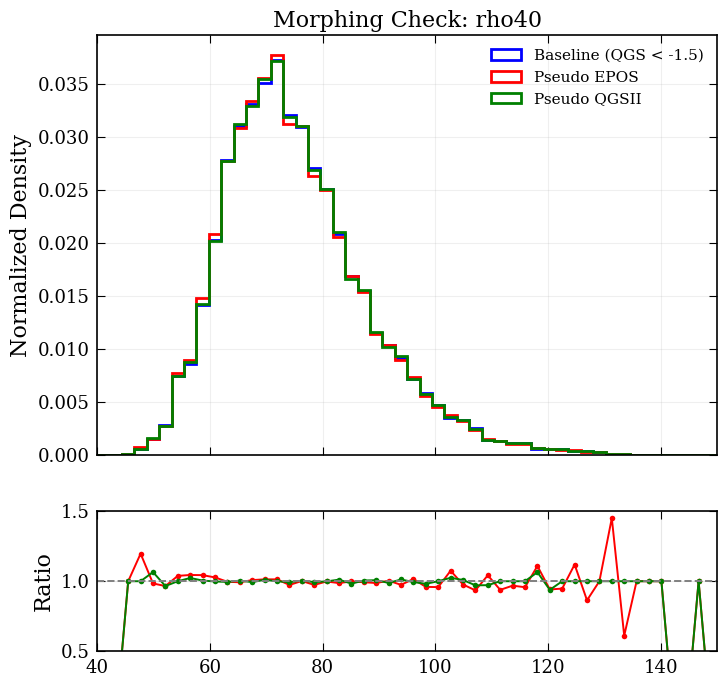

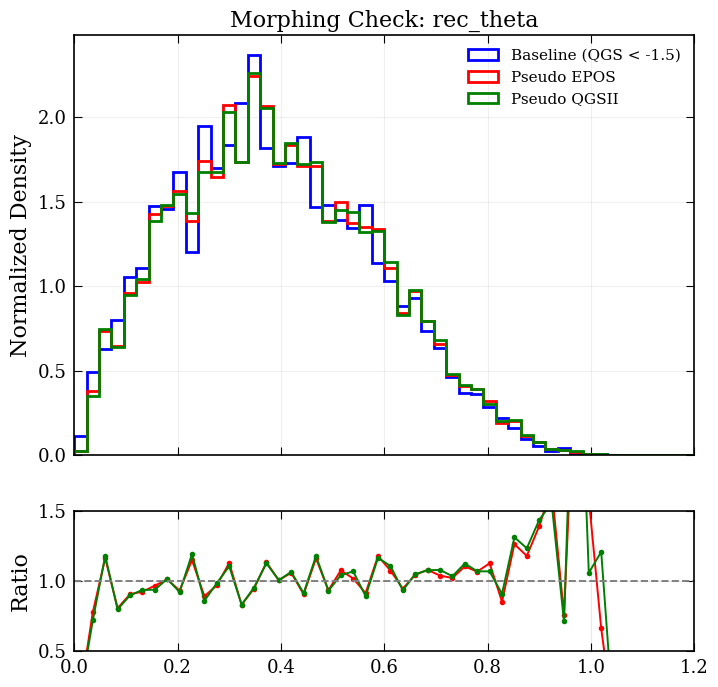

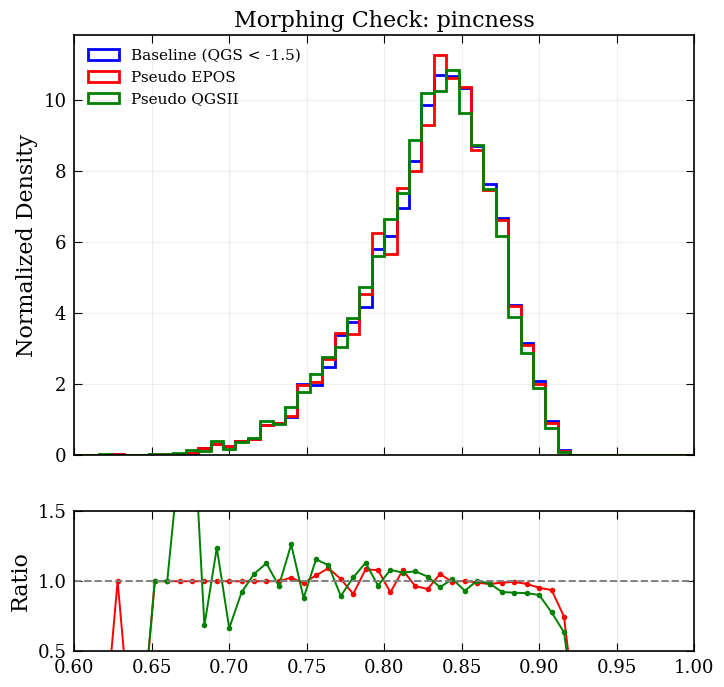

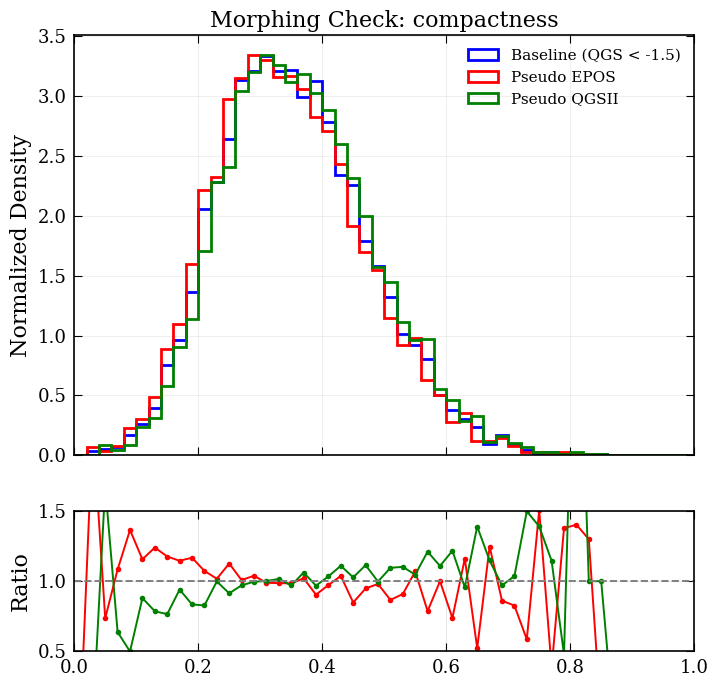

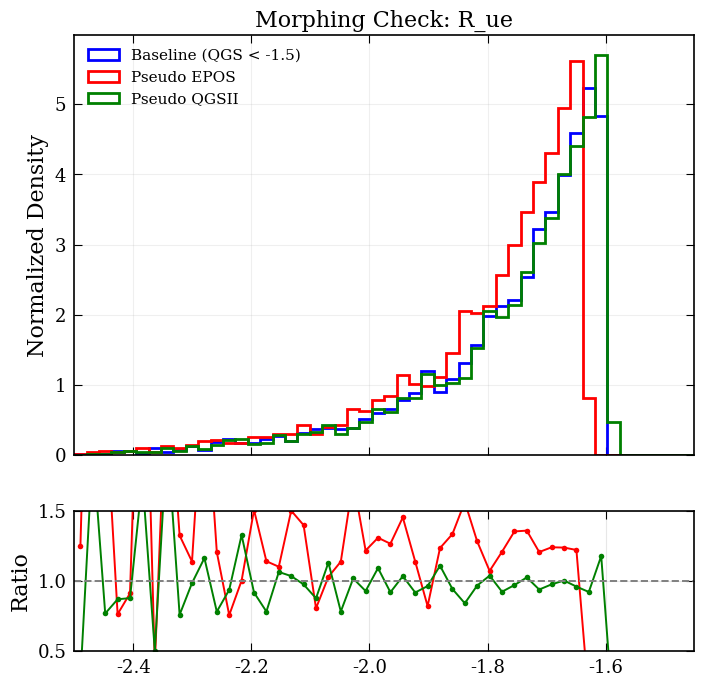

Analysis Ready. You now have:
1. pr_df_large_cut (Central Value)
2. pseudo_ef_large (Systematic Variation 1)
3. pseudo_qf_large (Systematic Variation 2)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

# ==========================================
# 0. 全局配置与工具类
# ==========================================
# 核心结论：仅使用 Rue < -1.5 的数据作为背景模板
TEMPLATE_CUT = -1.6

class Plotter:
    COLORS = ['blue', 'red', 'green', 'orange', 'purple']
    
    @staticmethod
    def plot_morphing_check(dfs, labels, var, weight_col, bins=50, range_val=None):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), 
                                       gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        hists = []
        for i, (df, label) in enumerate(zip(dfs, labels)):
            w = df[weight_col] if weight_col in df.columns else np.ones(len(df))
            h, edges, _ = ax1.hist(df[var], bins=bins, range=range_val, weights=w,
                                   histtype='step', lw=2, density=True,
                                   label=label, color=Plotter.COLORS[i % len(Plotter.COLORS)])
            hists.append(h)
            
        ax1.set_ylabel('Normalized Density')
        ax1.legend()
        ax1.set_title(f'Morphing Check: {var}')
        ax1.grid(True, alpha=0.2)

        centers = 0.5 * (edges[:-1] + edges[1:])
        ref_h = hists[0]
        for i in range(1, len(hists)):
            ratio = np.divide(hists[i], ref_h, out=np.zeros_like(hists[i]), where=ref_h!=0)
            ax2.plot(centers, ratio, 'o-', markersize=4, 
                     color=Plotter.COLORS[i % len(Plotter.COLORS)], label=f'Ratio {i}')
        ax2.axhline(1, color='gray', ls='--')
        ax2.set_ylabel('Ratio')
        if range_val: ax2.set_xlim(range_val)
        ax2.set_ylim(0.5, 1.5)
        ax2.grid(True, alpha=0.3)
        plt.show()


class PhysicsMorpher:
    def __init__(self, baseline_small, target_small, weight_col='gaisser_weight'):
        self.base = baseline_small
        self.target = target_small
        self.w_col = weight_col
        self.strategies = {} 

    def _get_robust_mean(self, df, var, bounds=None):
        """计算鲁棒的加权均值，剔除离群点"""
        # 1. 基础清理
        series = pd.to_numeric(df[var], errors='coerce')
        valid_idx = series.dropna().index
        
        # 2. 获取数据和权重
        vals = series.loc[valid_idx].values
        weights = df.loc[valid_idx, self.w_col].values
        
        # 3. 范围截断 (关键步骤！)
        # 如果不指定 bounds，默认切掉首尾 1% 的极端值，防止异常值拉偏均值
        if bounds is None:
            lower = np.percentile(vals, 1)
            upper = np.percentile(vals, 99)
        else:
            lower, upper = bounds
            
        mask = (vals >= lower) & (vals <= upper)
        
        # 如果截断后没数据了，回退到原始数据
        if np.sum(mask) == 0:
            print(f"   [Warning] No data in range {lower}-{upper} for {var}, using all data.")
            return np.average(vals, weights=weights)
            
        return np.average(vals[mask], weights=weights[mask])

    def learn_diff(self, var, mode='shift', bounds=None):
        """
        bounds: tuple (min, max)，指定计算均值时的物理范围，例如 (40, 150)
        """
        # 使用鲁棒均值计算
        mean_base = self._get_robust_mean(self.base, var, bounds)
        mean_target = self._get_robust_mean(self.target, var, bounds)
        
        if mode == 'shift':
            val = mean_target - mean_base
            print(f"   [{var}] SHIFT: {val:+.4f} (Base: {mean_base:.2f} -> Target: {mean_target:.2f})")
        elif mode == 'scale':
            # 防止除零
            if mean_base == 0: mean_base = 1e-6
            val = mean_target / mean_base
            print(f"   [{var}] SCALE: {val:.4f} (Base: {mean_base:.2f} -> Target: {mean_target:.2f})")
            
        self.strategies[var] = (mode, val)

    def generate_pseudo(self, df_large):
        df_new = df_large.copy()
        for var, (mode, val) in self.strategies.items():
            if var not in df_new.columns: continue
            
            # 确保类型正确
            vals = pd.to_numeric(df_new[var], errors='coerce').fillna(0).values
            
            if mode == 'shift':
                df_new[var] = vals + val
            elif mode == 'scale':
                df_new[var] = vals * val
                
        df_new['data_type'] = 'Pseudo_MC'
        return df_new

# ==========================================
# 1. 关键步骤：应用 Rue < -1.5 切选
# ==========================================
print(f"\n>>> Step 1: Applying Template Cut (Rue < {TEMPLATE_CUT})...")

# 1.1 切选 大范围基准数据 (这是我们的核心背景模板)
# 只有切完之后，它才是合格的"背景"
pr_df_large_cut = pr_df_large[pr_df_large['R_ue'] < TEMPLATE_CUT].copy()

# 1.2 切选 小范围数据 (用于学习模型差异)
# 我们必须在同样的相空间内学习差异，否则规律可能不适用
TEMPLATE_CUT_small = TEMPLATE_CUT
TEMPLATE_CUT_shigh = -3
pr_df_cut = pr_df[(pr_df['R_ue'] < TEMPLATE_CUT_small) & (pr_df['R_ue'] > TEMPLATE_CUT_shigh)].copy()       # QGS Small
pr_ef_df_cut = pr_ef_df[(pr_ef_df['R_ue'] < TEMPLATE_CUT_small) & (pr_ef_df['R_ue'] > TEMPLATE_CUT_shigh)].copy() # EPOS Small
pr_qf_df_cut = pr_qf_df[(pr_qf_df['R_ue'] < TEMPLATE_CUT_small) & (pr_qf_df['R_ue'] > TEMPLATE_CUT_shigh)].copy() # QGSII Small

print(f"Events after cut:")
print(f"  Large Base (QGS): {len(pr_df_large)} -> {len(pr_df_large_cut)}")
print(f"  Small Base (QGS): {len(pr_df)} -> {len(pr_df_cut)}")
print(f"  Small Target (EPOS): {len(pr_ef_df)} -> {len(pr_ef_df_cut)}")
# ==========================================
# 2. 学习模型差异 (修正版)
# ==========================================
print("\n>>> Step 2: Learning Model Systematics (Robust)...")

# 配置：rho40 建议用 scale，且必须限制计算范围
morph_vars_config = {
    'Eage':      {'mode': 'shift', 'bounds': (1.0, 1.4)},  
    'rec_theta': {'mode': 'shift', 'bounds': (5*np.pi/180, 65*np.pi/180)},     
    'rho40':     {'mode': 'shift', 'bounds': (60, 100)},    # 重点：限制在 40-150 范围内计算均值
    'pincness': {'mode': 'shift', 'bounds': (0.7, 0.88)},
    'compactness': {'mode': 'shift', 'bounds': (0, 1)},
    'R_ue': {'mode': 'shift', 'bounds': (-2.5, -1.4)}, # 重点：限制在 -2.5 到 -1.4 范围内计算均值
}

# --- A. 学习 QGS -> EPOS ---
print("Morphing: QGSJET -> EPOS")
morpher_ef = PhysicsMorpher(pr_df_cut, pr_ef_df_cut, weight_col='gaisser_weight')

for var, cfg in morph_vars_config.items():
    if var in pr_df_cut.columns:
        # 传入 bounds 参数
        morpher_ef.learn_diff(var, mode=cfg['mode'], bounds=cfg['bounds'])

# --- B. 学习 QGS -> QGSJETII ---
print("\nMorphing: QGSJET -> QGSJETII")
morpher_qf = PhysicsMorpher(pr_df_cut, pr_qf_df_cut, weight_col='gaisser_weight')

for var, cfg in morph_vars_config.items():
    if var in pr_df_cut.columns:
        morpher_qf.learn_diff(var, mode=cfg['mode'], bounds=cfg['bounds'])
# ==========================================
# 3. 生成伪数据 (应用到 Cut 后的大范围基准)
# ==========================================
print("\n>>> Step 3: Generating Pseudo Data...")

# 这里的输入必须是已经切过 Rue < -1.5 的 pr_df_large_cut
# 因为我们只关心这一部分的系统误差
pseudo_ef_large = morpher_ef.generate_pseudo(pr_df_large_cut)
pseudo_qf_large = morpher_qf.generate_pseudo(pr_df_large_cut)

# ==========================================
# 4. 验证结果
# ==========================================
print("\n>>> Step 4: Validating Systematics Range...")

# 验证 Eage
Plotter.plot_morphing_check(
    [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
    ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
    'Eage', 'gaisser_weight', range_val=(0.8, 1.6)
)

# 验证 rho40
if 'rho40' in pr_df_large_cut.columns:
    Plotter.plot_morphing_check(
        [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
        ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
        'rho40', 'gaisser_weight', range_val=(40, 150) # 根据实际范围调整
    )

# 验证 rec_theta
Plotter.plot_morphing_check(
    [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
    ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
    'rec_theta', 'gaisser_weight', range_val=(0, 1.2)
)

Plotter.plot_morphing_check(
    [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
    ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
    'pincness', 'gaisser_weight', range_val=(0.6, 1)
)
Plotter.plot_morphing_check(
    [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
    ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
    'compactness', 'gaisser_weight', range_val=(0, 1)
)
Plotter.plot_morphing_check(
    [pr_df_large_cut, pseudo_ef_large, pseudo_qf_large],
    ['Baseline (QGS < -1.5)', 'Pseudo EPOS', 'Pseudo QGSII'],
    'R_ue', 'gaisser_weight', range_val=(-2.5,-1.45)
)
print("Analysis Ready. You now have:")
print("1. pr_df_large_cut (Central Value)")
print("2. pseudo_ef_large (Systematic Variation 1)")
print("3. pseudo_qf_large (Systematic Variation 2)")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import copy
# ==========================================
# 0. 全局配置
# ==========================================
# 这里的特征必须与 DataFrame 中的列名完全一致
# 如果你之前叫 'R_mean' 而现在想用 'rho40'，请确保 df 里有 'rho40' 'pincness',
FEATURES = ['rec_theta', 'Eage', 'rho40', 'compactness'] 
TARGET_FLUX = 'gaisser_weight'

# ==========================================
# 1. 类定义 (保持你的架构，稍作优化)
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # drop_prob 通常在 0.2 到 0.5 之间
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=0.5),  # <--- 新增：丢弃50%的神经元连接

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(p=0.5),  # <--- 新增

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

from sklearn.metrics import roc_curve, auc

class ClassifierManager:
    def __init__(self, features, model_type='xgb', device='cpu'):
        self.features = features
        self.model_type = model_type.lower()
        self.device = device
        
        self.trained_models = []
        self.trained_scalers = []
        
        # [新增] 用于存储绘图数据
        self.loss_histories = [] # 存储每个Fold的 {'train': [], 'val': []}
        self.fold_roc_data = []  # 存储每个Fold的 (y_val, preds)
        
    def prepare_data(self, bkg_df, sig_df, weight_col='gaisser_weight', sig_weight_col='weight'):
        X_bkg = bkg_df[self.features].values
        X_sig = sig_df[self.features].values
        
        w_bkg = bkg_df[weight_col].values
        w_sig = sig_df[sig_weight_col].values
        w_bkg = w_bkg / w_bkg.mean()
        w_sig = w_sig / w_sig.mean()

        self.X_raw = np.vstack([X_bkg, X_sig])
        self.y_raw = np.concatenate([np.zeros(len(X_bkg)), np.ones(len(X_sig))])
        self.w_raw = np.concatenate([w_bkg, w_sig])
        
        self.n_bkg = len(X_bkg)

    def _get_new_model(self):
        if self.model_type == 'xgb':
            return xgb.XGBClassifier(
                n_estimators=800, max_depth=4, learning_rate=0.03,
                objective='binary:logistic', n_jobs=-1, random_state=42,
                tree_method='gpu_hist' if 'cuda' in self.device else 'hist',
                early_stopping_rounds=50
            )
        elif self.model_type == 'mlp':
            return MLP(len(self.features)).to(self.device)

    def train_kfold(self, n_splits=5, epochs=2000):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_preds = np.zeros(len(self.y_raw))
        
        self.trained_models = []
        self.trained_scalers = []
        self.loss_histories = [] # 重置历史
        self.fold_roc_data = []  # 重置ROC数据

        print(f">>> Starting {n_splits}-Fold Cross-Validation ({self.model_type})...")

        for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y_raw)):
            print(f"\n--- Fold {fold+1}/{n_splits} ---")
            
            X_train, y_train, w_train = self.X_raw[train_idx], self.y_raw[train_idx], self.w_raw[train_idx]
            X_val, y_val, w_val = self.X_raw[val_idx], self.y_raw[val_idx], self.w_raw[val_idx]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.trained_scalers.append(scaler)
            
            model = self._get_new_model()
            
            # [新增] 当前Fold的Loss记录
            fold_history = {'train': [], 'val': []}

            if self.model_type == 'xgb':
                model.fit(X_train_scaled, y_train, sample_weight=w_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
                    sample_weight_eval_set=[w_train, w_val],
                    verbose=50 # 关闭详细打印，保持整洁
                )
                # XGBoost 获取 loss history 比较特殊，这里简化处理，只处理 MLP 的需求
                # 如果需要 XGB 的 Loss 图，需要从 model.evals_result() 获取
                try:
                    limit = model.best_iteration + 1
                    preds = model.predict_proba(X_val_scaled, iteration_range=(0, limit))[:, 1]
                except AttributeError:
                    preds = model.predict_proba(X_val_scaled)[:, 1]

            elif self.model_type == 'mlp':
                Xt = torch.FloatTensor(X_train_scaled).to(self.device)
                yt = torch.FloatTensor(y_train).unsqueeze(1).to(self.device)
                wt = torch.FloatTensor(w_train).unsqueeze(1).to(self.device)
                
                Xv = torch.FloatTensor(X_val_scaled).to(self.device)
                yv = torch.FloatTensor(y_val).unsqueeze(1).to(self.device)
                wv = torch.FloatTensor(w_val).unsqueeze(1).to(self.device)
                
                optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
                criterion = nn.BCELoss(reduction='none')
                
                for epoch in range(epochs):
                    model.train()
                    optimizer.zero_grad()
                    out = model(Xt)
                    loss_train = (criterion(out, yt) * wt).mean()
                    loss_train.backward()
                    optimizer.step()
                    
                    # [新增] 每个Epoch都记录验证集 Loss (为了画平滑的曲线)
                    model.eval()
                    with torch.no_grad():
                        out_val = model(Xv)
                        loss_val = (criterion(out_val, yv) * wv).mean()
                    
                    # 记录历史
                    fold_history['train'].append(loss_train.item())
                    fold_history['val'].append(loss_val.item())

                    if (epoch + 1) % 100 == 0:
                        print(f"Epoch [{epoch+1}/{epochs}] | Train: {loss_train.item():.5f} | Val: {loss_val.item():.5f}")

                model.eval()
                with torch.no_grad():
                    preds = model(Xv).cpu().numpy().flatten()
                
                # 记录本折的 Loss 历史
                self.loss_histories.append(fold_history)

            oof_preds[val_idx] = preds
            self.trained_models.append(model)
            # [新增] 记录本折的 ROC 数据
            self.fold_roc_data.append((y_val, preds))
            
        print("\n>>> K-Fold Training Complete.")
        return oof_preds

    def predict_ensemble(self, df):
        df_clean = df[self.features].copy()
        for col in self.features:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean = df_clean.fillna(0).infer_objects()
        X_raw = df_clean.values
        
        all_fold_preds = []
        for i, (model, scaler) in enumerate(zip(self.trained_models, self.trained_scalers)):
            X_scaled = scaler.transform(X_raw)
            if self.model_type == 'xgb':
                try:
                    if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                        limit = model.best_iteration + 1
                        p = model.predict_proba(X_scaled, iteration_range=(0, limit))[:, 1]
                    else:
                        p = model.predict_proba(X_scaled)[:, 1]
                except:
                    p = model.predict_proba(X_scaled)[:, 1]
            elif self.model_type == 'mlp':
                model.eval()
                Xt = torch.FloatTensor(X_scaled).to(self.device)
                with torch.no_grad():
                    p = model(Xt).cpu().numpy().flatten()
            all_fold_preds.append(p)
        return np.mean(all_fold_preds, axis=0)
    
    def get_feature_importance(self):
        if self.model_type == 'xgb' and self.trained_models:
            return dict(zip(self.features, self.trained_models[0].feature_importances_))
        return {}

class Plotter:
    COLORS = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="Score Distribution"):
        # 1. 设置画板：上大下小 (3:1)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                       gridspec_kw={'height_ratios': [3, 1]}, 
                                       sharex=True)
        
        hists = []
        edges = None
        
        # ==========================================
        # 上图：分布直方图 (Main Distribution)
        # ==========================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            # 视觉样式：最后两个(Signal/Exp)用填充，其他的用线条
            is_ref = (i >= len(dfs) - 2) 
            h_type = 'stepfilled' if is_ref else 'step'
            alpha = 0.3 if is_ref else 1.0
            lw = 2 if not is_ref else 1.5
            color = Plotter.COLORS[i % len(Plotter.COLORS)]
            
            # 绘制并保存直方图数据
            # density=True 用于对比形状
            h, bin_edges, _ = ax1.hist(df['mlp_score'], bins=bins, range=(0, 1), weights=w,
                                       histtype=h_type, alpha=alpha, lw=lw, density=True, 
                                       label=label, color=color)
            hists.append(h)
            if edges is None: edges = bin_edges
            
        ax1.set_ylabel('Normalized Density')
        # ax1.set_yscale('log') # 强烈建议 Score 开启 Log 模式，否则看不到高分段细节
        ax1.set_title(title)
        # 图例放上面，避免遮挡数据
        ax1.legend(loc='upper center',  ncol=3, frameon=False)
        ax1.grid(True, which='both', linestyle='--', alpha=0.3)

        # ==========================================
        # 下图：比例图 (Ratio Plot)
        # ==========================================
        # 默认以第一个数据集 (dfs[0], 即 Baseline) 作为分母
        ref_h = hists[0]
        centers = 0.5 * (edges[:-1] + edges[1:])
        
        for i in range(1, len(hists)):
            # 计算 Ratio，处理除零情况
            # 信号 (Signal) 分布通常和背景差异极大，画 Ratio 可能会让图变得很乱
            # 你可以选择跳过 Signal (通常 label 包含 'Signal' 或 'MN')
            if 'Signal' in labels[i] or 'MN' in labels[i]:
                continue

            ratio = np.divide(hists[i], ref_h, out=np.zeros_like(ref_h), where=ref_h!=0)
            
            # 只画有数据的点，避免由 0/0 产生的噪点
            mask = ref_h > 0
            ax2.plot(centers[mask], ratio[mask], 'o-', markersize=3, lw=1,
                     color=Plotter.COLORS[i % len(Plotter.COLORS)])
        
        # 参考线
        ax2.axhline(1, color='gray', linestyle='--')
        
        ax2.set_xlabel('Classification Score (0=Bkg, 1=Sig)')
        ax2.set_ylabel('Ratio / Baseline')
        
        # 设置 Ratio 的显示范围，避免个别极端值破坏视图
        ax2.set_ylim(0.0, 2.0) 
        ax2.grid(True, which='both', linestyle='--', alpha=0.3)
        
        # 调整间距
        plt.subplots_adjust(hspace=0.05)
        plt.show()


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ==========================================
# 2. 数据准备与 Cut 策略
# ==========================================
print("\n>>> Step A: Applying Physics Cuts...")

# --- 应用 Cuts ---
CUT_RUE_NOM = -2.8
CUT_E_NOM, CUT_E_MAX = 1.95, 2.1

# 定义 Cut 函数 (只切物理窗口，不切区分变量)
def apply_analysis_cuts(df, dataset_name):

    # cond_E = (df['recE'] > 1.9) & (df['recE'] < 2.1)
    cond_E = (df['recE'] > CUT_E_NOM) & (df['recE'] < CUT_E_MAX)
    
    # cond_R = (df['rho40'] > 0)  #& (df['Eage'] < 1.08)
    # cond_A = 
    # 组合 Cut & cond_A
    mask = cond_E
    df_cut = df[mask].copy()
    
    print(f"[{dataset_name}] Cuts applied. Events: {len(df)} -> {len(df_cut)}")
    return df_cut


# 1. 训练用背景 (使用 Shape Invariant Template: Rue < -1.5)
# 注意：pr_df_large_cut 已经是 Rue < -1.5 了，这里再加 recE cut
bkg_train_final = apply_analysis_cuts(pr_df_large_cut, "Bkg Train (QGS)")

# 2. 训练用信号 (必须是 Rue < -2.6)
# sig_train_final = mn_df_large[mn_df_large['R_ue'] < CUT_RUE_NOM].copy()
# sig_train_final = apply_analysis_cuts(sig_train_final, "Signal Train")
  # 随机选择 1000 个信号事件
sig_train_final = mn_df_large[mn_df_large['R_ue'] < CUT_RUE_NOM].sample(3000, random_state=42, replace=False).copy()
sig_train_final['weight'] *= mn_df_large[mn_df_large['R_ue'] < CUT_RUE_NOM]['weight'].sum() / sig_train_final['weight'].sum()
sig_train_final = apply_analysis_cuts(sig_train_final, "Signal Train")


# 3. 实验数据 (必须是 Rue < -2.6)
exp_final = exp_muon_Rue_df_large[exp_muon_Rue_df_large['R_ue'] < CUT_RUE_NOM].copy()
exp_final = apply_analysis_cuts(exp_final, "Exp Data")

# 4. 系统误差样本 (Pseudo EPOS/QGSII)
pseudo_ef_final = apply_analysis_cuts(pseudo_ef_large, "Sys EPOS")
pseudo_qf_final = apply_analysis_cuts(pseudo_qf_large, "Sys QGSII")

# ==========================================
# 3. K-Fold 训练
# ==========================================
print("\n>>> Step B: K-Fold Training & OOF Prediction...")

manager = ClassifierManager(FEATURES, model_type='xgb', device='cpu')
# manager = ClassifierManager(FEATURES, model_type='mlp', device='cpu')
manager.prepare_data(bkg_train_final, sig_train_final, weight_col=TARGET_FLUX, sig_weight_col='weight')
oof_scores_total = manager.train_kfold(n_splits=5, epochs=1500)

# 将 OOF 分数拆分回 Bkg 和 Sig DataFrame
# 顺序必须和 prepare_data 中的合并顺序一致 (先 Bkg 后 Sig)
n_bkg = manager.n_bkg
bkg_train_final['mlp_score'] = oof_scores_total[:n_bkg]
sig_train_final['mlp_score'] = oof_scores_total[n_bkg:]

print("OOF Scores assigned back to training dataframes.")

# ==========================================
# 4. 外部数据集成预测 (Ensemble Prediction)
# ==========================================
print("\n>>> Step C: Ensemble Inference on External Data...")

# 对于实验数据和系统误差样本，使用 5 个模型的平均值
# 这比单模型预测更稳健
exp_final['mlp_score'] = manager.predict_ensemble(exp_final)
pseudo_ef_final['mlp_score'] = manager.predict_ensemble(pseudo_ef_final)
pseudo_qf_final['mlp_score'] = manager.predict_ensemble(pseudo_qf_final)

# ==========================================
# 5. 结果可视化与检查
# ==========================================
print("\n>>> Step D: Visualizing Results...")

# 输出高分区的统计信息
CUT_SCORE = 0.
n_exp = exp_final[exp_final['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_train_final[bkg_train_final['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_train_final[sig_train_final['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")


# 输出高分区的统计信息
CUT_SCORE = 0.9
n_exp = exp_final[exp_final['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_train_final[bkg_train_final['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_train_final[sig_train_final['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")




>>> Step A: Applying Physics Cuts...
[Bkg Train (QGS)] Cuts applied. Events: 5888 -> 1724
[Signal Train] Cuts applied. Events: 3000 -> 2465
[Exp Data] Cuts applied. Events: 65949 -> 12950
[Sys EPOS] Cuts applied. Events: 5888 -> 1724
[Sys QGSII] Cuts applied. Events: 5888 -> 1724

>>> Step B: K-Fold Training & OOF Prediction...
>>> Starting 5-Fold Cross-Validation (mlp)...

--- Fold 1/5 ---
Epoch [100/1500] | Train: 0.40291 | Val: 0.38255
Epoch [200/1500] | Train: 0.38510 | Val: 0.36854
Epoch [300/1500] | Train: 0.37758 | Val: 0.36451
Epoch [400/1500] | Train: 0.37666 | Val: 0.36073
Epoch [500/1500] | Train: 0.37326 | Val: 0.36078
Epoch [600/1500] | Train: 0.36373 | Val: 0.36046
Epoch [700/1500] | Train: 0.36827 | Val: 0.35911
Epoch [800/1500] | Train: 0.36241 | Val: 0.36036
Epoch [900/1500] | Train: 0.36700 | Val: 0.36000
Epoch [1000/1500] | Train: 0.35991 | Val: 0.36027
Epoch [1100/1500] | Train: 0.35743 | Val: 0.36003
Epoch [1200/1500] | Train: 0.35488 | Val: 0.36118
Epoch [1300/15

In [13]:
exp_final[exp_final['mlp_score']>0.950][['R_ue','rec_theta', 'Eage', 'rho40', 'compactness', 'mlp_score','mjd', 'tlat','tlong']].sort_values('mlp_score', ascending=False)

,R_ue,rec_theta,Eage,rho40,compactness,mlp_score,mjd,tlat,tlong
117860,-7.039325,0.963052,0.985496,96.679317,0.258892,0.998396,60192.073091,12.208758,131.866455
22080,-3.051372,0.880983,1.025589,89.497537,0.534365,0.998009,59989.722264,65.833969,100.010117
124145,-3.083795,0.927916,0.958862,104.590906,0.287888,0.997597,60205.174344,38.849533,118.513863
34112,-6.574694,0.968669,1.134632,85.992101,0.354006,0.996874,60017.326699,18.660223,164.968216
98416,-7.009150,0.835968,0.928871,89.511283,0.372189,0.996760,60151.363079,51.980438,320.842224
...,...,...,...,...,...,...,...,...,...
23088,-6.486849,0.664639,1.024554,80.536728,0.237087,0.950962,59991.949782,58.316517,328.576721
84223,-6.595338,0.558706,1.047506,82.781701,0.488561,0.950783,60121.532026,68.175598,189.626389
99291,-6.841135,0.661187,1.096335,77.208923,0.384544,0.950346,60154.154999,14.611349,147.230194
54986,-6.507987,0.699666,0.947968,79.488864,0.199074,0.950242,60061.609658,36.195038,227.757935


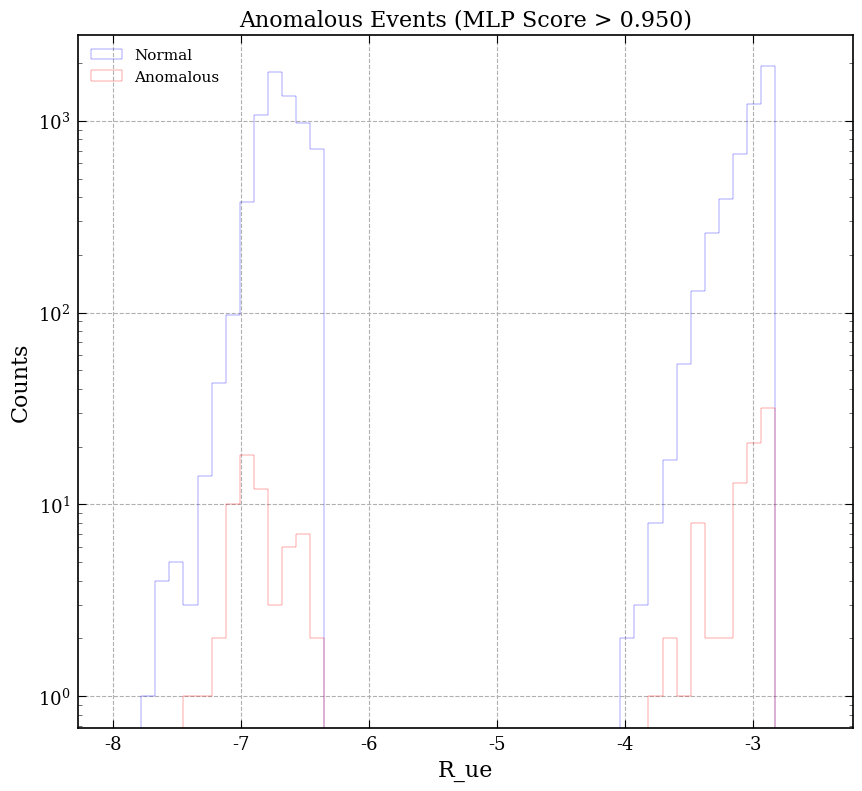

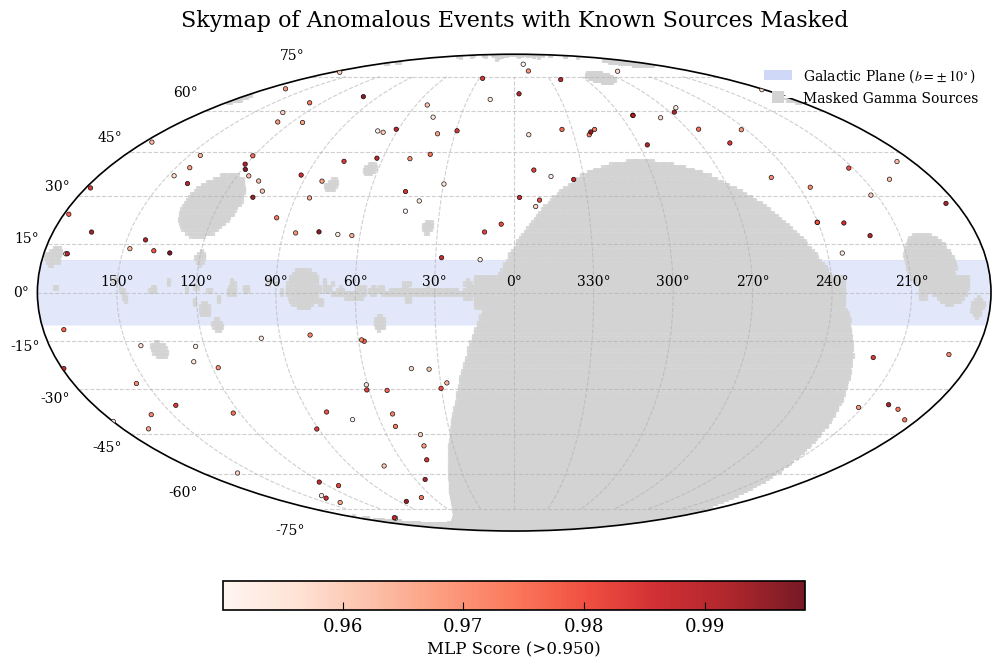

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# ==========================================
# 1. 提取异常数据 (与之前相同)
# ==========================================
# 假设 df_anomaly 已经准备好
df_nornal = exp_final[exp_final['mlp_score'] <= 0.95]
df_anomaly = exp_final[exp_final['mlp_score'] > 0.950]
# plt.scatter(df_anomaly['rec_theta']*180/np.pi, df_anomaly['rec_phi']*180/np.pi, c=df_anomaly['mlp_score'], cmap='Reds', s=20, alpha=0.9, edgecolors='k', linewidths=0.5)
# plt.xlabel('Reconstructed Theta (deg)')
# plt.ylabel('Reconstructed Phi (deg)')
# plt.title('Anomalous Events (MLP Score > 0.950)')
# plt.colorbar(label='MLP Score')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

# plt.scatter(df_nornal['rec_theta'], df_nornal['Eage'], c=df_nornal['mlp_score'], cmap='Blues', s=20, alpha=0.9, edgecolors='k', linewidths=0.5)
# plt.scatter(df_anomaly['rec_theta'], df_anomaly['Eage'], c=df_anomaly['mlp_score'], cmap='Reds', s=20, alpha=0.9, edgecolors='k', linewidths=0.5)

# plt.xlabel('Reconstructed Theta (rad)')
# plt.ylabel('Reconstructed Age')
# plt.title('Anomalous Events (MLP Score > 0.950)')
# # plt.colorbar(label='MLP Score')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

plt.hist(df_nornal['R_ue'], bins=50, range=(-8,-2.5), histtype='step', alpha=1, label='Normal', color='blue')
plt.hist(df_anomaly['R_ue'], bins=50, range=(-8,-2.5), histtype='step', alpha=1, label='Anomalous', color='red')
plt.xlabel('R_ue')
plt.ylabel('Counts')
plt.title('Anomalous Events (MLP Score > 0.950)')
plt.legend()
plt.yscale('log')
plt.grid(True, linestyle='--')
plt.show()

l_deg = df_anomaly['tlong'].values
b_deg = df_anomaly['tlat'].values
scores = df_anomaly['mlp_score'].values

# ==========================================
# 2. 读取 ROOT 文件，提取 Mask 的边界点
# ==========================================
root_file_path = "/data/home/zzh/data/modelB_GCS_km2a.root"  # ⚠️ 请替换为你的实际 ROOT 文件路径
hist_name = "h2_galactic"            # ⚠️ 请替换为 ROOT 文件里那张图的名字 (例如 "h2_mask")

with uproot.open(root_file_path) as f:
    h2 = f[hist_name]
    
    # 提取二维直方图的 Bin 边界和内容
    # h2.values() 返回的是一个二维 numpy 数组
    content = h2.values()
    
    # 提取 X (tlong) 和 Y (tlat) 的 bin edges
    # 注意 uproot 里的 axis(0) 通常是 X 轴，axis(1) 是 Y 轴
    x_edges = h2.axis(0).edges()
    y_edges = h2.axis(1).edges()
    
    # 计算每个 Bin 的中心坐标
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2.0
    
    # 找到被 Mask 的区域。
    # 假设你的图里，被挖掉的区域值为 0 (或者某些极端小值)
    # 如果背景不是 0，请根据实际情况修改条件，比如 content == 0
    mask_indices = np.where(content == 0)
    
    # 提取被 mask 掉的坐标
    mask_l_deg = x_centers[mask_indices[0]]
    mask_b_deg = y_centers[mask_indices[1]]


# ==========================================
# 3. 坐标转换预处理 (Mollweide 需要弧度)
# ==========================================
# 转换异常数据坐标
l_rad = np.radians(l_deg)
b_rad = np.radians(b_deg)
l_rad = np.remainder(l_rad + np.pi, 2 * np.pi) - np.pi
l_rad = -l_rad  

# 转换 Mask 区域坐标
mask_l_rad = np.radians(mask_l_deg)
mask_b_rad = np.radians(mask_b_deg)
mask_l_rad = np.remainder(mask_l_rad + np.pi, 2 * np.pi) - np.pi
mask_l_rad = -mask_l_rad


# ==========================================
# 4. 创建画布和投影开始画图
# ==========================================
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')

# 画银纬 +/- 10 度的背景带
ax.axhspan(np.radians(-10), np.radians(10), color='royalblue', alpha=0.15, zorder=0)

# 【重点新增】：画出被 Mask 的区域
# 因为 mask 的点可能非常多（0.1度一个pixel），我们用浅灰色的小点把挖掉的区域填满
ax.scatter(mask_l_rad, mask_b_rad, 
           c='lightgray', s=5, marker='s', alpha=0.8, zorder=1, label='Masked Regions')

# 绘制异常数据散点图
scatter = ax.scatter(l_rad, b_rad, c=scores, cmap='Reds', s=10, alpha=0.9, edgecolors='k', linewidths=0.5, zorder=3)

# 设置网格
x_ticks_deg = np.arange(-150, 151, 30)
ax.set_xticks(np.radians(x_ticks_deg))
y_ticks_deg = np.arange(-75, 76, 15)
ax.set_yticks(np.radians(y_ticks_deg))
ax.grid(True, linestyle='--', alpha=0.6, zorder=2)

xtick_labels = []
for t in x_ticks_deg:
    orig_l = -t
    if orig_l < 0: orig_l += 360
    xtick_labels.append(f"{orig_l}°")
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_yticklabels([f"{y}°" for y in y_ticks_deg], fontsize=10)


# ==========================================
# 5. 添加颜色条和自定义图例
# ==========================================
cbar = plt.colorbar(scatter, orientation='horizontal', shrink=0.5, pad=0.08)
cbar.set_label('MLP Score (>0.950)', fontsize=12)

# 自定义双重图例：蓝色带子 + 灰色 Mask 区域
legend_elements = [
    Patch(facecolor='royalblue', alpha=0.25, label='Galactic Plane ($b = \pm10^\circ$)'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgray', markersize=8, label='Masked Gamma Sources')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.title('Skymap of Anomalous Events with Known Sources Masked', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

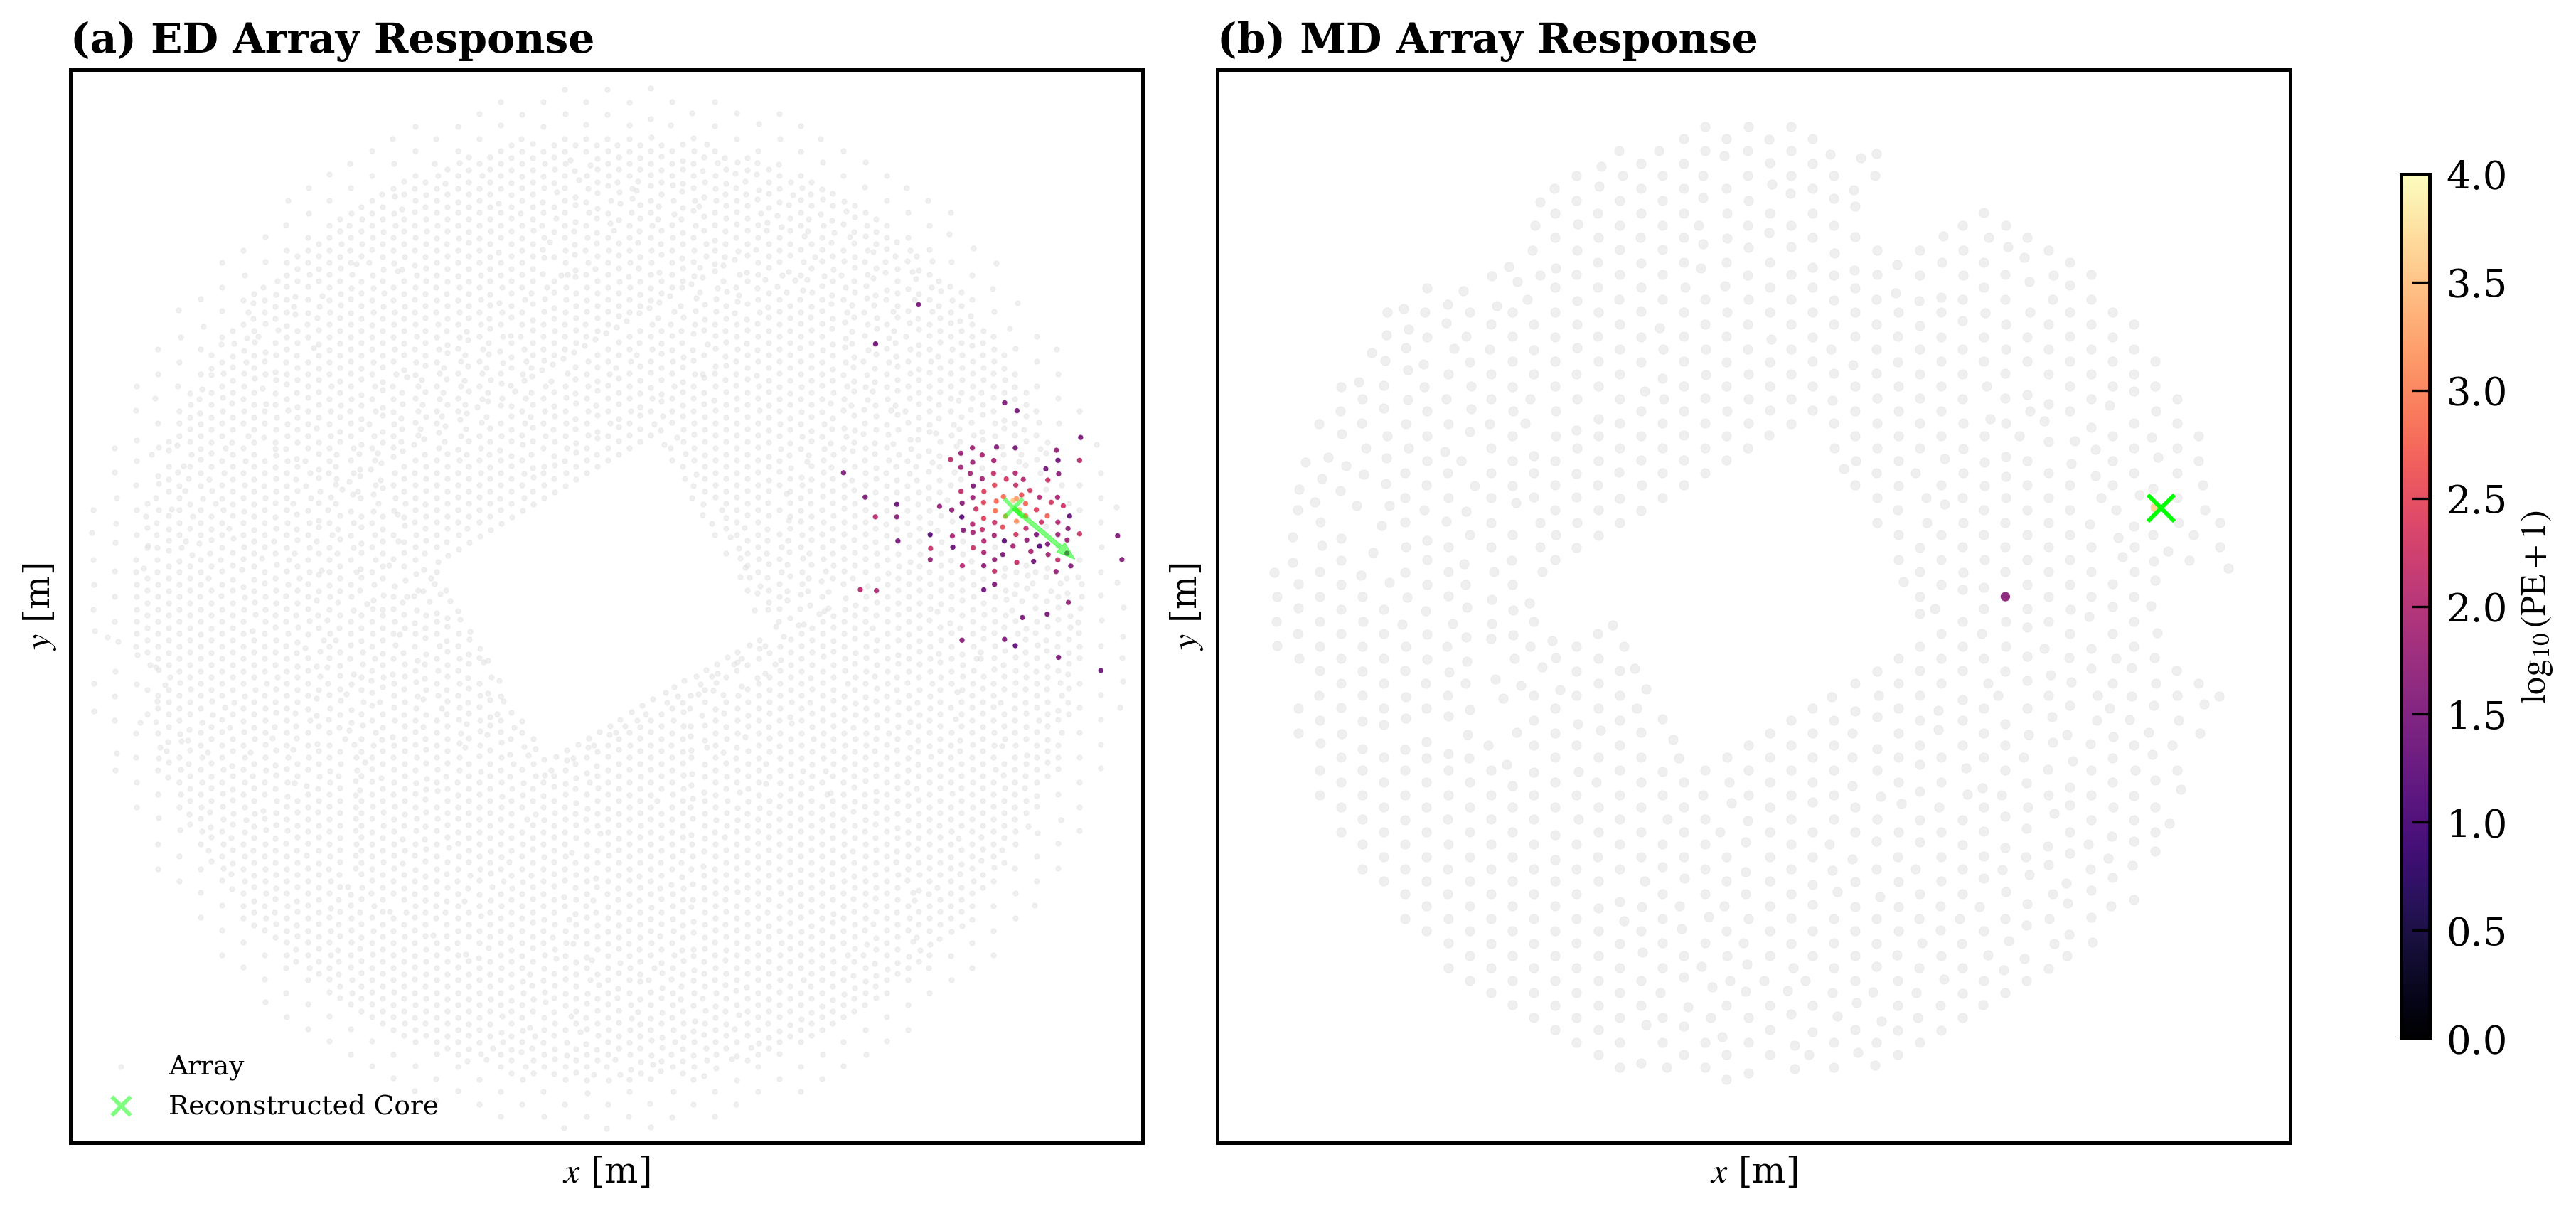

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=7, figpath=None):
    
    
    # 配置学术字体
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["mathtext.fontset"] = "stix"
    
        
        
    def load_pos(flag:int):
        ED_pos_file = None
        MD_pos_file = None
        script_dir = "/data/home/zzh/Filt_Event"
        if flag==7:
            ED_pos_file=f'{script_dir}/config/ED_pos_all.txt'
            MD_pos_file=f'{script_dir}/config/MD_pos_all.txt'
        else:
            MD_pos_file=f'{script_dir}/config/MD_pos_1188.txt'
            if 20191224 < flag < 20201201:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_half.txt'
            elif 20201130 < flag < 20210720:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_3978.txt'
            elif 20210719 < flag < 20210807:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210720.txt'
            elif 20210806 < flag < 20220526:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210807.txt'
            elif 20220525 < flag < 20220601:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220520.txt'
            elif 20220531 < flag < 20220705:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220601.txt'
            elif 20220704 < flag < 20221118:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220705.txt'
            elif 20221117 < flag < 20230504:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20221118.txt'
            elif 20230503 < flag < 20230619:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230504.txt'
            elif 20230618 < flag < 20230913:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230619.txt'
            elif 20230912 < flag < 20231008:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230913.txt'
            elif 20231007 < flag < 20241021:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20231008.txt'
            elif 20241020 < flag < 20250617:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20241021.txt'
            elif flag > 20250616:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20250617.txt'
            else:
                # 增加一个容错处理，防止传入的 flag 刚好落在边界或非法范围外导致 ED_pos_file 未定义
                raise ValueError(f"输入的 flag ({flag}) 不在任何已知的坐标配置时间段内，请检查！")
        
        if ED_pos_file is not None:
            if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
                ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                for col in ['x', 'y', 'z']:
                    ED_pos[col] = pd.to_numeric(ED_pos[col], errors='coerce')
                    MD_pos[col] = pd.to_numeric(MD_pos[col], errors='coerce')

                return ED_pos,MD_pos
        else:

            raise ValueError("wrong flag")
    
    
    
    # 1. 加载阵列位置
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取数据
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头 (转换坐标系或方向)
    # 这里的 dx, dy 逻辑保持原样，但增加 arrow_width 的美化
    arrow_len = 220
    dx = -np.sin(theta) * np.sin(phi) * arrow_len
    dy = np.sin(theta) * np.cos(phi) * arrow_len

    # 4. 开始绘图
    # 使用 constrained_layout 替代 tight_layout，能更好地处理 colorbar 间距
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True, dpi=300)
    
    # 公用的绘图参数
    scatter_kwargs = {
        'cmap': 'magma', # 更有科研质感的渐变色
        'vmin': 0, 
        'vmax': 4,       # 固定 log10(PE) 范围，方便左右对比
        'edgecolors': 'none'
    }

    # --- 左图：ED Hits ---
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='#E0E0E0', s=3, alpha=0.5, label='Array', zorder=1)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      s=3, zorder=3, **scatter_kwargs)
    
    # 核心位置与箭头
    ax1.scatter(core[0], core[1], c='#00FF00', s=40, marker='x', label='Reconstructed Core', zorder=10, alpha=0.5)
    ax1.arrow(core[0], core[1], dx, dy, color='#00FF00', width=5, head_width=15, alpha=0.5 ,
              length_includes_head=True, zorder=11)
    
    ax1.set_title('(a) ED Array Response', fontsize=14, loc='left', fontweight='bold')

    # --- 右图：MD Hits ---
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='#E0E0E0', s=10, alpha=0.5, zorder=1)
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      s=10, zorder=3, **scatter_kwargs)
    
    ax2.scatter(core[0], core[1], c='#00FF00', s=80, marker='x', zorder=10)
    
    ax2.set_title('(b) MD Array Response', fontsize=14, loc='left', fontweight='bold')

    # 设置统一的 Colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], location='right', aspect=30, shrink=0.8)
    cbar.set_label(r'$\log_{10}(\text{PE} + 1)$', fontsize=12)

    # 坐标轴细节优化
    for i, ax in enumerate([ax1, ax2]):
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ [m]', fontsize=12)
        ax.set_ylabel('$y$ [m]', fontsize=12)
        ax.set_xlim(-650, 650)
        ax.set_ylim(-650, 650)
        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
        if i == 0: ax.legend(loc='lower left', fontsize=9, framealpha=0.8)
    for ax in [ax1, ax2]:
        ax.set_xticks([]) # 取消 x 轴刻度和数字
        ax.set_yticks([])
    # 如果需要保存
    if figpath:
        plt.savefig(figpath, bbox_inches='tight', dpi=300)
    plt.show()

# 调用
# event_plot_npz_formal(0, hitsE, hitsM, mn_df, flag=7, figpath="event_display.pdf")
mn_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/1e10_V04_2023_ALL_MERGED.npz"
mn_data = np.load(mn_file, allow_pickle=True)
hitsE = mn_data['hitsE']; hitsM = mn_data['hitsM']; mn_df = pd.DataFrame(mn_data['params'], columns=mn_data['param_names'][:32])

event_plot_npz(160056, hitsE, hitsM, mn_df, flag=20230101)





>>> Generating Publication-Quality Plot with Corrected Error Bars...


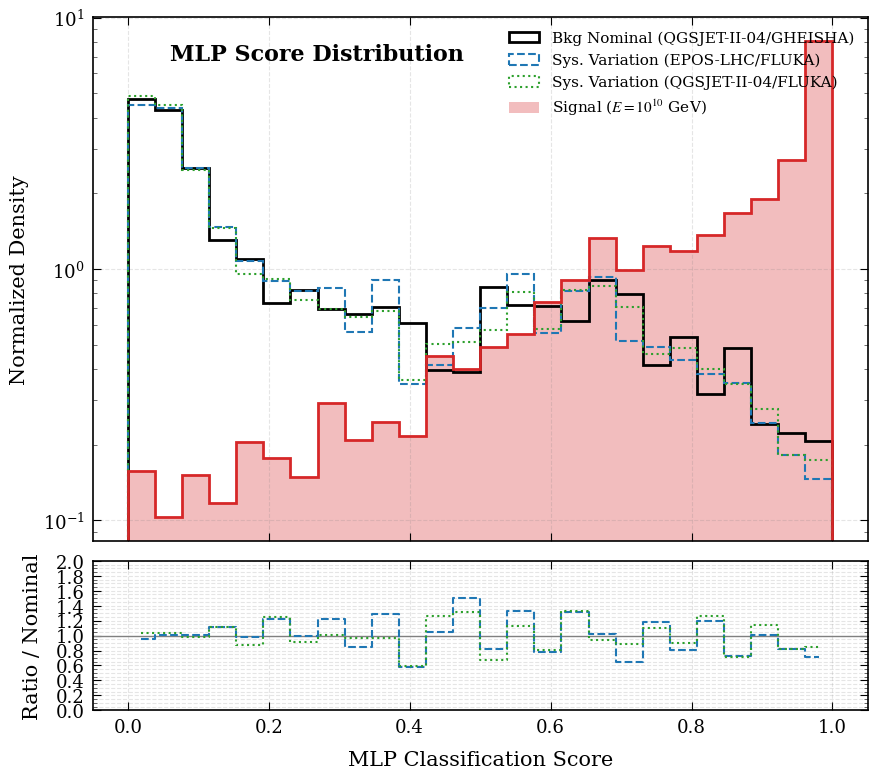


>>> Plotting Evaluation Metrics...


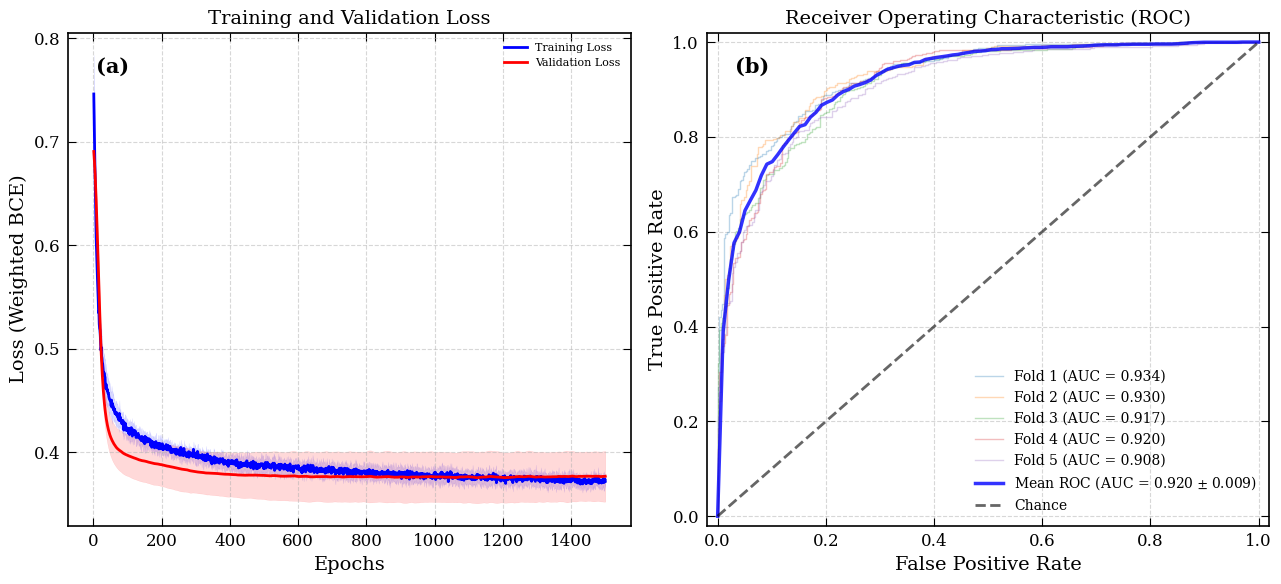

In [17]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格 (可选，如果没有安装 latex 可以注释掉 usetex=True)
def plot_training_evaluation(manager, output_dir="."):
    """
    绘制 Loss 曲线和 ROC 曲线
    """
    # 设置学术风格
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    
    # ==========================================
    # 1. Loss Curve (Mean +/- Std)
    # ==========================================
    ax1 = axes[0]
    if manager.model_type == 'mlp' and manager.loss_histories:
        # 获取所有 fold 的 loss
        train_losses = np.array([h['train'] for h in manager.loss_histories])
        val_losses = np.array([h['val'] for h in manager.loss_histories])
        
        # 计算均值和标准差
        mean_train = np.mean(train_losses, axis=0)
        std_train = np.std(train_losses, axis=0)
        mean_val = np.mean(val_losses, axis=0)
        std_val = np.std(val_losses, axis=0)
        epochs = range(1, len(mean_train) + 1)
        
        # 绘图
        ax1.plot(epochs, mean_train, 'b-', label='Training Loss', lw=2)
        ax1.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='b', alpha=0.15)
        
        ax1.plot(epochs, mean_val, 'r-', label='Validation Loss', lw=2)
        ax1.fill_between(epochs, mean_val - std_val, mean_val + std_val, color='r', alpha=0.15)
        
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss (Weighted BCE)')
        ax1.text(0.05, 0.95, '(a)',  transform=ax1.transAxes, fontsize=15, fontweight='bold', va='top')
        ax1.set_title('Training and Validation Loss')
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, 'Loss history available only for MLP', ha='center', transform=ax1.transAxes)

    # ==========================================
    # 2. ROC Curve (K-Fold Mean)
    # ==========================================
    ax2 = axes[1]
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # 绘制每一折的 ROC
    for i, (y_true, y_score) in enumerate(manager.fold_roc_data):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值以便计算平均
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        # 绘制浅色细线
        ax2.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')
        
    # 绘制平均 ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax2.plot(mean_fpr, mean_tpr, color='b', label=rf'Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})', lw=2.5, alpha=0.8)
    
    # 绘制对角线
    ax2.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance', alpha=0.6)
    
    ax2.set_xlim([-0.02, 1.02])
    ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Receiver Operating Characteristic (ROC)')
    ax2.text(0.05, 0.95, '(b)',  transform=ax2.transAxes, fontsize=15, fontweight='bold', va='top')
    ax2.legend(loc="lower right", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    fig.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_model_evaluation_metrics.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    # 如果需要保存
   


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格：Times New Roman 字体，向内的刻度
plt.rcParams.update({
    'font.family': 'serif',
    "font.serif": [ "DejaVu Serif", "serif"],
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,  # 去掉图例边框
    'figure.figsize': (10, 8),
    'axes.linewidth': 1.2     # 边框加粗
})

class Plotter:
    # 更加稳重、对比度高的学术配色
    COLORS = {
        'bkg_nom': 'black',      # 基准背景：纯黑实线
        'sys_1':   '#1f77b4',    # 系统误差1：深蓝
        'sys_2':   '#2ca02c',    # 系统误差2：深绿
        'signal':  '#d62728',    # 信号：深红
        'data':    'black'       # 数据：黑点
    }
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="Classification Score Distribution"):
        # 1. 创建画布：上图（分布）+ 下图（比值）
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), 
                                       gridspec_kw={'height_ratios': [3.5, 1]}, 
                                       sharex=True)
        
        # 调整子图间距
        plt.subplots_adjust(hspace=0.06)
        
        hists = []     # 存储各组的高度（density）
        raw_counts_list = [] # 存储各组的原始事例数（用于误差计算）
        edges = None
        bin_centers = None
        
        # 定义绘图样式
        styles = [
            {'c': Plotter.COLORS['bkg_nom'], 'ls': '-',  'lw': 2.0, 'zorder': 10, 'type': 'Step', 'label': 'Line'},
            {'c': Plotter.COLORS['sys_1'],   'ls': '--', 'lw': 1.5, 'zorder': 5,  'type': 'Step', 'label': 'Line'},
            {'c': Plotter.COLORS['sys_2'],   'ls': ':',  'lw': 1.5, 'zorder': 5,  'type': 'Step', 'label': 'Line'},
            {'c': Plotter.COLORS['signal'],  'ls': '-',  'lw': 2.0, 'zorder': 8,  'type': 'Fill', 'label': 'Fill'},
            {'c': Plotter.COLORS['data'],    'ls': '',   'lw': 1.5, 'zorder': 20, 'type': 'Data', 'label': 'Errorbar'} 
        ]

        # =========================================================
        # 1. 主图循环：绘制分布
        # =========================================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            style = styles[i % len(styles)]
            
            # --- 核心修正步骤 ---
            
            # A. 计算用于画图的高度 (加权，Density=True)
            h, bin_edges = np.histogram(df['mlp_score'], bins=bins, range=(0, 1), weights=w, density=True)
            
            # B. 计算原始事例数 (不加权，用于计算统计误差)
            raw_n, _ = np.histogram(df['mlp_score'], bins=bins, range=(0, 1))
            
            if edges is None: 
                edges = bin_edges
                bin_centers = 0.5 * (edges[:-1] + edges[1:])
            
            hists.append(h)
            raw_counts_list.append(raw_n)
            
            # C. 绘图逻辑
            if style['type'] == 'Data':
                # === 数据点：误差棒计算 ===
                # 相对误差 = 1 / sqrt(N_raw)
                # 绝对误差 = y_density * 相对误差
                with np.errstate(divide='ignore', invalid='ignore'):
                    rel_err = 1.0 / np.sqrt(raw_n)
                    y_err = h * rel_err
                y_err = np.nan_to_num(y_err) # 处理 N=0 的情况
                
                # 过滤掉 0 计数点，不画出来
                mask = raw_n > 0
                ax1.errorbar(bin_centers[mask], h[mask], yerr=y_err[mask], 
                             fmt='o', color='black', markersize=4, 
                             capsize=2, elinewidth=1.2, label=label)
                
            elif style['type'] == 'Fill':
                # === 信号：填充样式 ===
                ax1.hist(bin_centers, bins=edges, weights=h, 
                         histtype='stepfilled', color=style['c'], alpha=0.3, label=label)
                # 叠加轮廓线
                ax1.hist(bin_centers, bins=edges, weights=h, 
                         histtype='step', color=style['c'], lw=2)
                
            else:
                # === 背景/系统误差：阶梯线 ===
                ax1.hist(bin_centers, bins=edges, weights=h, 
                         histtype='step', color=style['c'], linestyle=style['ls'], 
                         linewidth=style['lw'], label=label)

        # 主图修饰
        ax1.set_ylabel(r'Normalized Density', labelpad=10)
        ax1.set_yscale('log')
        # ax1.set_ylim(bottom=1e-3, top=1e2) # 根据实际数据调整下限，防止log报错
        
        # 标题放在图内上方或顶部
        # ax1.set_title(title, pad=15, fontsize=16, weight='bold') 
        ax1.text(0.1, 0.95, title, transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top')

        # 图例
        ax1.legend(loc='upper right', ncol=1)
        ax1.grid(True, which='major', linestyle='--', alpha=0.2, color='gray')

        # =========================================================
        # 2. 子图循环：绘制比值 (Ratio Plot)
        # =========================================================
        ref_h = hists[0] # 以第一个数据集（Nominal Background）为分母
        ref_raw = raw_counts_list[0]
        
        # 绘制参考线 1.0
        ax2.axhline(1, color='gray', linestyle='-', linewidth=1)
        
        # 绘制 Nominal 背景的统计误差带 (灰色阴影)
        with np.errstate(divide='ignore', invalid='ignore'):
            # Nominal 的相对误差
            ref_rel_err = 1.0 / np.sqrt(ref_raw)
            ref_rel_err = np.nan_to_num(ref_rel_err)
        # ax2.fill_between(bin_centers, 1 - ref_rel_err, 1 + ref_rel_err, 
        #                  color='gray', alpha=0.3, label='Bkg Stat. Unc.')

        for i in range(1, len(hists)):
            # 跳过信号的 Ratio
            if 'Signal' in labels[i] or 'signal' in labels[i].lower():
                continue
                
            style = styles[i % len(styles)]
            current_h = hists[i]
            current_raw = raw_counts_list[i]
            
            # 计算 Ratio
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = current_h / ref_h
            
            # 过滤无效点
            valid_mask = (ref_h > 0) & (current_h > 0)
            
            if style['type'] == 'Data':
                # 数据点的 Ratio 误差
                # Ratio Error = Ratio * sqrt( (1/N_data) + (1/N_mc) ) 
                # 这里简化：假设 MC 统计量足够大，误差主要来自数据
                with np.errstate(divide='ignore'):
                    ratio_err = ratio * (1.0 / np.sqrt(current_raw))
                ratio_err = np.nan_to_num(ratio_err)
                
                ax2.errorbar(bin_centers[valid_mask], ratio[valid_mask], yerr=ratio_err[valid_mask],
                             fmt='o', color='black', markersize=4, capsize=0)
            else:
                # 系统误差线
                ax2.step(bin_centers[valid_mask], ratio[valid_mask], where='mid', 
                         color=style['c'], linestyle=style['ls'], linewidth=1.5)

        # 子图修饰
        ax2.set_xlabel(r'MLP Classification Score', labelpad=10)
        ax2.set_ylabel('Ratio / Nominal', labelpad=10)
        
        # 设置 Ratio 轴范围 (例如 0.5 到 1.5，根据需要调整)
        ax2.set_ylim(0.0, 2)
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2)) # 设置刻度间隔
        ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
        
        ax2.grid(True, which='both', linestyle='--', alpha=0.2, color='gray')
        plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_MLP_Score_Distribution_Models.pdf", dpi=300, bbox_inches='tight', pad_inches=0.1)
        # 显示图片
        plt.show()

# ==========================================
# 调用部分
# ==========================================
# 准备数据exp_final
dfs_to_plot = [bkg_train_final, pseudo_ef_final, pseudo_qf_final, sig_train_final, ]

# 使用 LaTeX 格式的标签 (如果在非 LaTeX 环境，去除 $ 符号即可)
labels = [
    r'Bkg Nominal (QGSJET-II-04/GHEISHA)', 
    r'Sys. Variation (EPOS-LHC/FLUKA)', 
    r'Sys. Variation (QGSJET-II-04/FLUKA)', 
    r'Signal ($E = 10^{10}$ GeV)', 
    r'Exp. Data (LHAASO-2024)'
]

weights = [
    bkg_train_final[TARGET_FLUX], 
    pseudo_ef_final[TARGET_FLUX], 
    pseudo_qf_final[TARGET_FLUX], 
    sig_train_final['weight'], 
    # exp_final['weight']
]
print("\n>>> Generating Publication-Quality Plot with Corrected Error Bars...")
Plotter.plot_score(dfs_to_plot, labels, weights, title="MLP Score Distribution",bins=26)
print("\n>>> Plotting Evaluation Metrics...")
plot_training_evaluation(manager)


/data/home/zzh/miniconda3/envs/root_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Preparing data (Vectorized)...
Binning data into 2D histogram (Grid size: [201, 51] )...
--------------------------------------------------
Optimization Done (2 params).
Max Significance: 2.9541
Signal: 3.48e+02 | Background: 1.38e+04
Best Cuts: {'R_ue': -2.8400000000000247, 'recE': 1.9600000000000002}
Generating result DataFrame...


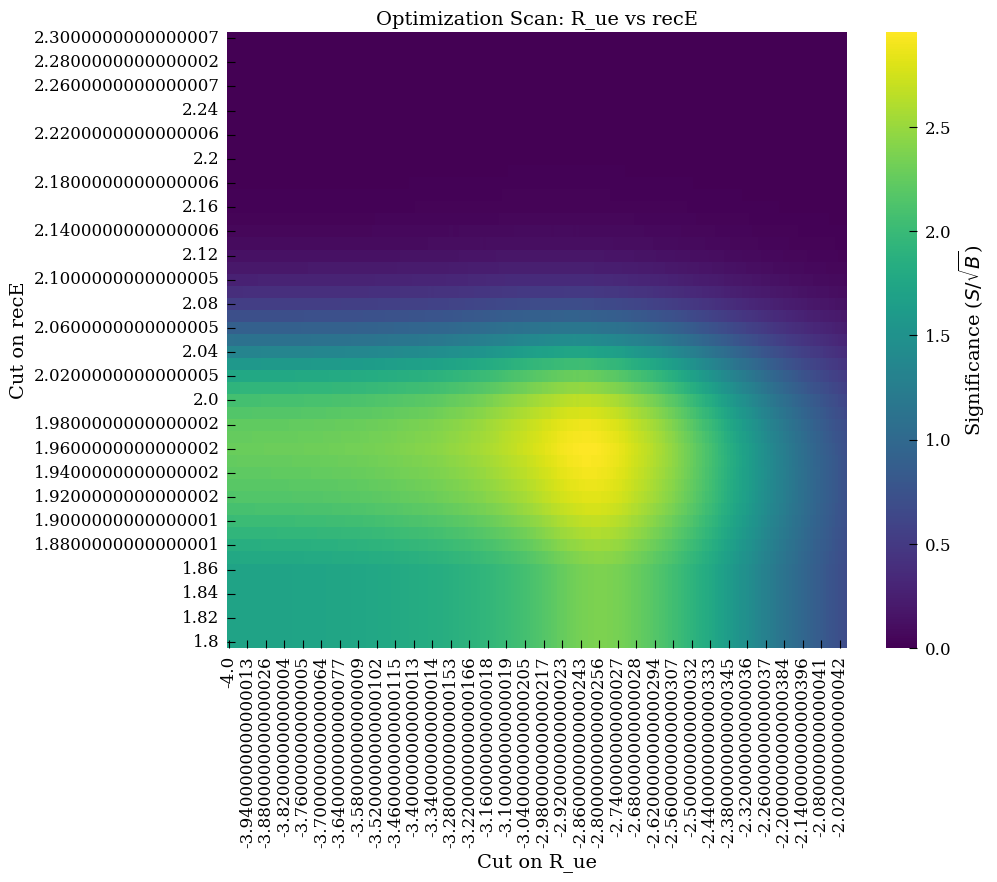

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import itertools

def optimize_cuts_vectorized(df_signal, df_background, search_ranges, fixed_query=None):
    """
    极速优化的多参数切割搜索函数。
    支持任意数量的参数。使用直方图+累积求和技术，比循环快 100-1000 倍。
    
    参数:
    res_df -- (输出) 包含所有网格点计算结果的 DataFrame
    """
    # --- 1. 数据预处理 ---
    print("Preparing data (Vectorized)...")
    
    # 预筛选
    if fixed_query:
        s_df = df_signal.query(fixed_query)
        b_df = df_background.query(fixed_query)
    else:
        s_df = df_signal
        b_df = df_background

    scale = 365 * 86400
    # 获取权重 (处理可能的列名差异)
    ws = (s_df['gaisser_weight'].values if 'gaisser_weight' in s_df else s_df['weight'].values) * scale
    wb = b_df['weight'].values * scale

    # 提取参数名和配置
    param_names = list(search_ranges.keys())
    n_params = len(param_names)
    
    # --- 2. 构建 N维 直方图网格 ---
    # 我们需要构建 bin_edges，为了确保统计正确（包含小于start或大于stop的数据），
    # 我们在两端扩展无穷大区间。
    
    bins_list = []
    grids_map = {} # 用于存储真实的切点值，方便后续还原
    operators = []
    
    # 准备直方图数据容器
    sample_s = np.zeros((len(ws), n_params))
    sample_b = np.zeros((len(wb), n_params))
    
    for i, p in enumerate(param_names):
        start, stop, step, op = search_ranges[p]
        operators.append(op)
        
        # 提取数据列
        sample_s[:, i] = s_df[p].values
        sample_b[:, i] = b_df[p].values
        
        # 生成切点网格 (用户定义的搜索点)
        # 注意：np.arange 通常不包含 stop，加一个小量确保包含
        grid = np.arange(start, stop + step/1000.0, step)
        grids_map[p] = grid
        
        # 构建直方图边缘 (Edges)
        # 原理：如果切点是 v，op是 '<'，意味着我们要统计 (-inf, v) 
        # 为了利用 cumsum，我们将 grid 作为 bin 的右边缘 (对于 <) 或 左边缘 (对于 >)
        # 这里为了通用，我们构建极其精细的 bins，或者简单地将 grid 点作为 bin edges
        
        # 技巧：我们将 grid 点作为 bin 的边缘。
        # 并在首尾加上 -inf 和 inf 来捕获所有溢出数据
        edges = np.concatenate([[-np.inf], grid, [np.inf]])
        bins_list.append(edges)

    print(f"Binning data into {n_params}D histogram (Grid size: {[len(g) for g in grids_map.values()]} )...")
    
    # --- 3. 核心加速：加权直方图 ---
    # 计算信号和本底在网格中的分布
    # histogramdd 返回的 H 是多维数组，形状为 (len(grid)+1, len(grid)+1, ...)
    H_s, _ = np.histogramdd(sample_s, bins=bins_list, weights=ws)
    H_b, _ = np.histogramdd(sample_b, bins=bins_list, weights=wb)
    
    # --- 4. 核心加速：多维累积求和 (CumSum) ---
    # 根据操作符方向计算“保留下来的”事件总权重
    
    # 这一步将 概率密度(PDF) 转换为 累积分布(CDF) 也就是 Cut后的保留量
    current_S = H_s
    current_B = H_b
    
    for axis_idx, op in enumerate(operators):
        if op == '<':
            # 如果是 < cut，我们保留小的值。
            # 在直方图中，这意味着从左向右累加 (cumsum)
            # bin[0] 是 -inf 到 grid[0]，保留它意味着 cut 在 grid[0]
            # 累加后，index i 的值代表 sum(bin[0]...bin[i])，即 cut < edges[i+1]
            current_S = np.cumsum(current_S, axis=axis_idx)
            current_B = np.cumsum(current_B, axis=axis_idx)
            
        elif op == '>':
            # 如果是 > cut，我们保留大的值。
            # 这意味着从右向左累加。
            # numpy 没有直接的 reverse cumsum，我们先 flip 轴，cumsum，再 flip 回来
            current_S = np.flip(np.cumsum(np.flip(current_S, axis=axis_idx), axis=axis_idx), axis=axis_idx)
            current_B = np.flip(np.cumsum(np.flip(current_B, axis=axis_idx), axis=axis_idx), axis=axis_idx)

    # --- 5. 提取有效网格区域 ---
    # 我们的 edges 是 [-inf, g0, g1, ... gn, inf]
    # 直方图 H 的形状是 (n_grid + 1)
    # 对于 '<':
    #   H[0] 是 (-inf, g0)。cumsum 后 H[0] 代表 < g0 的总和。
    #   H[1] 是 (g0, g1)。cumsum 后 H[1] 代表 < g1 的总和。
    #   我们需要的切点对应的值正好是 index 0 到 n-1
    # 对于 '>':
    #   H[last] 是 (gn, inf)。 cumsum(from right) 后 H[last] 代表 > gn 的总和。
    #   我们需要对齐 grid。
    
    # 为了对齐 grid 和 数组索引，我们需要切片 (Slicing)
    slices = []
    for axis_idx, op in enumerate(operators):
        n_grid = len(grids_map[param_names[axis_idx]])
        if op == '<':
            # index 0 对应 cut < grid[0]
            # index n-1 对应 cut < grid[n-1]
            # 最后一个 bin 是 (grid[last], inf)，无论是 < 还是 > 逻辑，通常 cut 扫描不包含无穷大
            slices.append(slice(0, n_grid)) 
        else:
            # op == '>'
            # edges: [-inf, g0, g1, ... gn, inf]
            # bins:  b0,   b1, ...      bn,  bn+1
            # b0=(-inf, g0), bn=(gn-1, gn), bn+1=(gn, inf)
            # Reverse Cumsum 后:
            # H[n+1] = sum(bn+1) -> > gn
            # H[n]   = sum(bn+1, bn) -> > gn-1
            # H[1]   = sum(..., b1) -> > g0
            # 所以 grid[0] (g0) 对应 H[1]
            slices.append(slice(1, n_grid + 1))

    # 应用切片，使矩阵维度与 grid 维度完全一致
    final_S = current_S[tuple(slices)]
    final_B = current_B[tuple(slices)]
    
    # --- 6. 计算显著性 ---
    with np.errstate(divide='ignore', invalid='ignore'):
        sig_matrix = final_S / np.sqrt(final_B)
        sig_matrix[final_B <= 0] = 0 # 处理除零
        sig_matrix[np.isnan(sig_matrix)] = 0

    # --- 7. 寻找最佳点并格式化输出 ---
    # 找到最大值的索引（扁平化索引）
    best_idx_flat = np.argmax(sig_matrix)
    # 转换回多维索引
    best_idx_tuple = np.unravel_index(best_idx_flat, sig_matrix.shape)
    
    best_sig = sig_matrix[best_idx_tuple]
    best_S = final_S[best_idx_tuple]
    best_B = final_B[best_idx_tuple]
    
    best_cuts = {}
    for i, p in enumerate(param_names):
        idx = best_idx_tuple[i]
        val = grids_map[p][idx]
        best_cuts[p] = val

    print("-" * 50)
    print(f"Optimization Done ({n_params} params).")
    print(f"Max Significance: {best_sig:.4f}")
    print(f"Signal: {best_S:.2e} | Background: {best_B:.2e}")
    print(f"Best Cuts: {best_cuts}")
    
    # --- 8. 生成结果 DataFrame (为了画图) ---
    # 如果网格非常大，生成全量 DataFrame 会很慢。
    # 这里我们生成坐标网格，然后展平
    print("Generating result DataFrame...")
    
    # 使用 meshgrid 生成所有坐标组合
    # indexing='ij' 确保维度顺序与 matrix 一致
    coords = np.meshgrid(*[grids_map[p] for p in param_names], indexing='ij')
    
    # 展平所有数据
    flat_data = {}
    for i, p in enumerate(param_names):
        flat_data[p] = coords[i].ravel()
    
    flat_data['S'] = final_S.ravel()
    flat_data['B'] = final_B.ravel()
    flat_data['significance'] = sig_matrix.ravel()
    
    res_df = pd.DataFrame(flat_data)
    
    # 过滤掉无意义的数据减小体积 (可选)
    # res_df = res_df[res_df['significance'] > 0] 

    return best_cuts, res_df

def plot_optimization_heatmap(res_df, param_x, param_y, fixed_param=None, fixed_val_approx=None):
    """
    通用画图函数：支持任意两个参数的热力图，可选择是否固定第三个参数
    """
    df_plot = res_df.copy()
    
    title_extra = ""
    
    # 如果指定了固定参数，进行筛选
    if fixed_param and fixed_val_approx is not None:
        # 自动推断步长做 tolerance，如果没有步长信息，默认 0.001
        # 这里简单处理，取 unique 值的最小差值的一半
        unique_vals = np.sort(df_plot[fixed_param].unique())
        if len(unique_vals) > 1:
            step = np.min(np.diff(unique_vals))
            tolerance = step / 2.0
        else:
            tolerance = 1e-5
            
        mask = np.abs(df_plot[fixed_param] - fixed_val_approx) < tolerance
        df_plot = df_plot[mask]
        title_extra = f"\nFixed {fixed_param} $\\approx$ {fixed_val_approx:.2f}"
        
        if len(df_plot) == 0:
            print(f"Warning: No data found for {fixed_param} approx {fixed_val_approx}")
            return

    # 聚合：如果除了 param_x, param_y 还有其他变动的参数（未被固定），
    # 我们通常取这些未固定参数下的 最大显著性 (Best profile)
    # 也就是：在 X, Y 确定的情况下，其他参数调到最优时的结果
    pivot_table = df_plot.pivot_table(index=param_y, columns=param_x, values='significance', aggfunc='max')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=False, cmap="viridis", cbar_kws={'label': r'Significance ($S/\sqrt{B}$)'})
    
    # 标出最大值位置
    # 找到最大值的坐标
    max_val = pivot_table.max().max()
    # 注意：这里仅仅是可视化标点，实际数值应参考 optimize_cuts 的返回值
    
    plt.title(f"Optimization Scan: {param_x} vs {param_y}{title_extra}")
    plt.xlabel(f"Cut on {param_x}")
    plt.ylabel(f"Cut on {param_y}")
    plt.gca().invert_yaxis()
    plt.show()

# --- 使用示例 ---

# 1. 定义任意参数 (只需修改字典)
# 注意：即使只有一个参数，或者有5个参数，代码都不需要改动
ranges_new = {
    "R_ue":   (-4.0, -2.0, 0.01, '<'), 
    "recE": (1.8, 2.3, 0.01, '>'),
    # "Eage":   (1,  1.2,  0.02, '<'), 
    # "R_mean": (10,   60,   2.0,  '>'),
    # 你甚至可以加第四个参数：
    # "Zenith": (0,    60,   5.0,  '<') 
}

# 2. 运行优化
# mn_df_large 和 exp_muon_Rue_df_all_large 需替换为你实际的 DataFrame 变量名
best_cuts, res_df = optimize_cuts_vectorized(
    mn_df_large, 
    exp_muon_Rue_df_all_large, 
    ranges_new, 
    # fixed_query="2.85 < recE < 3.15"
)

# 3. 画图
# 场景 A: 3个参数，固定 R_mean 画 R_ue vs Eage
plot_optimization_heatmap(res_df, "R_ue", "recE")



# Preparing data (Vectorized)...
# Binning data into 2D histogram (Grid size: [101, 31] )...
# --------------------------------------------------
# Optimization Done (2 params).
# Max Significance: 100.2440
# Signal: 2.85e+02 | Background: 8.09e+00
# Best Cuts: {'R_ue': np.float64(-2.770000000000005), 'recE': np.float64(2.9199999999999986)}
# Generating result DataFrame...

In [31]:
print(mn_df_large['weight'].sum() * 365 * 86400)

745.1654668532913


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

def extrapolate_and_integrate_rue(df, param_name="R_ue", 
                                  fit_range=(-2.25, -1.5), 
                                  extrap_range=(-3.0, -2.25),
                                  bins=40, hist_range=(-3.5, -0.5),  weight_col='gaisser_weight',
                                  plot_check=True):
    """
    对指定的变量在对数坐标下进行线性拟合外推，并计算外推区间的积分事例率。
    
    参数:
    - df: 包含数据的 DataFrame (如 Proton Background)
    - param_name: 变量名，默认 "R_ue"
    - fit_range: 拟合区间 (tuple)
    - extrap_range: 外推积分区间 (tuple)
    - bins: 直方图的 bin 数量，需与原图保持一致以保证 bin width 一致
    - hist_range: 直方图的整体范围
    - plot_check: 是否绘制拟合和外推结果图检查
    """
    
    # 1. 数据与权重提取 (复用你的鲁棒代码)
    data_series = pd.to_numeric(df[param_name], errors='coerce')
    data = data_series.values
    
    if 'gaisser_weight' in df.columns:
        weights = pd.to_numeric(df[weight_col], errors='coerce').values
    elif 'weight' in df.columns:
        weights = pd.to_numeric(df['weight'], errors='coerce').values
    else:
        weights = np.ones_like(data)

    mask = ~np.isnan(data) & ~np.isnan(weights)
    clean_data = data[mask]
    clean_weights = weights[mask]
    
    # 2. 生成直方图，获取 bin counts 和 bin centers
    counts, bin_edges = np.histogram(clean_data, bins=bins, range=hist_range, weights=clean_weights)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 3. 筛选拟合区间内的数据 (并且 Rate > 0，避免 log10 报错)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log10(counts[fit_mask])
    
    if len(x_fit) < 2:
        raise ValueError("拟合区间内有效数据点不足，请检查 fit_range 或增加 bins。")

    # 4. 线性拟合: log10(y) = k * x + b
    k, b = np.polyfit(x_fit, y_fit, 1)
    # print(f"拟合结果: log10(Rate) = {k:.4f} * R_ue + {b:.4f}")
    
    # 定义还原后的指数函数 y = 10^(k*x + b)
    def extrap_func(x):
        return 10**(k * x + b)
    
    # 5. 在外推区间进行积分
    # 注意：直方图的 y 轴是 Rate/bin，因此连续积分后需要除以 bin_width 才能得到总 Rate
    integral_val, error = quad(extrap_func, extrap_range[0], extrap_range[1])
    estimated_rate = integral_val / bin_width
    # print(f"外推区间 [{extrap_range[0]}, {extrap_range[1]}] 的预期总 Rate 为: {estimated_rate*TIME_EXP:.4f} Hz")
    
    # 6. 可视化检查 (强烈建议开启以确认拟合质量)
    if plot_check:
        plt.figure(figsize=(8, 6), dpi=150)
        
        # 绘制原始直方图 (Step)
        plt.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step',
                 label='Original Background', color='#d62728', linewidth=1.5, linestyle='--')
        
        # 绘制用于拟合的数据点
        plt.scatter(x_fit, counts[fit_mask], color='black', zorder=5, label='Data used for Fit')
        
        # 绘制拟合线
        x_line_fit = np.linspace(fit_range[0], fit_range[1], 100)
        y_line_fit = extrap_func(x_line_fit)
        plt.plot(x_line_fit, y_line_fit, color='blue', linewidth=2, label='Linear Fit')
        
        # 绘制外推线
        x_line_extrap = np.linspace(extrap_range[0], extrap_range[1], 100)
        y_line_extrap = extrap_func(x_line_extrap)
        plt.plot(x_line_extrap, y_line_extrap, color='green', linewidth=2, linestyle='-.', label='Extrapolation')
        
        # 填充外推积分区域
        plt.fill_between(x_line_extrap, y_line_extrap, 1e-11, color='green', alpha=0.2, label='Integrated Area')

        plt.yscale('log')
        plt.xlim(hist_range)
        plt.ylim(bottom=1e-11) # 与原图保持一致
        plt.xlabel(r"$R_{\mu e}$", fontsize=14)
        plt.ylabel("Rate / Hz", fontsize=14)
        plt.title("Background Extrapolation Check", fontweight='bold')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()
        
    return estimated_rate, (k, b)

# ========== 使用方法 ==========
TIME_EXP=365*86400 * 1 
scale_factor = 5/1
SR_Emin = 1.96
SR_Emax = 2.1
SR_Ruelimit = -2.85
SR_Ruelimit_low = -10

def report_sr_counts(df, label):
    df = df[(df['recE'] > SR_Emin) & (df['recE'] < SR_Emax) & (df['R_ue'] < SR_Ruelimit)]
    if "gaisser_weight" in df.columns:
        weight_sr = df['gaisser_weight'].sum()
    elif "weight" in df.columns:
        weight_sr = df['weight'].sum() 
        if label =="EXP":    
            weight_sr = weight_sr * scale_factor
            print(f"{label} in SR: Total weight: {weight_sr:.2f}, One year: {weight_sr/5:.2f}")
        else:
            weight_sr = weight_sr * TIME_EXP * scale_factor
            print(f"{label} in SR: Total weight: {weight_sr:.2f}")
        
    return weight_sr   

exp_num=report_sr_counts(exp_muon_Rue_df_large, "EXP")     
mn_num=report_sr_counts(mn_df_large, "MN")

pr_df_large_recE_SR = pr_df_large[(pr_df_large['recE']>SR_Emin) & (pr_df_large['recE']<SR_Emax)]

#  learn shift in SR within different models
def learn_shift(df_base, df_other, var_col, weight_col="gaisser_weight", recE_SR=True, val_range=None, label=""):
    # 1. 基础的能量区间过滤 (保持原逻辑)
    if recE_SR:
        df_base = df_base[(df_base['recE'] > SR_Emin) & (df_base['recE'] < SR_Emax)].copy()
        df_other = df_other[(df_other['recE'] > SR_Emin) & (df_other['recE'] < SR_Emax)].copy()
    else:
        df_base = df_base.copy()
        df_other = df_other.copy()

    # 2. 处理参数区间过滤 (val_range)
    if val_range is None:
        # 如果为 None，去掉两端 2% 的数据 (保留 2% 到 98% 之间)
        lower_q = df_base[var_col].quantile(0.02)
        upper_q = df_base[var_col].quantile(0.98)
        df_base = df_base[(df_base[var_col] >= lower_q) & (df_base[var_col] <= upper_q)]
        
        # 建议 df_other 也使用相同的分位数基准，或者根据自身计算
        lower_q_other = df_other[var_col].quantile(0.02)
        upper_q_other = df_other[var_col].quantile(0.98)
        df_other = df_other[(df_other[var_col] >= lower_q_other) & (df_other[var_col] <= upper_q_other)]
        
        print(f"[{label}] Auto-clipping 2%-98%: base range ({lower_q:.2f}, {upper_q:.2f})")
    else:
        # 如果指定了区间，如 (min, max)
        v_min, v_max = val_range
        df_base = df_base[(df_base[var_col] >= v_min) & (df_base[var_col] <= v_max)]
        df_other = df_other[(df_other[var_col] >= v_min) & (df_other[var_col] <= v_max)]
        print(f"[{label}] Using specified range: {val_range}")

    # 3. 计算加权平均值
    # 注意：过滤后可能导致 df 为空，增加一个保护判断
    if len(df_base) == 0 or len(df_other) == 0:
        print(f"Warning: No data left after filtering for {label}")
        return 0.0

    base_var_mean = np.average(df_base[var_col], weights=df_base[weight_col])
    other_var_mean = np.average(df_other[var_col], weights=df_other[weight_col])
    
    shift = other_var_mean - base_var_mean
    
    print(f"Learned shift for {label} in {var_col}: {shift:.3f} (Other mean: {other_var_mean:.3f}, Base mean: {base_var_mean:.3f})")
    return shift
def generate_pseudo_df(df, shift, var_col,):
    df_pseudo = df.copy()
    df_pseudo[var_col] = df_pseudo[var_col] + shift
    return df_pseudo



fit_range = (-2.6, -1.5)
hist_range=(-8, -0.5)
spec_num= []
for weight_col in ['gaisser_weight', 'horandel_weight', 'GSF_weight']:
    print(f"\n=== Using weight column: {weight_col} ===")
    ef_Rue_shift = learn_shift(pr_df, pr_ef_df, 'R_ue', weight_col=weight_col, label="EF")
    qf_Rue_shift = learn_shift(pr_df, pr_qf_df, 'R_ue', weight_col=weight_col, label="QF")

    pseudo_ef_df_recE_SR = generate_pseudo_df(pr_df_large_recE_SR, ef_Rue_shift, 'R_ue')
    pseudo_qf_df_recE_SR = generate_pseudo_df(pr_df_large_recE_SR, qf_Rue_shift, 'R_ue')
    
    estimated_num = np.array([])
    estimated_bg, fit_params = extrapolate_and_integrate_rue(
        df = pr_df_large_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=hist_range, # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )


    estimated_bg_ef, fit_params = extrapolate_and_integrate_rue(
        df = pseudo_ef_df_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=hist_range, # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )


    estimated_bg_qf, fit_params = extrapolate_and_integrate_rue(
        df = pseudo_qf_df_recE_SR, 
        param_name="R_ue",
        fit_range=fit_range, 
        extrap_range=(SR_Ruelimit_low, SR_Ruelimit),
        bins=40,              # 必须与你原图中画 R_ue 用的 bins 数量一致
        hist_range=hist_range, # 必须与你原图中画 R_ue 用的 x_range 一致
        weight_col=weight_col,
        plot_check=False
    )
    estimated_num = np.append(estimated_num, [estimated_bg, estimated_bg_ef, estimated_bg_qf])
    estimated_num = estimated_num * TIME_EXP * scale_factor   
    spec_num.append(estimated_num.mean())
    print(f"Using weight column: {weight_col}, Num ={estimated_num}")
    print(f"Mean Rate: {np.mean(estimated_num):.4f};")
    print(f"Max Rate: mean * (1+ {(np.max(estimated_num)-np.mean(estimated_num))/np.mean(estimated_num):.4f})= {(1 + ((np.max(estimated_num)-np.mean(estimated_num))/np.mean(estimated_num))):.4f};")
    print(f"Min Rate: mean * (1- {(np.mean(estimated_num)-np.min(estimated_num))/np.mean(estimated_num):.4f})= {(1 - ((np.mean(estimated_num)-np.min(estimated_num))/np.mean(estimated_num))):.4f};")

print(f"\nMean Spec: {np.mean(spec_num):.4f};")
print(f"Max Spec: mean * (1 + {((np.max(spec_num)-np.mean(spec_num))/np.mean(spec_num)):.4f})= {(1 + ((np.max(spec_num)-np.mean(spec_num))/np.mean(spec_num))):.4f}; ")
print(f"Min Spec: mean * (1 - {((np.mean(spec_num)-np.min(spec_num))/np.mean(spec_num)):.4f})= {(1 - ((np.mean(spec_num)-np.min(spec_num))/np.mean(spec_num))):.4f};")


print(f"{np.asarray(spec_num)}, Mean 5 years={np.mean(spec_num):.4f}")
print(f"S/sqrt(B) = {mn_num/np.sqrt(np.mean(spec_num)):.4f} for 5 years")


# bins=30
# plt.hist(pr_df_large_recE_SR['R_ue'], bins=bins, weights=pr_df_large_recE_SR['gaisser_weight'], histtype='step', label='Proton Gaisser')
# plt.hist(pseudo_ef_df_recE_SR['R_ue'], bins=bins, weights=pseudo_ef_df_recE_SR['gaisser_weight'], histtype='step', label='Proton EF Gaisser (pesudo)')
# plt.hist(pseudo_qf_df_recE_SR['R_ue'], bins=bins, weights=pseudo_qf_df_recE_SR['gaisser_weight'], histtype='step', label='Proton QF Gaisser (pesudo)')
# plt.legend()
# plt.xlabel("R_ue")
# plt.ylabel("Rate / Hz")
# plt.yscale('log')
# plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.show()



EXP in SR: Total weight: 51170.00, One year: 10234.00
MN in SR: Total weight: 1626.95

=== Using weight column: gaisser_weight ===
[EF] Auto-clipping 2%-98%: base range (-1.56, -0.59)
Learned shift for EF in R_ue: 0.002 (Other mean: -1.050, Base mean: -1.052)
[QF] Auto-clipping 2%-98%: base range (-1.56, -0.59)
Learned shift for QF in R_ue: 0.012 (Other mean: -1.041, Base mean: -1.052)
Using weight column: gaisser_weight, Num =[14212.41165994 13979.61470387 13398.74713397]
Mean Rate: 13863.5912;
Max Rate: mean * (1+ 0.0252)= 1.0252;
Min Rate: mean * (1- 0.0335)= 0.9665;

=== Using weight column: horandel_weight ===
[EF] Auto-clipping 2%-98%: base range (-1.56, -0.59)
Learned shift for EF in R_ue: 0.002 (Other mean: -1.051, Base mean: -1.053)
[QF] Auto-clipping 2%-98%: base range (-1.56, -0.59)
Learned shift for QF in R_ue: 0.012 (Other mean: -1.041, Base mean: -1.053)
Using weight column: horandel_weight, Num =[11508.58307601 11311.63312587 10855.93551997]
Mean Rate: 11225.3839;
Max Ra

下面是考虑了不同强相互作用带来的score shape上的误差

并且将上面得到的recE 参数的误差综合起来,生成了pyhf使用的JSON文件,用于后续的limit计算

值得注意的是:spec里面以后一个整体拟合参数mu_bkg, 这个作用是可以整体浮动bkg的数量,以匹配到observed counts


>>> Step 1: Configuration & Nominal Histograms...
Energy Scale Shifts: +0.000, -0.000 (log10 scale)
Observed Counts: 12950.00
Signal Nominal:  368.24

>>> Step 2: Calculating Smoothed Systematics (Ratio Method)...

[Check] Total Yields:
Bkg Nominal:   12950.00
Bkg recE Up:   12924.12
Bkg Rue Shape: 12950.00 (Should be close to Nom)
Bkg Horandel:  10433.17, 15466.83
Sig Nominal:   3.68e+02
Sig recE Up:   3.68e+02
Saving figure to /data/home/zzh/Filt_Event/Note_Writing/figures/1e10_40_ABCD_extend_small2large.pdf


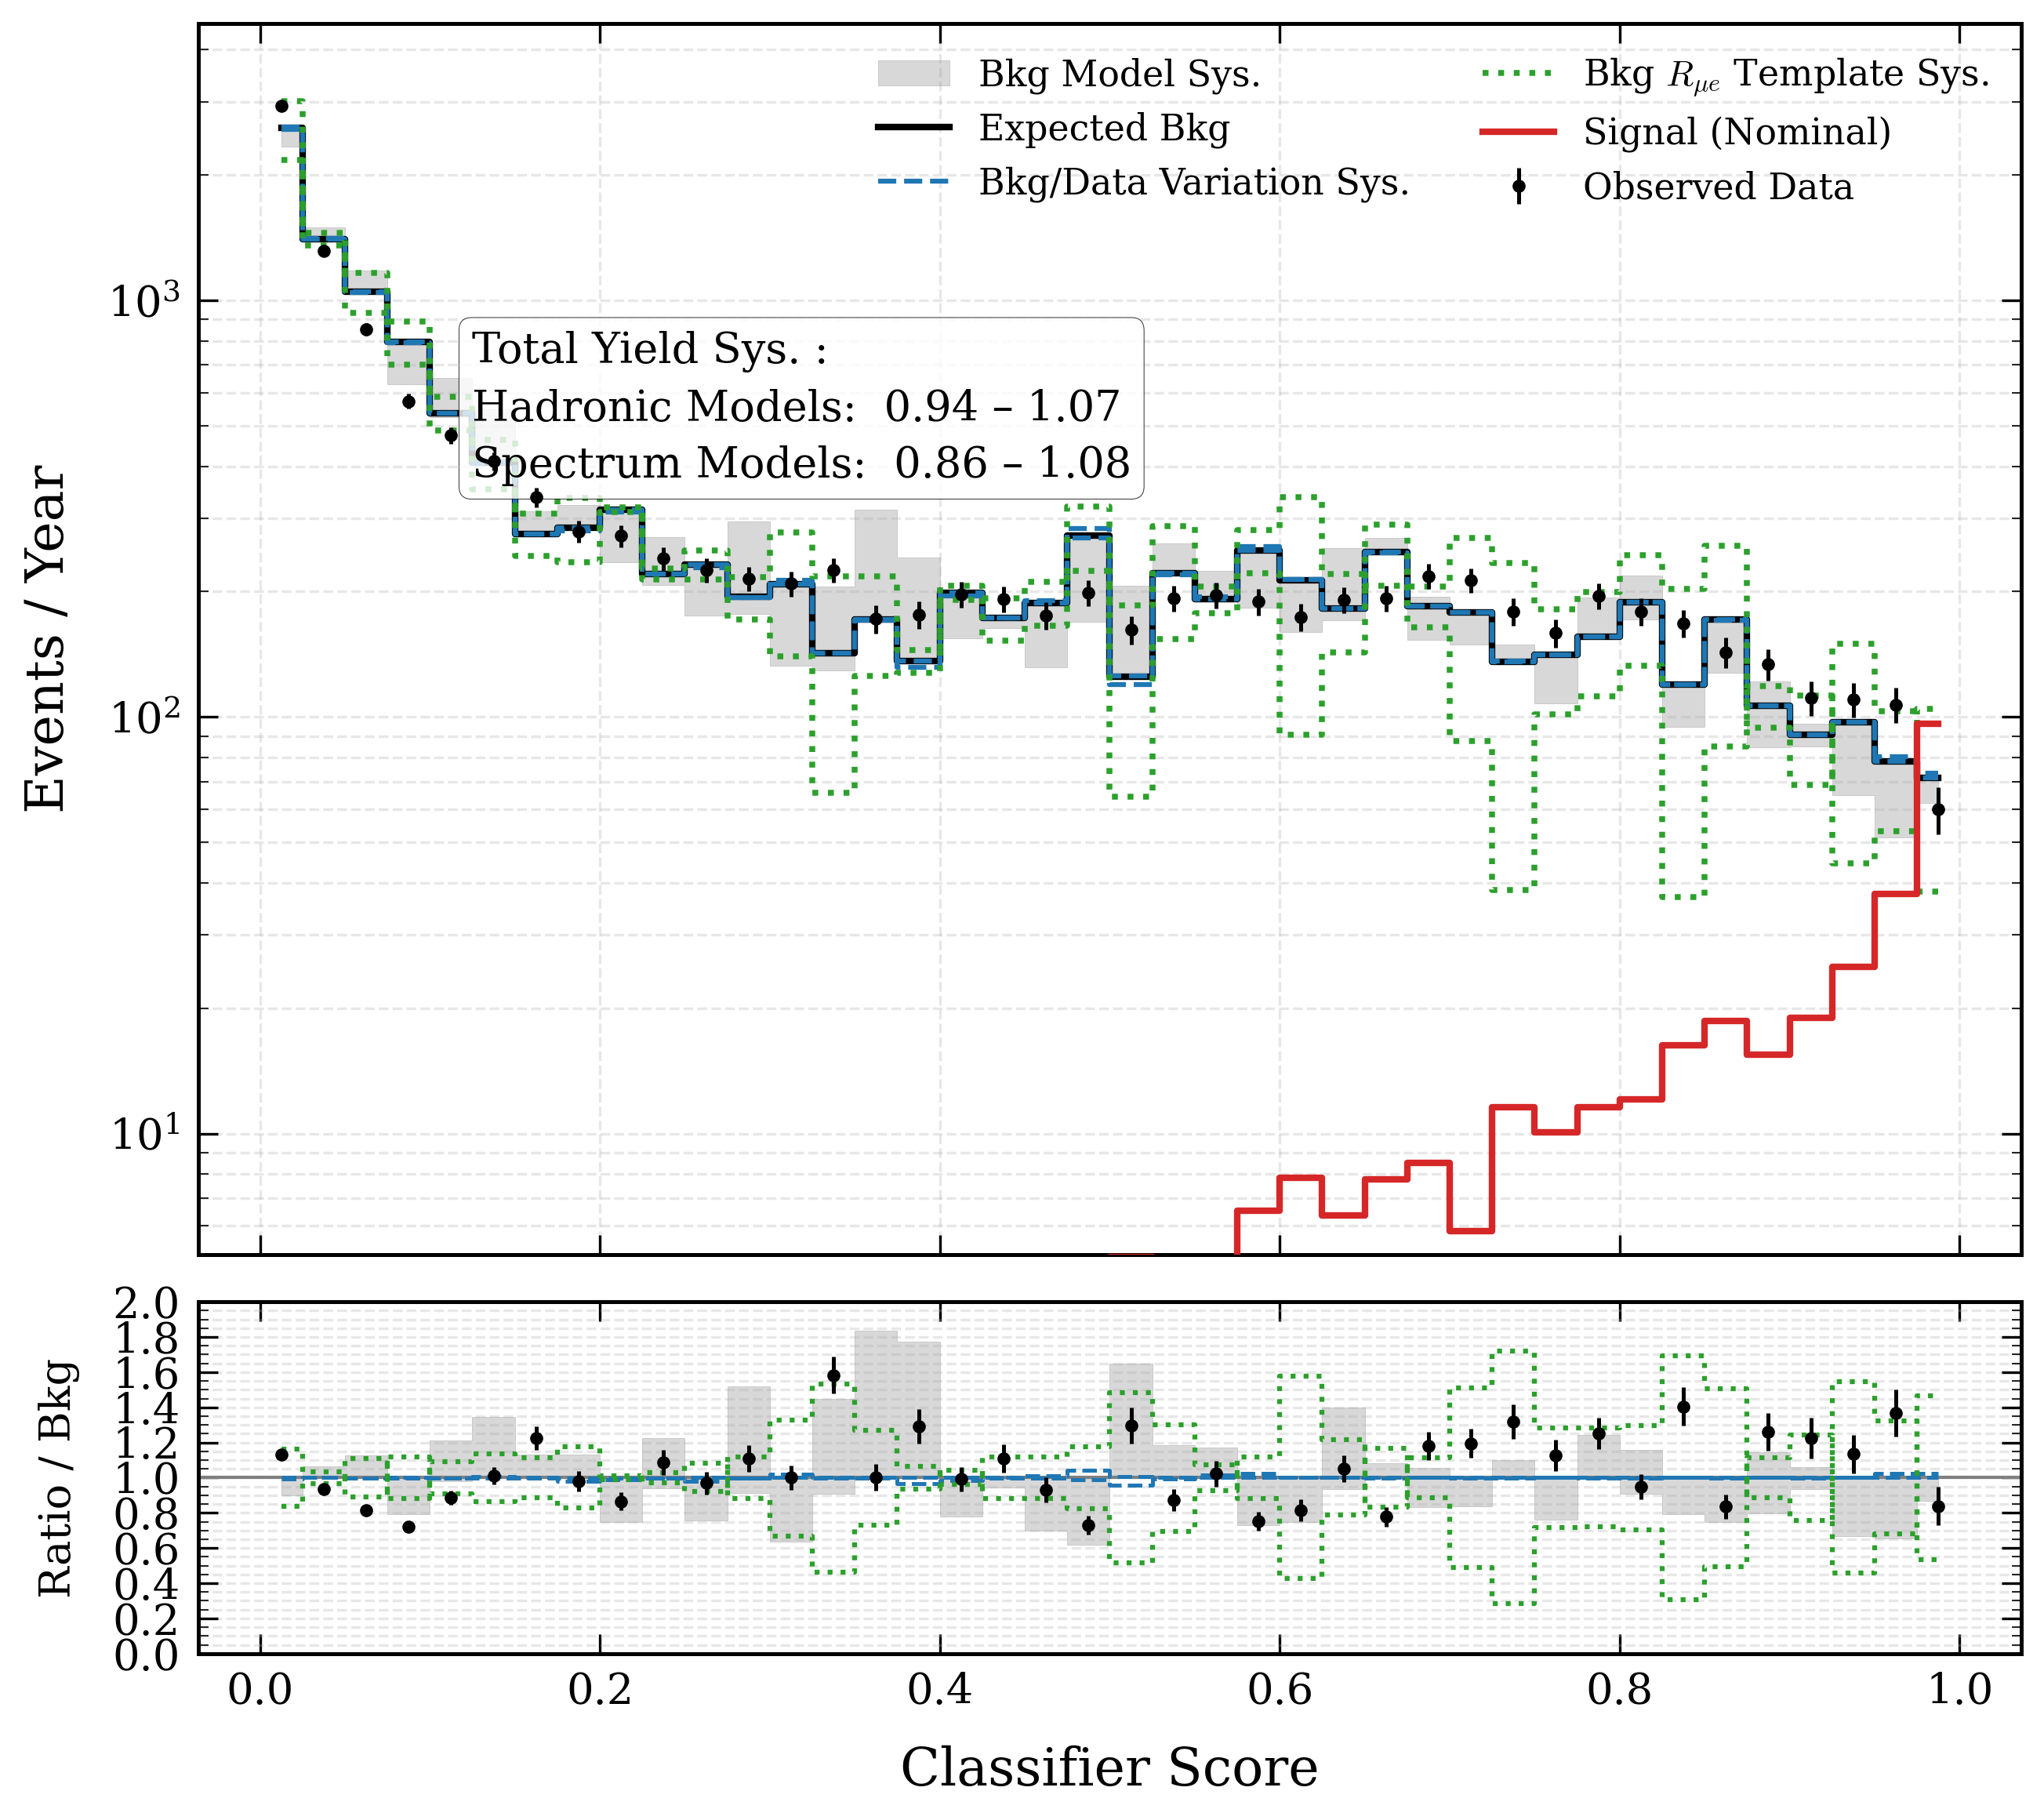


>>> Exporting histograms to ROOT for RooStats (with correct SumW2)...
[OK] Created 'inputs_for_roostats.root' with accurate MC statistical errors.
[1.24137832 1.24153508 1.24250082 1.24269717 1.24181578 1.24179883
 1.24279938 1.24178366 1.24198183 1.2415776  1.24130762 1.24254722
 1.24393777 1.23987388 1.23919633 1.23991727 1.24172955 1.23847223
 1.23630045 1.23867193 1.23930918 1.23897144 1.23710064 1.23902494
 1.23875444 1.23916503 1.23955422 1.24183374 1.23949812 1.23655925
 1.23811191 1.23807369 1.23650288 1.23888768 1.24332348 1.24266824
 1.24804194 1.25084099 1.25070475 1.25169266]


In [29]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

def plot_formal_limit_inputs_refined(centers, bkg_nom, bkg_sys, sig_nom, sig_sys, obs_counts=None, out_path=None):
    """
    绘制符合学术发表标准的 Limit Inputs 及其 Ratio 图。
    obs_counts 为可选参数，如果不传入，则只绘制 Expected 预期分布。
    """
    # 1. 设置学术风格 (Times New Roman + Inward Ticks + LaTeX Math)
    plt.rcParams.update({
        'font.family': 'serif',
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        'font.size': 12,
        'axes.labelsize': 16,
        'axes.titlesize': 16,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 6,
        'ytick.major.size': 6,
        'xtick.minor.size': 3,
        'ytick.minor.size': 3,
        'legend.fontsize': 11,
        'legend.frameon': False,
        'figure.figsize': (10, 9),
        'axes.linewidth': 1.2,
        "mathtext.fontset": "cm",        # 修复 STIX 字体找不到的问题
        "axes.unicode_minus": False,     # 修复负号方块/报错问题
        "xtick.top": True,
        "ytick.right": True
    })

    # 创建带有 Ratio Plot 的子图布局
    fig = plt.figure(dpi=300)
    gs = plt.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # ==========================================
    # 上图：主分布图 (Main Distribution)
    # ==========================================
    
    # 1. 背景模型系统误差带 (Model Shape Sys) - 灰色阴影
    ax1.fill_between(centers, bkg_sys['lo'], bkg_sys['hi'], step='mid', 
                     color='gray', alpha=0.3, label='Bkg Model Sys.', zorder=1)

    # 2. 背景 Nominal - 黑色实线
    ax1.step(centers, bkg_nom, where='mid', label='Expected Bkg', 
             color='black', lw=2, zorder=2)
    # nominal error bar
    nom_error = np.sqrt(bkg_nom)
    # ax1.errorbar(centers, bkg_nom, yerr=nom_error, fmt=' ',
    #              color='black', markersize=4, capsize=0, elinewidth=1.2, zorder=10)
    
    # 3. RecE 系统误差 - 蓝色虚线
    ax1.step(centers, bkg_sys['recE_up'], where='mid', label=r'Bkg/Data Variation Sys.', 
             linestyle='--', color='#1f77b4', lw=1.5, zorder=2)
    ax1.step(centers, bkg_sys['recE_down'], where='mid', 
             linestyle='--', color='#1f77b4', lw=1.5, zorder=2)

    # 4. Rue 系统误差 - 绿色点线
    ax1.step(centers, bkg_sys['rue_up'], where='mid', label=r'Bkg $R_{\mu e}$ Template Sys.', 
             linestyle=':', color='#2ca02c', lw=1.8, zorder=2)
    ax1.step(centers, bkg_sys['rue_down'], where='mid', 
             linestyle=':', color='#2ca02c', lw=1.8, zorder=2)
    text_str = (
    f"Total Yield Sys. :\n"
    f"Hadronic Models:  {models_Ruecut_yield_sys_low:.2f} – {models_Ruecut_yield_sys_high:.2f}\n"
    f"Spectrum Models:  {spectrum_yield_sys_low:.2f} – {spectrum_yield_sys_high:.2f}"
    )
    ax1.text(0.15, 0.75, text_str, 
             transform=ax1.transAxes, fontsize=13, verticalalignment='top',
             linespacing=1.5, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))    
    # 4. Horandel 系统误差 - 红色点线
    # ax1.step(centers, bkg_sys['horandel_low'], where='mid', label=r'Bkg Horandel Sys.', 
    #          linestyle='-.', color='#ff7f0e', lw=1.8, zorder=2)
    # ax1.step(centers, bkg_sys['horandel_high'], where='mid', 
    #          linestyle='-.', color='#ff7f0e', lw=1.8, zorder=2)
    
    # 5. 信号 - 红色填充 + 轮廓
    scale_factor = 1  # 为了可视化，将信号放大 10 倍
    ax1.step(centers, sig_nom*scale_factor, where='mid', label=f'Signal (Nominal)', 
             color='#d62728', lw=2, zorder=3)
    ax1.fill_between(centers, sig_sys['recE_down']*scale_factor, sig_sys['recE_up']*scale_factor, step='mid',
                     color='#d62728', alpha=0.2, zorder=3)

    # 6. 观测数据 - 黑点 + 误差棒 (【修改点：仅当有数据时才绘制】)
    if obs_counts is not None:
        yerr = np.sqrt(obs_counts)
        mask = obs_counts > 0 # 过滤掉 0 计数的点
        ax1.errorbar(centers[mask], obs_counts[mask], yerr=yerr[mask], fmt='o', 
                     color='black', markersize=4, capsize=0, elinewidth=1.2, 
                     label='Observed Data', zorder=10)

    # --- 上图美化 ---
    ax1.set_ylabel(r"Events / Year", labelpad=10)
    ax1.set_yscale('log')
    ax1.grid(True, which='both', linestyle='--', alpha=0.3)
    
    # 动态调整 ylim (加入安全防护，防止数组全是 0 报错)
    positive_bkg = bkg_sys['lo'][bkg_sys['lo'] > 0]
    if len(positive_bkg) > 0:
        ax1.set_ylim(bottom=max(1e-3, np.min(positive_bkg)*0.1))
    
    # 优化图例
    ax1.legend(loc='best', ncol=2)
    plt.setp(ax1.get_xticklabels(), visible=False) 

    # ==========================================
    # 下图：多重比率图 (Multi-Ratio Plot)
    # ==========================================
    
    # 分母：Nominal Background
    denom = np.where(bkg_nom == 0, 1e-9, bkg_nom) # 避免除零

    # 1. 绘制 Data / Bkg (黑点) - (【修改点：仅当有数据时才绘制】)
    if obs_counts is not None:
        ratio_data = obs_counts / denom
        ratio_err = np.sqrt(obs_counts) / denom
        ax2.errorbar(centers[mask], ratio_data[mask], yerr=ratio_err[mask], fmt='o', 
                     color='black', markersize=4, capsize=0, elinewidth=1.2, zorder=10)

    # 2. 绘制基准线 (y=1)
    ax2.axhline(1, color='gray', linestyle='-', linewidth=1)

    # 3. 系统误差的相对幅度展示
    ax2.fill_between(centers, bkg_sys['lo']/denom, bkg_sys['hi']/denom, step='mid', 
                     color='gray', alpha=0.3, label='Model Sys.')
    
    ax2.step(centers, bkg_sys['recE_up']/denom, where='mid', linestyle='--', color='#1f77b4', lw=1.2)
    ax2.step(centers, bkg_sys['recE_down']/denom, where='mid', linestyle='--', color='#1f77b4', lw=1.2)
    
    ax2.step(centers, bkg_sys['rue_up']/denom, where='mid', linestyle=':', color='#2ca02c', lw=1.5)
    ax2.step(centers, bkg_sys['rue_down']/denom, where='mid', linestyle=':', color='#2ca02c', lw=1.5)

    # ax2.step(centers, bkg_sys['horandel_high']/denom, where='mid', linestyle='-.', color='#ff7f0e', lw=1.5)
    # ax2.step(centers, bkg_sys['horandel_low']/denom, where='mid', linestyle='-.', color='#ff7f0e', lw=1.5)

    # --- 下图美化 ---
    ax2.set_xlabel(r"Classifier Score", labelpad=10)
    
    # 如果没有 obs_counts，Ratio 轴的名字可以改成 Sys / Bkg
    y_label_ratio = "Ratio / Bkg" if obs_counts is not None else "Sys / Bkg"
    ax2.set_ylabel(y_label_ratio, labelpad=10, fontsize=13)
    
    ax2.set_ylim(0, 2)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax2.grid(True, which='both', axis='y', linestyle='--', alpha=0.3)
    
    if out_path:
        print(f"Saving figure to {out_path}")
        plt.savefig(out_path, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# ==========================================
# 1. Helper Functions
# ==========================================
def get_counts(df, score_col, weight_col, bins, scaled_num=None):
    """
    获取加权直方图 (用于 Nominal)，同时返回正确的统计方差 (SumW2)。
    """
    scores = df[score_col].values
    weights = df[weight_col].values
    
    # 1. 计算原始的 sum(w) 和 sum(w^2)
    raw_counts, _ = np.histogram(scores, bins=bins, weights=weights)
    raw_variances, _ = np.histogram(scores, bins=bins, weights=weights**2)
    
    # 2. 计算缩放因子 (Scale Factor)
    scale = 1.0
    if scaled_num is not None:
        total_w = np.sum(weights)
        if total_w > 0:
            # 截断前占比
            ratio_left = 1 - df[df[score_col] < bins[0]][weight_col].sum() / total_w
            target_yield = scaled_num * ratio_left
            scale = target_yield / total_w
            
    # 3. 缩放中心值和方差
    # 依据误差传递公式: Var(C * X) = C^2 * Var(X)
    counts = raw_counts * scale
    variances = raw_variances * (scale**2)
    
    # 避免绝对的 0
    counts = np.maximum(counts, 1e-12)
    variances = np.maximum(variances, 1e-12)
    
    return counts, variances


def get_kde_smoothed_hist(df, score_col, weight_col, e_min, e_max, rue_cut, 
                          bins, bandwidth=0.15):
    """
    使用 KDE 生成平滑直方图 (用于计算 Systematics 的 Shape)。
    """
    # 1. 筛选数据
    cond = (df['recE'] > e_min) & (df['recE'] < e_max) & \
           (df['rho40'] > 0) & (df['R_ue'] < rue_cut)
    df_cut = df[cond]
    
    if len(df_cut) < 10: 
        return np.full(len(bins)-1, 1e-12)

    scores = df_cut[score_col].values
    weights = df_cut[weight_col].values
    
    # 2. KDE 拟合
    try:
        kde = gaussian_kde(scores, weights=weights, bw_method=bandwidth)
    except:
        return np.full(len(bins)-1, 1e-12)
        
    # 3. 采样
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = bins[1:] - bins[:-1]
    smoothed_probs = kde(bin_centers) * bin_widths
    
    # 4. 归一化恢复 (Yield Restoration)
    total_yield = np.sum(weights)
    current_sum = np.sum(smoothed_probs)
    
    if current_sum > 0:
        smoothed_counts = smoothed_probs / current_sum * total_yield
    else:
        smoothed_counts = smoothed_probs
        
    return np.maximum(smoothed_counts, 1e-12)

# 用于信号的 Raw Histogram 计算 (不平滑)
def get_counts_raw_cut(df, score_col, weight_col, e_min, e_max, rue_cut):
    cond = (df['recE'] > e_min) & (df['recE'] < e_max) & \
           (df['rho40'] > 0) & (df['R_ue'] < rue_cut)
    df_cut = df[cond]
    if len(df_cut) == 0: return np.full(len(BINS)-1, 1e-12)
    counts, _ = np.histogram(df_cut[score_col], bins=BINS, weights=df_cut[weight_col])
    return np.maximum(counts, 1e-12)

def apply_analysis_cuts_step2(df, Classifier: ClassifierManager ,CUT_E_MIN=2.9, CUT_E_MAX=3.2, CUT_RUE_NOM=-2.7):

    
    # 1. 基础质量切割 (示例)
    cut_recE = (df['recE'] > CUT_E_MIN) & (df['recE'] < CUT_E_MAX)
    cut_rue = df['R_ue'] < CUT_RUE_NOM
    
    # 2. 应用切割
    df_cut = df[cut_recE &  cut_rue].copy()
    df_cut['mlp_score']  = Classifier.predict_ensemble(df_cut)

    return df_cut


TEMPLATE_VALIDITY_CUT = TEMPLATE_CUT
bkg_train_final_extension = apply_analysis_cuts_step2(pr_df_large_cut, manager, CUT_E_MIN=CUT_E_NOM-0.2, CUT_E_MAX=CUT_E_MAX+0.2, CUT_RUE_NOM=TEMPLATE_CUT+0.5)
sig_train_final_extension = apply_analysis_cuts_step2(mn_df_large, manager, CUT_E_MIN=CUT_E_NOM-0.2, CUT_E_MAX=CUT_E_MAX+0.2, CUT_RUE_NOM=CUT_RUE_NOM)

# ==========================================
# 2. Configuration & Nominal Calculation
# ==========================================
print("\n>>> Step 1: Configuration & Nominal Histograms...")

# Constants
BINS = np.linspace(0., 1.0, 41) # 50 bins
centers = (BINS[:-1] + BINS[1:]) / 2
TARGET_FLUX = 'gaisser_weight'

delta_Rue_TEMPLATE = 0.2
UNC_E = 0.0003 
UNC_RUE=0.0035
shift_up = UNC_E
shift_down = -UNC_E
print(f"Energy Scale Shifts: +{shift_up:.3f}, {shift_down:.3f} (log10 scale)")
KDE_BW = 0.05# 平滑系数

# Calculate Total Yields (Normalization)
CUT_SCORE = 0.
n_exp = exp_final[exp_final['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_train_final[bkg_train_final['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_train_final[sig_train_final['mlp_score'] > CUT_SCORE]['weight'].sum()
TIMES = 365*86400
scale_factor = 1.0
num_dict = {
    'bkg_nom': n_exp , # 使用 Data-driven 归一化
    'bkg_ef': n_exp ,
    'bkg_qf': n_exp,
    'sig_nom': n_sig * TIMES * scale_factor, # 信号使用理论预期归一化
    'obs_counts': n_exp ,
}

# --- A. Calculate Nominal Histograms (The "Base") ---
# 1. Background (QGSJET)
bkg_nom, bkg_nom_vars = get_counts(bkg_train_final, 'mlp_score', TARGET_FLUX, BINS, scaled_num=num_dict['bkg_nom'])
total_yield_nom = np.sum(bkg_nom)

# 2. Systematics Bases (EPOS & QGSII)
bkg_ef,_ = get_counts(pseudo_ef_final, 'mlp_score', TARGET_FLUX, BINS, scaled_num=num_dict['bkg_ef'])
bkg_qf,_ = get_counts(pseudo_qf_final, 'mlp_score', TARGET_FLUX, BINS, scaled_num=num_dict['bkg_qf'])
# 3. Signal & Obs
sig_nom, sig_nom_vars = get_counts(sig_train_final, 'mlp_score', 'weight', BINS, scaled_num=num_dict['sig_nom'])
total_yield_sig= np.sum(sig_nom)
obs_counts,_ = get_counts(exp_final, 'mlp_score', 'weight', BINS, scaled_num=num_dict['obs_counts'])

print(f"Observed Counts: {obs_counts.sum():.2f}")
print(f"Signal Nominal:  {sig_nom.sum():.2f}")

# ==========================================
# 3. Systematics Calculation (Smooth Ratios)
# ==========================================
print("\n>>> Step 2: Calculating Smoothed Systematics (Ratio Method)...")

# --- A. Background: KDE Smoothed Ratios ---

# 1. Smooth Nominal Template (Loose, < -1.5)
bkg_nom_smooth = get_kde_smoothed_hist(
    bkg_train_final_extension, 'mlp_score', TARGET_FLUX,
    CUT_E_NOM, CUT_E_MAX, TEMPLATE_VALIDITY_CUT, 
    BINS, bandwidth=KDE_BW
)

# 2. Smooth Variations (Loose, < -1.5)
bkg_recE_up_smooth = get_kde_smoothed_hist(
    bkg_train_final_extension, 'mlp_score', TARGET_FLUX,
    CUT_E_NOM + shift_up, CUT_E_MAX + shift_up, TEMPLATE_VALIDITY_CUT, 
    BINS, bandwidth=KDE_BW
)
bkg_recE_down_smooth = get_kde_smoothed_hist(
    bkg_train_final_extension, 'mlp_score', TARGET_FLUX,
    CUT_E_NOM + shift_down, CUT_E_MAX + shift_down, TEMPLATE_VALIDITY_CUT, 
    BINS, bandwidth=KDE_BW
)
# Template Stability: Compare -1.5 vs -1.7
shape_tight_smooth = get_kde_smoothed_hist(
    bkg_train_final_extension, 'mlp_score', TARGET_FLUX,
    CUT_E_NOM, CUT_E_MAX, TEMPLATE_VALIDITY_CUT - delta_Rue_TEMPLATE, 
    BINS, bandwidth=KDE_BW
)

bkg_nom_smooth_horandel = get_kde_smoothed_hist(
    bkg_train_final_extension, 'mlp_score', "horandel_weight",
    CUT_E_NOM, CUT_E_MAX, TEMPLATE_VALIDITY_CUT, 
    BINS, bandwidth=KDE_BW
)


# 3. Calculate Ratios & Apply to Nominal
eps = 1e-9
# Energy Scale
ratio_up_bkg = bkg_recE_up_smooth / (bkg_nom_smooth + eps)
ratio_down_bkg = bkg_recE_down_smooth / (bkg_nom_smooth + eps)
bkg_recE_up_scaled = bkg_nom * ratio_up_bkg
bkg_recE_down_scaled = bkg_nom * ratio_down_bkg

# Rue Template Stability (Pure Shape)
norm_nom = bkg_nom_smooth / np.sum(bkg_nom_smooth)
norm_tight = shape_tight_smooth / np.sum(shape_tight_smooth)
ratio_shape = norm_tight / (norm_nom + eps)

bkg_rue_sys_up = bkg_nom * ratio_shape
bkg_rue_sys_down = 2 * bkg_nom - bkg_rue_sys_up # Symmetrized

# Model Sys (Horandel vs Gaisser)
ratio_horandel = bkg_nom_smooth_horandel / (bkg_nom_smooth + eps)
bkg_horandel_low = bkg_nom * ratio_horandel
bkg_horandel_high = 2 * bkg_nom - bkg_horandel_low # Symmetrized

# --- B. Signal: Raw Ratios (Low Stats) ---
# Calculate Raw Histograms for Signal Variations
sig_raw_nom = get_counts_raw_cut(sig_train_final, 'mlp_score', 'weight', CUT_E_NOM, CUT_E_MAX, CUT_RUE_NOM)
sig_raw_up = get_counts_raw_cut(sig_train_final, 'mlp_score', 'weight', CUT_E_NOM + shift_up, CUT_E_MAX + shift_up, CUT_RUE_NOM)
sig_raw_down = get_counts_raw_cut(sig_train_final, 'mlp_score', 'weight', CUT_E_NOM + shift_down, CUT_E_MAX + shift_down, CUT_RUE_NOM)
sig_raw_nom *= total_yield_sig / np.sum(sig_raw_nom) # 归一化到总数一致
sig_raw_up *= total_yield_sig / np.sum(sig_raw_up)
sig_raw_down *= total_yield_sig / np.sum(sig_raw_down)

# Apply Ratios
sig_recE_up_scaled = sig_nom * (sig_raw_up / (sig_raw_nom + eps))
sig_recE_down_scaled = sig_nom * (sig_raw_down / (sig_raw_nom + eps))

# Clean Data
def clean(h): return np.nan_to_num(h, nan=eps, posinf=eps, neginf=eps)
bkg_recE_up_scaled = clean(bkg_recE_up_scaled)
bkg_recE_down_scaled = clean(bkg_recE_down_scaled)
bkg_rue_sys_up = clean(bkg_rue_sys_up)
bkg_rue_sys_down = clean(bkg_rue_sys_down)

bkg_horandel_low = clean(bkg_horandel_low)
bkg_horandel_high = clean(bkg_horandel_high)


sig_recE_up_scaled = clean(sig_recE_up_scaled)
sig_recE_down_scaled = clean(sig_recE_down_scaled)

# ==========================================
# 4. Construct Envelope (Model Sys)
# ==========================================
raw_hi = np.max([bkg_nom, bkg_ef, bkg_qf], axis=0)
raw_lo = np.min([bkg_nom, bkg_ef, bkg_qf], axis=0)
grad_eps = bkg_nom * 1e-5 + 1e-5 
bkg_hi = np.maximum(raw_hi, bkg_nom + grad_eps)
bkg_lo = np.minimum(raw_lo, bkg_nom - grad_eps)

# ==========================================# ==========================================# ==========================================
def normalize_to_nominal(sys_varied, sys_name, sig=False):
    """将变动后的直方图强制缩放到与 Nominal 相同的总数"""
    current_yield = np.sum(sys_varied)
    if current_yield == 0: return sys_varied
    
    if not sig:
    # 计算缩放因子
        scale = total_yield_nom / current_yield
    elif sig:
        scale = total_yield_sig / current_yield
    # 打印一下看看修正了多少 (Debug info)
    if abs(scale - 1.0) > 0.01:
        print(f"  Fixing {sys_name}: Scaling by {scale:.4f} to remove norm effect.")
    
    return sys_varied * scale

# 2. 对所有背景系统误差应用归一化
# Template Stability (这就是导致你报错的罪魁祸首)
bkg_rue_sys_up = normalize_to_nominal(bkg_rue_sys_up, "Rue Sys Up")
bkg_rue_sys_down = normalize_to_nominal(bkg_rue_sys_down, "Rue Sys Down")

# Energy Scale
# bkg_recE_up_scaled = normalize_to_nominal(bkg_recE_up_scaled, "RecE Sys Up")
# bkg_recE_down_scaled = normalize_to_nominal(bkg_recE_down_scaled, "RecE Sys Down")

# Model Shape (Lo/Hi)
# bkg_lo = normalize_to_nominal(bkg_lo, "Model Sys Lo")
# bkg_hi = normalize_to_nominal(bkg_hi, "Model Sys Hi")

# Sig
# sig_recE_down_scaled = normalize_to_nominal(sig_recE_down_scaled, "Sig RecE Sys Down", sig=True)
# sig_recE_up_scaled = normalize_to_nominal(sig_recE_up_scaled, "Sig RecE Sys Up", sig=True)
# ==========================================# ==========================================# ==========================================

# ==========================================
# 5. Validation Print
# ==========================================
print(f"\n[Check] Total Yields:")
print(f"Bkg Nominal:   {bkg_nom.sum():.2f}")
# print(f"Bkg Nominal:   {bkg_nom_smooth.sum()*total_yield_nom:.2f}")
print(f"Bkg recE Up:   {bkg_recE_up_scaled.sum():.2f}")
print(f"Bkg Rue Shape: {bkg_rue_sys_up.sum():.2f} (Should be close to Nom)")
print(f"Bkg Horandel:  {bkg_horandel_low.sum():.2f}, {bkg_horandel_high.sum():.2f}")

print(f"Sig Nominal:   {sig_nom.sum():.2e}")
print(f"Sig recE Up:   {sig_recE_up_scaled.sum():.2e}")


# <OverallSys Name="models_Ruecut_yield_sys" Low="0.9860" High="1.0084"/>
#     <OverallSys Name="spectrum_yield_sys" Low="0.8954" High="1.1046"/>

models_Ruecut_yield_sys_low = 0.9368
models_Ruecut_yield_sys_high = 1.0681
spectrum_yield_sys_low = 0.8605
spectrum_yield_sys_high = 1.0769

# 构造传入字典
bkg_sys_dict = {
    'hi': bkg_hi, 
    'lo': bkg_lo, 
    'recE_up': bkg_recE_up_scaled, 
    'recE_down': bkg_recE_down_scaled, 
    'rue_up': bkg_rue_sys_up, 
    'rue_down': bkg_rue_sys_down,
    'horandel_low': bkg_horandel_low,
    'horandel_high': bkg_horandel_high
}
sig_sys_dict = {
    'recE_up': sig_recE_up_scaled, 
    'recE_down': sig_recE_down_scaled
}

plot_formal_limit_inputs_refined(
    centers, 
    bkg_nom, 
    bkg_sys_dict, 
    sig_nom, 
    sig_sys_dict, 
    obs_counts, 
    out_path=f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_{len(BINS)-1}_ABCD_extend_small2large.pdf"
)

import ROOT
import array

print("\n>>> Exporting histograms to ROOT for RooStats (with correct SumW2)...")

def write_hist_pyroot(file_obj, name, counts, variances, bins):
    """使用 PyROOT 写入直方图，并强制灌入正确的统计误差"""
    # 转换为 ROOT 能识别的 double 数组
    bin_edges = array.array('d', bins)
    h = ROOT.TH1D(name, name, len(bins)-1, bin_edges)
    
    # 极其重要：激活平方权重和机制
    h.Sumw2()
    
    for i in range(len(counts)):
        # ROOT 的 Bin 索引从 1 开始 (0 是 Underflow)
        h.SetBinContent(i+1, counts[i])
        
        # 只有 Nominal 样本需要真实的 MC 统计误差，
        # 如果 variances 为 None，则由 ROOT 默认处理
        if variances is not None:
            h.SetBinError(i+1, np.sqrt(variances[i]))
            
    h.SetDirectory(file_obj)
    h.Write()

# 1. 打开 ROOT 文件 (覆盖模式)
f_out = ROOT.TFile("./models_UL/inputs_for_roostats.root", "RECREATE")

# 2. 写入 Data 
# Data 没有 MC 权重概念，方差传 None 即可，ROOT 会自动用 sqrt(N)
write_hist_pyroot(f_out, "h_data", obs_counts, None, BINS)

# 3. 写入 Nominal 背景和信号 (带上刚刚算出的真实方差！)
write_hist_pyroot(f_out, "h_bkg_nom", bkg_nom, bkg_nom_vars, BINS) 
write_hist_pyroot(f_out, "h_sig_nom", sig_nom, sig_nom_vars, BINS)

# 4. 写入系统误差 (Systematics)
# 系统误差模板（Up/Down）在 HistFactory 中只提供“形状变化”的中心值，
# 它们的独立统计波动通常被忽略。因此 variance 传 None 即可。
write_hist_pyroot(f_out, "h_bkg_recE_up", bkg_recE_up_scaled, None, BINS)
write_hist_pyroot(f_out, "h_bkg_recE_down", bkg_recE_down_scaled, None, BINS)
write_hist_pyroot(f_out, "h_sig_recE_up", sig_recE_up_scaled, None, BINS)
write_hist_pyroot(f_out, "h_sig_recE_down", sig_recE_down_scaled, None, BINS)

write_hist_pyroot(f_out, "h_bkg_rue_up", bkg_rue_sys_up, None, BINS)
write_hist_pyroot(f_out, "h_bkg_rue_down", bkg_rue_sys_down, None, BINS)

write_hist_pyroot(f_out, "h_bkg_model_hi", bkg_hi, None, BINS)
write_hist_pyroot(f_out, "h_bkg_model_lo", bkg_lo, None, BINS)

# write_hist_pyroot(f_out, "h_bkg_horandel_low", bkg_horandel_low, None, BINS)
# write_hist_pyroot(f_out, "h_bkg_horandel_high", bkg_horandel_high, None, BINS)

f_out.Close()
print("[OK] Created 'inputs_for_roostats.root' with accurate MC statistical errors.")


print(bkg_nom/bkg_horandel_low)

In [ ]:
a=np.array([3.6182,1.6577])
std_a=np.std(a)
mean_a=np.mean(a)
print(mean_a, std_a)
print(std_a/np.mean(a))

2.63795 0.98025
0.37159536761500406


: 

In [ ]:

# # =====================================================
# # 3. Build PyHF JSON Specification (Updated)
# # =====================================================
# spec = {
#     "channels": [
#         {
#             "name": "single_channel",
#             "samples": [
#                 {
#                     "name": "background",
#                     "data": bkg_nom.tolist(),
#                     "modifiers": [
#                         # 1. Model Shape Uncertainty (EPOS/QGS Envelope)
#                         {
#                             "name": "model_shape_sys",
#                             "type": "histosys",
#                             "data": {
#                                 "lo_data": bkg_lo.tolist(),
#                                 "hi_data": bkg_hi.tolist()
#                             }
#                         },
#                         # 2. Energy Scale Uncertainty (recE)
#                         # 注意：Rue 误差被忽略了，所以只加这一个
#                         {
#                             "name": "energy_scale_sys",
#                             "type": "histosys",
#                             "data": {
#                                 "lo_data": bkg_recE_down_scaled.tolist(),
#                                 "hi_data": bkg_recE_up_scaled.tolist()
#                             }
#                         },
#                         # 3. 模板稳定性误差 (替代 Rue Cut Error)
#                         # 反映了 "如果我们用 -1.6 而不是 -1.5 做模板，结果会变多少"
#                         {
#                             "name": "template_stability_sys",
#                             "type": "histosys",
#                             "data": { "lo_data": bkg_rue_sys_down.tolist(), "hi_data": bkg_rue_sys_up.tolist() }
#                         },
#                         # 4. Free Floating Background Normalization
#                         {
#                             "name": "mu_bkg", 
#                             "type": "normfactor",
#                             "data": None
#                         }
#                     ]
#                 },
#                 {
#                     "name": "signal",
#                     "data": sig_nom.tolist(),
#                     "modifiers": [
#                         # Signal Strength (POI)
#                         {
#                             "name": "mu",
#                             "type": "normfactor",
#                             "data": None
#                         },
#                         # [新增] Signal Energy Scale (必须与背景同名以保持关联)
#                         {
#                             "name": "energy_scale_sys",
#                             "type": "histosys",
#                             "data": {
#                                 "lo_data": sig_recE_down_scaled.tolist(),
#                                 "hi_data": sig_recE_up_scaled.tolist()
#                             }
#                         }
#                     ]
#                 }
#             ]
#         }
#     ],
#     # ... (observation 和 measurements 部分保持不变) ...
#     "observations": [
#         {
#             "name": "single_channel",
#             "data": obs_counts.tolist()
#         }
#     ],
#     "measurements": [
#         {
#             "name": "measurement",
#             "config": {
#                 "poi": "mu",
#                 "parameters": [
#                     {
#                         "name": "mu",
#                         "bounds": [[0, 20]],
#                         "inits": [1.0]
#                     },
#                     {
#                         "name": "mu_bkg",
#                         "bounds": [[0, 5]], 
#                         "inits": [1.0]
#                     }
#                 ]
#             }
#         }
#     ],
#     "version": "1.0.0"
# }



# out_json = "/data/home/zzh/Filt_Event/UpperLimit/uncertainty/Transformer_baseline/model_with_free_bkg_ABCD_smooth.json"
# with open(out_json, "w") as f:
#     json.dump(spec, f, indent=4)

# print(f"[OK] JSON saved to {out_json}")



[OK] JSON saved to /data/home/zzh/Filt_Event/UpperLimit/uncertainty/Transformer_baseline/model_with_free_bkg_ABCD_smooth.json


In [ ]:
# import uproot

# print("\n>>> Exporting histograms to ROOT for RooStats...")

# # 定义输出文件名
# f_out = uproot.recreate("./models_UL/inputs_for_roostats.root")

# # 辅助函数：将 numpy 数组存为 ROOT 直方图
# # 注意：uproot 写入时需要 bin edges
# def write_hist(file, name, counts, bins):
#     file[name] = (counts, bins)

# # 1. 写入数据 (Data)
# write_hist(f_out, "h_data", obs_counts, BINS)

# # 2. 写入 Nominal 背景和信号
# write_hist(f_out, "h_bkg_nom", bkg_nom, BINS) # 如果你平滑了，就用 bkg_nom_smooth
# write_hist(f_out, "h_sig_nom", sig_nom, BINS)

# # 3. 写入系统误差 (Systematics)
# # 命名规则：h_{sample}_{sys}_{up/down}

# # Energy Scale
# write_hist(f_out, "h_bkg_recE_up", bkg_recE_up_scaled, BINS)
# write_hist(f_out, "h_bkg_recE_down", bkg_recE_down_scaled, BINS)
# write_hist(f_out, "h_sig_recE_up", sig_recE_up_scaled, BINS)
# write_hist(f_out, "h_sig_recE_down", sig_recE_down_scaled, BINS)

# # Template Stability (Rue)
# write_hist(f_out, "h_bkg_rue_up", bkg_rue_sys_up, BINS)
# write_hist(f_out, "h_bkg_rue_down", bkg_rue_sys_down, BINS)

# # Model Shape (Envelope)
# write_hist(f_out, "h_bkg_model_hi", bkg_hi, BINS)
# write_hist(f_out, "h_bkg_model_lo", bkg_lo, BINS)

# f_out.close()
# print("[OK] Created 'inputs_for_roostats.root'")



>>> Exporting histograms to ROOT for RooStats...
[OK] Created 'inputs_for_roostats.root'


计算上限

In [ ]:
# import numpy as np
# import json
# import pyhf
# import matplotlib.pyplot as plt
# from pyhf.contrib.viz import brazil


# out_json = "/data/home/zzh/Filt_Event/UpperLimit/uncertainty/Transformer_baseline/model_with_free_bkg_ABCD_smooth.json"
# # =====================================================
# # 4. Calculate Upper Limit
# # =====================================================
# print("\n>>> Running Limit Calculation...")
# try:
#     with open(out_json, "r") as f:
#             spec = json.load(f)
# except FileNotFoundError:
#     print("错误: 未找到 model.json")
#     exit()
# # Setup Minuit optimizer with robust settings
# try:
#     custom_optimizer = pyhf.optimize.minuit_optimizer(verbose=False, strategy=2, tolerance=1)
#     pyhf.set_backend("numpy", custom_optimizer)
    
# except ImportError:
#     print("Warning: iminuit not installed, using scipy backend.")

# workspace = pyhf.Workspace(spec)
# model = workspace.model()
# observations = workspace.data(model)
# try:
#     custom_optimizer = pyhf.optimize.minuit_optimizer(verbose=False, strategy=1, tolerance=5)
#     pyhf.set_backend("numpy", custom_optimizer)
# except ImportError:
#     print("[Setup] Minuit not installed, using Scipy backend (options may vary).")
#     pyhf.set_backend("numpy", "scipy")
# # Relax bounds for systematics to prevent fit failures
# init_pars = model.config.suggested_init()
# par_bounds = model.config.suggested_bounds()
# poi_index = model.config.poi_index

# new_bounds = []
# for i, bounds in enumerate(par_bounds):
#     if i == poi_index:
#         new_bounds.append(bounds) # Keep mu bounds
#     else:
#         new_bounds.append([-50.0, 50.0]) # Relax nuisance bounds

# # 1. Perform Fit (Check background normalization)
# print("Performing MLE Fit...")
# best_fit_pars = pyhf.infer.mle.fit(observations, model, par_bounds=new_bounds, tolerance=1.0,)
# param_dict = dict(zip(model.config.par_order, best_fit_pars))
# print(f"Fit Result - mu_bkg: {param_dict.get('mu_bkg', 1.0):.4f}")

# # 2. Compute CLs Limits
# print("Computing CLs Upper Limits...")
# poi_values = np.linspace(0.01, 0.6, 50) # Adjust range based on sensitivity
# try:
#     results = pyhf.infer.intervals.upper_limits.upper_limit(
#         observations, model, poi_values, level=0.1, return_results=True, par_bounds=new_bounds
#     )
#     obs_limit, exp_limits = results[0], results[1]
    
#     # Calculate Flux Limit (assuming 'mu' scales the signal yield)
#     # Flux Limit = (Limit_mu) * (Reference Flux)
#     # Since sig_nom corresponds to your simulated flux (say 1e-13), multiply accordingly.
    
#     print("\n" + "="*40)
#     print(f"90% CL Upper Limit on mu:")
#     print(f"  Observed: {obs_limit:.4f}")
#     print(f"  Expected: {exp_limits[2]:.4f} (+{exp_limits[3]-exp_limits[2]:.2f} / -{exp_limits[2]-exp_limits[1]:.2f}) and (+{exp_limits[4]-exp_limits[2]:.2f} / -{exp_limits[2]-exp_limits[0]:.2f})")
#     print("="*40 + "\n")
    
#     # 3. Brazil Plot
#     hypo_results = [
#         pyhf.infer.hypotest(mu, observations, model, return_expected_set=True, test_stat="qtilde", par_bounds=new_bounds)
#         for mu in poi_values
#     ]
# except Exception as e:
#     print(f"Limit calculation failed: {e}")


# fig, ax = plt.subplots(figsize=(10, 7))
# brazil.plot_results(poi_values, hypo_results, ax=ax, test_size=0.1)

# if not np.isnan(obs_limit):
#     ax.axvline(obs_limit, color='blue', linestyle='-.', alpha=0.8, label=rf'Obs. Limit ($\mu$={obs_limit:.4f})')
# plt.xlabel(r"Signal Strength $\mu$")
# plt.ylabel(r"$CL_s$")
# plt.title(f"Upper Limit (90% CL): {exp_limits[2]:.4f} (+{exp_limits[3]-exp_limits[2]:.2f} / -{exp_limits[2]-exp_limits[1]:.2f})")
# plt.legend(loc='upper right', fontsize=15, frameon=False)
# # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/ABCD_extend_small2large_limit.pdf", bbox_inches='tight', pad_inches=0.1)
# plt.show()


ModuleNotFoundError: No module named 'pyhf'

In [ ]:
# import numpy as np
# import pyhf
# from scipy import interpolate

# # ==========================================
# # 1. MLE Fit (Diagnostic - 检查背景归一化)
# # ==========================================
# print(">>> Performing MLE Fit...")
# # tolerance 放宽到 1.0 以避免 "INVALID Minimum" 报错
# best_fit_pars = pyhf.infer.mle.fit(
#     observations, model, 
#     par_bounds=new_bounds, 
#     tolerance=1.0, 
#     # optimizer_kwargs={"strategy": 2} # Minuit 策略 2 更精准
# )
# param_dict = dict(zip(model.config.par_order, best_fit_pars))
# print(f"Fit Result - mu_bkg: {param_dict.get('mu_bkg', 1.0):.4f}")
# try:
#     custom_optimizer = pyhf.optimize.minuit_optimizer(verbose=False, strategy=2, tolerance=1.0)
#     pyhf.set_backend("numpy", custom_optimizer)
#     print("[Setup] Using Minuit backend with tolerance=1.0")
# except ImportError:
#     print("[Setup] Minuit not installed, using Scipy backend (options may vary).")
#     pyhf.set_backend("numpy", "scipy")
# # ==========================================
# # 2. CLs Scan & Limit Calculation (Robust Method)
# # ==========================================
# print("\n>>> Computing CLs Limits (Scanning)...")

# # 设置扫描范围 (根据你的灵敏度调整)
# poi_values = np.linspace(0.01, 0.6, 50) 

# # 存储扫描结果
# results_obs = []
# results_exp = []

# # 开始循环扫描 (这部分同时为 Limit 计算和 Brazil Plot 准备数据)
# for i, mu in enumerate(poi_values):
#     if i % 10 == 0: print(f"  Scanning mu = {mu:.3f}...")
    
#     try:
#         # 修正：移除了 tolerance=1.0，因为全局已经设置了
#         cls_obs, cls_exp_set = pyhf.infer.hypotest(
#             mu, observations, model, 
#             test_stat="qtilde", 
#             return_expected_set=True, 
#             par_bounds=new_bounds
#             # tolerance=1.0  <-- 删掉这一行！
#         )
#         results_obs.append(cls_obs)
#         results_exp.append(cls_exp_set)
#     except Exception as e:
#         print(f"  [Warning] Fit failed at mu={mu:.3f}: {e}")
#         results_obs.append(np.nan)
#         results_exp.append([np.nan]*5)

# # 转换为 numpy 数组方便切片
# # results_exp 结构: [N_points, 5] -> columns: -2sigma, -1sigma, median, +1sigma, +2sigma
# results_exp = np.array(results_exp)
# results_obs = np.array(results_obs)

# # ==========================================
# # 3. Interpolate Limits (从扫描数据反推 Limit)
# # ==========================================
# # 目标 CLs 值 (90% CL -> alpha = 0.1)
# alpha = 0.1

# def get_limit(mu_array, cls_array, target_alpha=0.1):
#     """通过线性插值寻找 CLs = 0.1 的交叉点"""
#     # 移除 NaN 值
#     valid = ~np.isnan(cls_array)
#     x = mu_array[valid]
#     y = cls_array[valid]
    
#     # 如果曲线没有穿过 0.1，返回 None
#     if np.min(y) > target_alpha or np.max(y) < target_alpha:
#         return np.nan
        
#     # 对 log(CLs) 进行插值通常更线性、更准确
#     f = interpolate.interp1d(np.log(y), x, kind='linear', bounds_error=False, fill_value="extrapolate")
#     return float(f(np.log(target_alpha)))

# # 计算各个 Limit
# obs_limit = get_limit(poi_values, results_obs, alpha)
# exp_limit_med = get_limit(poi_values, results_exp[:, 2], alpha)
# exp_limit_m1 = get_limit(poi_values, results_exp[:, 1], alpha) # -1 sigma
# exp_limit_p1 = get_limit(poi_values, results_exp[:, 3], alpha) # +1 sigma
# exp_limit_m2 = get_limit(poi_values, results_exp[:, 0], alpha) # -2 sigma
# exp_limit_p2 = get_limit(poi_values, results_exp[:, 4], alpha) # +2 sigma

# print("\n" + "="*50)
# print(f"90% CL Upper Limit on mu (Interpolated):")
# print(f"  Observed: {obs_limit:.4f}")
# print(f"  Expected: {exp_limit_med:.4f}")
# print(f"     +1 sig: {exp_limit_p1:.4f} (+{exp_limit_p1 - exp_limit_med:.2f})")
# print(f"     -1 sig: {exp_limit_m1:.4f} (-{exp_limit_med - exp_limit_m1:.2f})")
# print(f"     +2 sig: {exp_limit_p2:.4f} (+{exp_limit_p2 - exp_limit_med:.2f})")
# print(f"     -2 sig: {exp_limit_m2:.4f} (-{exp_limit_med - exp_limit_m2:.2f})")
# print("="*50 + "\n")

# # ==========================================
# # 4. Prepare Data for Plotting (Variables for next step)
# # ==========================================
# # 这些变量可以直接传给绘图函数
# # poi_values: X 轴
# # results_obs: Y 轴 (Observed CLs)
# # results_exp: Y 轴 (Expected CLs Bands)


>>> Performing MLE Fit...
Fit Result - mu_bkg: 0.9350
[Setup] Using Minuit backend with tolerance=1.0

>>> Computing CLs Limits (Scanning)...
  Scanning mu = 0.010...
  Scanning mu = 0.130...
  Scanning mu = 0.251...
  Scanning mu = 0.371...
  Scanning mu = 0.492...

90% CL Upper Limit on mu (Interpolated):
  Observed: 0.2384
  Expected: 0.1937
     +1 sig: 0.2877 (+0.09)
     -1 sig: 0.1327 (-0.06)
     +2 sig: 0.4119 (+0.22)
     -2 sig: 0.0957 (-0.10)



: 

Figure saved to limit_brazil_plot.pdf


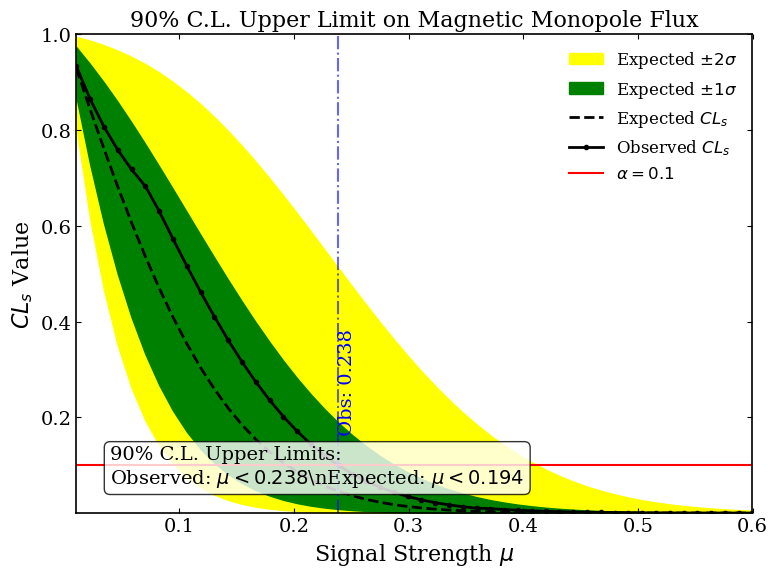

: 

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_brazil_limit(poi_values, results_obs, results_exp, 
#                       obs_limit, exp_limit, 
#                       target_alpha=0.1, 
#                       out_path="limit_brazil_plot.pdf"):
#     """
#     Draws a standard High Energy Physics Brazil Plot for CLs limits.
    
#     Args:
#         poi_values: Array of signal strength values (mu)
#         results_obs: Array of observed CLs values
#         results_exp: 2D Array of expected CLs bands [N_points, 5] 
#                      (Columns: -2sigma, -1sigma, median, +1sigma, +2sigma)
#         obs_limit: Calculated observed limit value (mu)
#         exp_limit: Calculated expected median limit value (mu)
#         target_alpha: Confidence Level alpha (default 0.1 for 90% CL)
#         out_path: Path to save the figure
#     """
    
#     # 1. Setup Canvas (Academic Style)
#     plt.style.use('default') # Reset style
#     plt.rcParams.update({
#         'font.family': 'serif',
#        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
#         'font.size': 14,
#         'axes.labelsize': 16,
#         'axes.titlesize': 16,
#         'xtick.labelsize': 14,
#         'ytick.labelsize': 14,
#         'xtick.direction': 'in',
#         'ytick.direction': 'in',
#         'xtick.top': True,
#         'ytick.right': True,
#         'legend.fontsize': 12,
#         'legend.frameon': False,
#         'figure.figsize': (8, 6),
#         'axes.linewidth': 1.2
#     })

#     fig, ax = plt.subplots()

#     # 2. Extract Expected Bands
#     exp_m2 = results_exp[:, 0] # -2 sigma
#     exp_m1 = results_exp[:, 1] # -1 sigma
#     exp_med = results_exp[:, 2] # Median
#     exp_p1 = results_exp[:, 3] # +1 sigma
#     exp_p2 = results_exp[:, 4] # +2 sigma

#     # 3. Plot Bands (Yellow 2-sigma, Green 1-sigma)
#     # Be careful with fill_between order: Draw widest first
#     ax.fill_between(poi_values, exp_m2, exp_p2, color='yellow', label=r'Expected $\pm 2\sigma$')
#     ax.fill_between(poi_values, exp_m1, exp_p1, color='green', label=r'Expected $\pm 1\sigma$')

#     # 4. Plot Lines
#     # Expected Median (Dashed Black)
#     ax.plot(poi_values, exp_med, color='black', linestyle='--', linewidth=2, label=r'Expected $CL_s$')
    
#     # Observed (Solid Black)
#     # Check if we have valid observed results
#     if np.any(~np.isnan(results_obs)):
#         ax.plot(poi_values, results_obs, color='black', linestyle='-', linewidth=2, marker='o', markersize=3, label=r'Observed $CL_s$')

#     # 5. Reference Line (alpha = 0.1)
#     ax.axhline(target_alpha, color='red', linestyle='-', linewidth=1.5, label=fr'$\alpha = {target_alpha}$')

#     # 6. Add Limit Markers (Optional but helpful)
#     # Vertical line for Observed Limit
#     if not np.isnan(obs_limit):
#         ax.axvline(obs_limit, color='blue', linestyle='-.', alpha=0.6, linewidth=1.5)
#         ax.text(obs_limit, target_alpha * 1.5, f' Obs: {obs_limit:.3f}', color='blue', rotation=90, va='bottom')

#     # 7. Axes & Labels
#     ax.set_xlabel(r'Signal Strength $\mu$')
#     ax.set_ylabel(r'$CL_s$ Value')
#     ax.set_title(r'90% C.L. Upper Limit on Magnetic Monopole Flux')
    
#     # Set Y-axis to Log Scale (Standard for exclusion plots)
#     # ax.set_yscale('log')
    
#     # Set limits for better visibility
#     # X-axis: 0 to slightly more than the limit scan
#     ax.set_xlim(poi_values[0], poi_values[-1])
#     # Y-axis: typically 10^-3 to 1
#     ax.set_ylim(0.001, 1.0)

#     # 8. Legend
#     ax.legend(loc='upper right')

#     # 9. Add Text Box for Results
#     result_text = (
#         f"90% C.L. Upper Limits:\n"
#         rf"Observed: $\mu < {obs_limit:.3f}$\n"
#         rf"Expected: $\mu < {exp_limit:.3f}$"
#     )
#     # Place text box in bottom left
#     ax.text(0.05, 0.05, result_text, transform=ax.transAxes, 
#             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

#     plt.tight_layout()
    
#     # Save
#     if out_path:
#         plt.savefig(out_path, dpi=300)
#         print(f"Figure saved to {out_path}")
    
#     plt.show()

# # ==========================================
# # Execute Plotting
# # ==========================================
# # Assuming 'obs_limit' and 'exp_limit_med' are calculated from your previous interpolation step
# plot_brazil_limit(
#     poi_values, 
#     results_obs, 
#     results_exp, 
#     obs_limit, 
#     exp_limit_med, 
#     target_alpha=0.1,
#     # out_path="/data/home/zzh/Filt_Event/Note_Writing/figures/limit_brazil_plot.pdf"
# )


>>> Calculating Flux Model Systematics (Gaisser vs Hörandel)...


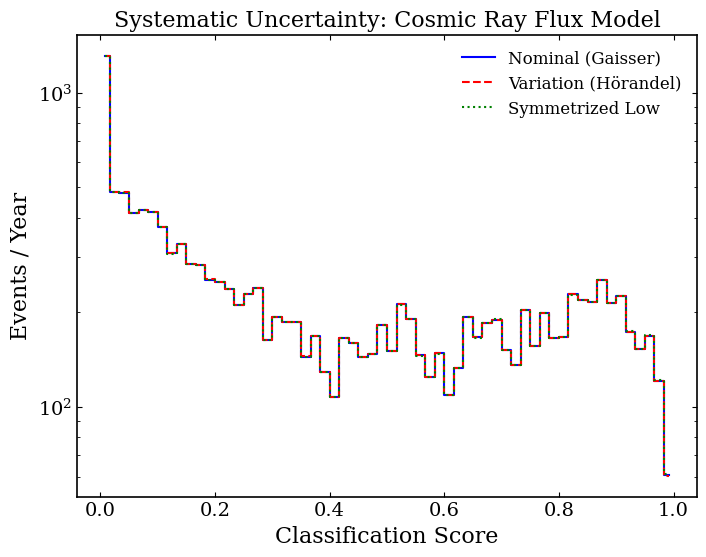

Total Yield (Gaisser): 13765.86
Total Yield (Hörandel): 13765.86
Difference: 0.00%


: 

In [ ]:
# # =====================================================
# # A. 计算流强模型带来的差异 (Flux Model Systematics)
# # =====================================================
# print(">>> Calculating Flux Model Systematics (Gaisser vs Hörandel)...")

# # 1. 确保 DataFrame 里有 horandel_weight
# # 如果之前的代码丢掉了这个列，你需要重新 merge 或者赋值回去
# # 假设 bkg_train_final 已经有了 'horandel_weight'
# if 'horandel_weight' not in bkg_train_final.columns:
#     raise ValueError("DataFrame 中缺少 'horandel_weight' 列，请在准备数据时保留该列！")

# # 2. 生成基准直方图 (Gaisser - 已有)
# # bkg_nom = get_counts(bkg_train_final, 'mlp_score', 'gaisser_weight', BINS) # 之前算过了

# # 3. 生成变动直方图 (Hörandel)
# # 注意：Score 不变，只变 Weight
# bkg_horandel = get_counts(bkg_train_final, 'mlp_score', 'horandel_weight', BINS, scaled_num=num_dict['bkg_nom'])

# # 4. (可选) 归一化处理
# # 因为你的模型里已经有了 mu_bkg (Free Floating)，它会自动处理整体的归一化差异。
# # 我们主要关心的是 "形状 (Shape)" 的差异。
# # 为了让 histosys 更纯粹地反映形状变化，有时会将 Hörandel 归一化到 Gaisser 的总数。
# # 但在 pyhf 中，直接放进去通常也没问题，mu_bkg 会处理剩下的部分。
# # 这里我们选择：直接使用原始权重的 Hörandel，保留其形状和归一化的双重影响。

# # 5. 定义 High / Low 变动
# # 只有两种模型，通常把 Hörandel 当作 "High Variation"
# sys_flux_hi = bkg_horandel

# # 构造 "Low Variation"
# # 方法：对称化误差 (Symmetrization)。
# # 如果 Hörandel 在某 bins 比 Gaisser 高 10%，那么 Low 就比 Gaisser 低 10%。
# # 公式: Low = Nominal - (High - Nominal) = 2 * Nominal - High
# sys_flux_lo = 2 * bkg_nom - sys_flux_hi

# # 保护：防止出现负数
# sys_flux_lo = np.maximum(sys_flux_lo, 0)

# # =====================================================
# # B. 画图检查 (这一步很重要！)
# # =====================================================
# plt.figure(figsize=(8,6))
# centers = (BINS[:-1] + BINS[1:]) / 2
# plt.step(centers, bkg_nom, where='mid', label='Nominal (Gaisser)', color='blue')
# plt.step(centers, sys_flux_hi, where='mid', label='Variation (Hörandel)', linestyle='--', color='red')
# plt.step(centers, sys_flux_lo, where='mid', label='Symmetrized Low', linestyle=':', color='green')
# plt.title("Systematic Uncertainty: Cosmic Ray Flux Model")
# plt.xlabel("Classification Score")
# plt.ylabel("Events / Year")
# plt.yscale('log')
# plt.legend()
# plt.show()

# # 打印一下总数的差异，心里有底
# print(f"Total Yield (Gaisser): {np.sum(bkg_nom):.2f}")
# print(f"Total Yield (Hörandel): {np.sum(bkg_horandel):.2f}")
# diff_pct = (np.sum(bkg_horandel) - np.sum(bkg_nom)) / np.sum(bkg_nom) * 100
# print(f"Difference: {diff_pct:.2f}%")



>>> Generating Energy Scale Systematics...
[      Bkg Nom       ] Cut: E[1.90, 2.10], Rue<-2.00 | Events: 198 | Yield: 783462.91
[      Bkg E_Up      ] Cut: E[1.99, 2.21], Rue<-2.00 | Events: 89 | Yield: 310551.74
[     Bkg E_Down     ] Cut: E[1.80, 1.99], Rue<-2.00 | Events: 109 | Yield: 472911.17
[      Sig Nom       ] Cut: E[1.90, 2.10], Rue<-2.00 | Events: 13605 | Yield: 295.79
[      Sig E_Up      ] Cut: E[1.99, 2.21], Rue<-2.00 | Events: 9393 | Yield: 199.84


[     Sig E_Down     ] Cut: E[1.80, 1.99], Rue<-2.00 | Events: 4212 | Yield: 95.95

>>> Generating Rue Scale Systematics...
[   Bkg Rue_Tight    ] Cut: E[1.90, 2.10], Rue<-2.05 | Events: 157 | Yield: 619589.07
[   Bkg Rue_Loose    ] Cut: E[1.90, 2.10], Rue<-1.95 | Events: 280 | Yield: 1101026.97
[   Sig Rue_Tight    ] Cut: E[1.90, 2.10], Rue<-2.05 | Events: 13605 | Yield: 295.79
[   Sig Rue_Loose    ] Cut: E[1.90, 2.10], Rue<-1.95 | Events: 13605 | Yield: 295.79

>>> Extracting Observed Data...
[      Observed      ] Cut: E[1.90, 2.10], Rue<-2.00 | Events: 13615 | Yield: 13765.86


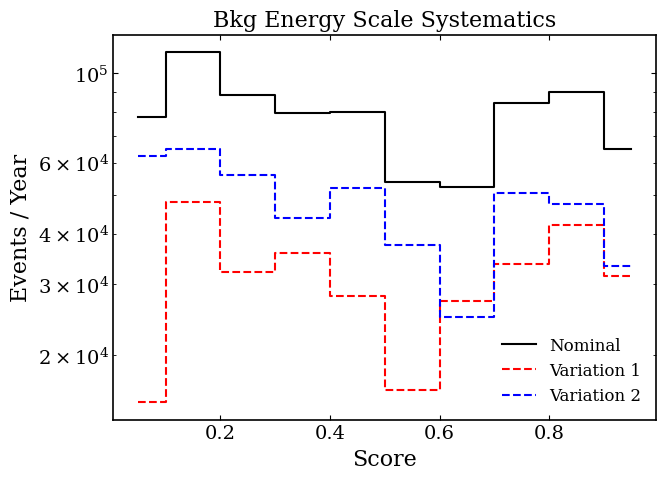

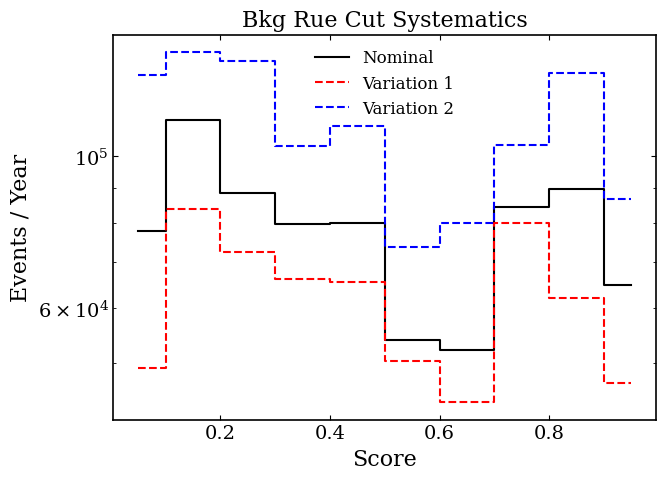

: 

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # ==========================================
# # 0. 全局配置
# # ==========================================
# # 之前训练好的 score 列名 (如果没有请先运行 predict)
# SCORE_COL = 'mlp_score' 

# # 物理切选的标准值 (Nominal Cuts)
# CUT_E_MIN = 1.9
# CUT_E_MAX = 2.1
# CUT_RUE_MAX = -2
# CUT_RHO_MIN = 0   # 假设 rho40 > 0 (如果有的话)

# # 系统误差幅度
# UNCERTAINTY_E = 0.05    # 能量标度误差 ±5%
# UNCERTAINTY_RUE = 0.05  # Rue 绝对偏移 ±0.05

# # 目标直方图 Bins
# BINS = np.linspace(0, 1, 11)

# # ==========================================
# # 1. 定义动态切选函数
# # ==========================================
# def get_hist_with_cuts(df, weight_col, e_scale=1.0, rue_shift=0.0, label=""):
#     """
#     df: 全量大范围数据 (bkg_train_final 或 sig_train_final)
#     e_scale: 能量标度因子 (1.0=Nominal, 1.05=Up, 0.95=Down)
#     rue_shift: Rue阈值偏移 (0.0=Nominal, -0.05=Tight, +0.05=Loose)
#     """
#     # 1. 计算变动后的 Cut 阈值
#     # E Scale Up 意味着探测器测到的能量偏高，所以相同的物理Cut对应更大的数值
#     # 或者理解为：我们移动窗口来探测 "Scale变化" 的影响
#     c_e_min = CUT_E_MIN * e_scale
#     c_e_max = CUT_E_MAX * e_scale
    
#     # Rue Shift: 负数越小越严。
#     # Shift < 0 -> Cut 变小 -> 变严 (Tight)
#     # Shift > 0 -> Cut 变大 -> 变松 (Loose)
#     c_rue = CUT_RUE_MAX + rue_shift
    
#     # 2. 应用切选
#     # 注意：这里我们使用原始的 recE 和 R_ue 列进行筛选
#     cond = (df['recE'] > c_e_min) & (df['recE'] < c_e_max) & \
#            (df['R_ue'] < c_rue) 
#            # & (df['rho40'] > CUT_RHO_MIN) # 如果有 rho40 请取消注释
            
#     df_cut = df[cond].copy()
    
#     # 3. 统计直方图
#     if len(df_cut) == 0:
#         return np.full(len(BINS)-1, 1e-6)
    
#     scores = df_cut[SCORE_COL].values
#     weights = df_cut[weight_col].values
    
#     counts, _ = np.histogram(scores, bins=BINS, weights=weights)
    
#     # 归一化到年 (如果权重是率)
#     counts = counts * 365 * 86400
    
#     # 打印调试信息
#     print(f"[{label:^20}] Cut: E[{c_e_min:.2f}, {c_e_max:.2f}], Rue<{c_rue:.2f} | Events: {len(df_cut)} | Yield: {counts.sum():.2f}")
    
#     return np.maximum(counts, 1e-6)

# # ==========================================
# # 2. 检查 Score 是否存在
# # ==========================================
# # 这一步很关键：系统误差是基于 "通过Cut的事例的Score分布"
# # 所以 bkg_train_final 和 sig_train_final 必须已经有了 'mlp_score' 列
# # 如果没有，请先用你的 manager 对它们进行预测！
# if SCORE_COL not in bkg_train_final.columns:
#     print("正在对 bkg_train_final 进行打分...")
#     # 假设 manager 是之前训练好的
#     bkg_train_final[SCORE_COL] = manager.predict_ensemble(bkg_train_final) 

# if SCORE_COL not in sig_train_final.columns:
#     print("正在对 sig_train_final 进行打分...")
#     sig_train_final[SCORE_COL] = manager.predict_ensemble(sig_train_final)

# # ==========================================
# # 3. 生成 recE 系统误差 (Energy Scale)
# # ==========================================
# print("\n>>> Generating Energy Scale Systematics...")

# # 背景 (Proton)
# bkg_nom = get_hist_with_cuts(bkg_train_final, 'gaisser_weight', label="Bkg Nom")
# bkg_e_up = get_hist_with_cuts(bkg_train_final, 'gaisser_weight', e_scale=1+UNCERTAINTY_E, label="Bkg E_Up")
# bkg_e_down = get_hist_with_cuts(bkg_train_final, 'gaisser_weight', e_scale=1-UNCERTAINTY_E, label="Bkg E_Down")

# # 信号 (Monopole) - 信号对能量 Cut 极其敏感
# sig_nom = get_hist_with_cuts(sig_train_final, 'weight', label="Sig Nom")
# sig_e_up = get_hist_with_cuts(sig_train_final, 'weight', e_scale=1+UNCERTAINTY_E, label="Sig E_Up")
# sig_e_down = get_hist_with_cuts(sig_train_final, 'weight', e_scale=1-UNCERTAINTY_E, label="Sig E_Down")

# # ==========================================
# # 4. 生成 R_ue 系统误差 (Rue Scale/Resolution)
# # ==========================================
# print("\n>>> Generating Rue Scale Systematics...")

# # 背景
# bkg_rue_up = get_hist_with_cuts(bkg_train_final, 'gaisser_weight', rue_shift=-UNCERTAINTY_RUE, label="Bkg Rue_Tight") # 变严
# bkg_rue_down = get_hist_with_cuts(bkg_train_final, 'gaisser_weight', rue_shift=+UNCERTAINTY_RUE, label="Bkg Rue_Loose") # 变松

# # 信号
# # Rue 的微小变动对信号影响通常较小（因为信号在 -8 很深的位置），但为了完整性也要算
# sig_rue_up = get_hist_with_cuts(sig_train_final, 'weight', rue_shift=-UNCERTAINTY_RUE, label="Sig Rue_Tight")
# sig_rue_down = get_hist_with_cuts(sig_train_final, 'weight', rue_shift=+UNCERTAINTY_RUE, label="Sig Rue_Loose")

# # ==========================================
# # 5. 生成 Observation (Exp Data)
# # ==========================================
# # 实验数据不做变动，只应用 Nominal Cut
# print("\n>>> Extracting Observed Data...")
# # 确保 exp 数据在 -1.9 处被截断不会影响 -2.6 的分析
# obs_hist = get_hist_with_cuts(exp_final, 'weight', label="Observed")

# # ==========================================
# # 6. 可视化检查 (可选)
# # ==========================================
# def plot_sys_check(nom, up, down, title):
#     plt.figure(figsize=(7, 5))
#     x = (BINS[:-1] + BINS[1:]) / 2
#     plt.step(x, nom, where='mid', label='Nominal', color='black')
#     plt.step(x, up, where='mid', label='Variation 1', linestyle='--', color='red')
#     plt.step(x, down, where='mid', label='Variation 2', linestyle='--', color='blue')
#     plt.yscale('log')
#     plt.title(title)
#     plt.legend()
#     plt.xlabel("Score")
#     plt.ylabel("Events / Year")
#     plt.show()

# plot_sys_check(bkg_nom, bkg_e_up, bkg_e_down, "Bkg Energy Scale Systematics")
# plot_sys_check(bkg_nom, bkg_rue_up, bkg_rue_down, "Bkg Rue Cut Systematics")
